# Load all routines path necessary for the FPDEM code to run (scripts/, src/ and environment path)

In [1]:
import sys
src_path = "/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src"
sys.path.append(f"{src_path}")
scripts_path = "/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/scripts"
sys.path.append(f"{scripts_path}")

# Define all parameters of FPDEM

Fill in all the parameters necessary to run this notebook.

In [2]:
model_main_path = "/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/testcases/Haditha"
model_pixc_main_path = "/work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Haditha"

# Pixc list (1 space blank between each file)
pixc_files = f"{model_pixc_main_path}/input/pixc/SWOT_L2_HR_PIXC_*.nc"

# PixcVec list (1 space blank between each file)ls 
pixcvec_files = f"{model_pixc_main_path}/input/pixcvec/SWOT_L2_HR_PIXCVec_*.nc"

# Output directory
output_dir = f"{model_main_path}/output_nbk"

# Output file name extension
tile_name = "34N42E"
first_date = "20230212T194612"
last_date = "20240507T192442"


# Geographical extrema of the studied region : filtering of points applied on this box
latitude_min = 34.09
latitude_max = 34.8
longitude_min = 41.9
longitude_max = 42.8


# Select model approach : 
# Bathtub ring method or a mix of bathtub and clustering and direct extraction of land
approach = 'mixed' # mixed or bathtub


# Pekel info : 
# Path and name of the Pekel occurrences file
pekel_path = "/work/datalake/static_aux/MASQUES/PEKEL/data2021/occurrence/occurrence.vrt"

# SWORD info : 
# Path to SWORD database
sword_path = "/work/SWOT/swotdev/swotpub/BD/BD_rivers/SWORD_v17/shp"
# Paths and names of hydrobasins (level1 and level2) files
hydrobasin_lv1_file = "/work/SWOT/swotdev/swotpub/BD/major_basins/HydroBASINS/level1/hybas_lev01_v1c.shp"
hydrobasin_lv2_file = "/work/SWOT/swotdev/swotpub/BD/major_basins/HydroBASINS/level2/hybas_lev02_v1c.shp"

# Swot science orbits and tiles path and filename
swot_tiles_file = "/work/SWOT/swotdev/swotdev/stephag/orbits/swot_science_hr_2.0s_4.0s_June2019-v3_swath_tile.shp"


#
# Mask
#
# To filter points around a specific lake, river, 
# or filter only points present in Pekel occurrences (1->100%; with a buffer if mask_buffer_size != 0)
# 0 : no; 1 : yes (with PLD); 2 : yes (with Pekel); 3 : yes (with Sword)
use_mask = 0
# Buffer in soil geometry (degrees)
mask_buffer_size = 0.02 # Optional parameter : only required if use_mask >= 1
# PLD info
lake_id = 2940021003 # Optional parameter : only required if use_mask = 1
pld_path = "/work/SWOT/swotdev/swotpub/BD/BD_lakes/PLD/Nom/" # Optional parameter : only required if use_mask = 1


# Plot
plot = "yes2" # Options: no, yes1 (only for Python script), yes2 (for notebook)


#
# PIXC pre-processing
#
# Range value of the crosstrack minimum value wanted
cross_track_min = 10000.
# Minimum surface of a water body kept for FPDEM method
threshold = 100000. # Minimum surface of a water body kept for FPDEM method


#
# Clustering method params : performed on WATER_LAND labels (optional if approach='bathtub')
#
# zscore or isolation_forest
clustering_outlier_filter_method = "isolation_forest"
# kmeans, birch, hdbscan_tsne or hdbscan_umap are possible choices
clustering_method = "kmeans"
# Once the clustering is performed, all water bodies will get their contour extracted;
# Choose either the bathtub ring method (like it is already done for WATER labels) 
# or the geopandas concave hull method (might be better for small water bodies)
clustering_contour = "concavehull" # bathtub or concavehull


#
# Filtering
#
# Pekel filtering
# At the beginning of the bathy extraction,
# Filtering Dark water, all PIXC points within Pekel occurrences > {chosen value}% are kept
filtering_pekel_val_DW = 90
# At the end of the bathy extraction,
# Filter out all points within Pekel occurrences > {chosen value}% 
filtering_pekel_end = 'no' # yes or no
filtering_pekel_end_val = 99 # Threshold occurrence value

# Quality flags for filtering
# At the beginning of the bathy extraction
# Filter sig0_qual: 'no' = do not filter; 'yes' = keep only good points (i.e., sig0_qual=0)
sig0_qual = 'yes' # yes or no
# At the end of the bathy extraction
# Select the bit threshold for each quality flag, all FPDEM/PIXC points with a bit higher than the chosen value are filtered out
classification_qual = 33554432
geolocation_qual = 33554432

# Isolated points filtering (with DBSCAN) :
# Maximum distance in degrees for two points to be considered neighbors
distance_to_neighbors = 0.001
# All points with less meighbors than the chosen value are filtered out
number_of_neighbors = 5

# Labeling water bodies :
# Remove objects smaller than or equal to chosen size
body_min_size = 2000
# Connectivity defining the neighborhood of a pixel
body_connectivity = 1


#
# Extract area / Obtain polygons for rasterisation
#
# Concave hull ratio (with geopandas)
plg_ch_ratio = 0.005


#
# Raster
#
# Choose between 'latlon' or 'utm' for the definition of the raster grid
raster_mode = "latlon" # utm or latlon
# The resolution is in degrees for latlon mode and meters for utm mode
# for example: if latlon => 0.000277777; if utm > 100
raster_resolution = 0.000277777


Here are all the imports necessary for the python code.

In [3]:
# Miscellaneous
import os
import copy
import logging
import pandas as pd
import geopandas as gpd
import numpy as np
import utm
import random
import shapely
from shapely.geometry import Point, MultiPoint

# Plotting libraries
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import GoogleTiles
wgs84 = ccrs.PlateCarree(globe=ccrs.Globe(ellipse='WGS84'))
geodetic = ccrs.Geodetic(globe=ccrs.Globe(datum='WGS84'))
tiler = GoogleTiles(style="satellite")

# FPDEM classes/routines
from process_floodplain import Floodplain

from clustering_method import Clustering_Method

from process_extract_area import Extract_Area

from process_raster import FPDEM_Raster

from nc import PixcReader

from process import (pre_processing_pixc, get_range_azimuth_extrema, prepare_clustering_image,
                     find_attributes, remove_borders, filter_data_based_on_quality_flag,
                     final_filtering_FPDEM_results)

from water_or_land import (compute_label_and_remove_small_object, compute_subwater_extract_from_label,
                           find_body_category)

from Pekel_Sword_PLD_intersect import (get_tiles_geom, get_PLD_mask, get_Pekel_mask, extract_Pekel_polygon,
                                       get_reach_node_info, get_poly_sword_from_reach)

from names import (compute_name, FPDEM_BASENAME, FPDEM_POINTCLOUD_BASENAME, MASK_SUFFIX, FPDEM_RASTER_BASENAME)


In [4]:
# Initialize logging
level = getattr(logging, "INFO")
logging.basicConfig(filename=None, format='%(asctime)s [%(levelname)s] %(message)s', level=level)

# Initialize FPDEM workflow

Create the output directory

In [6]:
if os.path.isdir(output_dir) is False:
    os.mkdir(output_dir)

Get the names of all PIXC (and PIXCVec if there are any) and get the list of tiles information

In [7]:
# Get the list of PIXC and PIXCVEC files
inppixc = os.popen("ls " + pixc_files).readlines()
inpvec = os.popen("ls " + pixcvec_files).readlines()
inputpixcfiles = []
inputvecfiles = []
list_tile_info = []
for i in range(0, len(inppixc)):
    inppixc[i] = inppixc[i].rstrip('\n')
    find = False
    for k in range(0, len(inpvec)):
        inpvec[k] = inpvec[k].rstrip('\n')
        if (inppixc[i].split("_PIXC_")[1].split("_P")[0] == inpvec[k].split("_PIXCVec_")[1].split("_P")[0]) \
            and (find == False):
            inputpixcfiles.append(inppixc[i])
            inputvecfiles.append(inpvec[k])
            find = True
    if find == False:  
        print("PIXCVec file is missing for date " + inppixc[i].split("_PIXC_")[1].split("_PI")[0] + 
              "  => replaced by PIXC")
        inputpixcfiles.append(inppixc[i])
        inputvecfiles.append(inppixc[i])
    if inppixc[i].split('/')[-1][20:28] not in list_tile_info:
        list_tile_info.append(inppixc[i].split('/')[-1][20:28])
print('List of PIXC files: ', inputpixcfiles)
print('List of tiles used: ', list_tile_info)

PIXCVec file is missing for date 007_471_215R_20231210T054007_20231210T054018  => replaced by PIXC
PIXCVec file is missing for date 041_471_215R_20251118T151248_20251118T151259  => replaced by PIXC
List of PIXC files:  ['/work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Haditha/input/pixc/SWOT_L2_HR_PIXC_007_471_215R_20231210T054007_20231210T054018_PIC0_02.nc', '/work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Haditha/input/pixc/SWOT_L2_HR_PIXC_041_471_215R_20251118T151248_20251118T151259_PID0_01.nc']
List of tiles used:  ['471_215R']


ls: impossible d'accéder à '/work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Haditha/input/pixcvec/SWOT_L2_HR_PIXCVec_*.nc': No such file or directory


Read Pekel file and get the polygon mask depending on chosen occurrences for the studied area

In [8]:
# Get the geometry of the used PIXC tiles to clip Pekel and SWORD data
pixc_tiles_geom = get_tiles_geom(list_tile_info, swot_tiles_file)

# Pekel info
data_pekel = get_Pekel_mask(pekel_path, pixc_tiles_geom.geometry.values[0])

# Polygon of Pekel used in parametrization of water bodies
pekel_0_100_poly = extract_Pekel_polygon(data_pekel, 
                                         occ_min=0, occ_max=100, 
                                         bufsize=0.)

# Polygon of Pekel used to select dark water points
try:
    pekel_X_100_poly = extract_Pekel_polygon(data_pekel, 
                                             occ_min=filtering_pekel_val_DW, occ_max=100, 
                                             bufsize=0.)
except:
    logging.info(f"    No points in Pekel occurrences > {filtering_pekel_val_DW}% for this region")
    pekel_X_100_poly = None # In some regions water occurrence above 95% does not exist
    
pekel_X2_100_poly = None 
if filtering_pekel_end == 'yes': 
    # Polygon of Pekel used to select dark water points
    try:
        pekel_X2_100_poly = extract_Pekel_polygon(data_pekel, 
                                                  occ_min=filtering_pekel_end_val, occ_max=100,
                                                  bufsize=0.)
    except:
        logging.warning(f"    No points in Pekel occurrences > {filtering_pekel_end_val}% for this region")
        pekel_X2_100_poly = None # In some regions water occurrence above 95% does not exist                                              bufsize=0.)

Read SWORD file corresponding to studied region and get the polygon using reaches information

In [9]:
try:
    # SWORD info
    df_reach_data, df_node_data = get_reach_node_info(pixc_tiles_geom,
                                                      sword_path, hydrobasin_lv1_file, hydrobasin_lv2_file)
    # Polygon of the SWORD used in parametrization of water bodies
    poly_sword = get_poly_sword_from_reach(df_reach_data, buffer_size=0.)
except:
    poly_sword = None

2026-02-12 08:19:49,216 [INFO]     Continent number: [2], ['EU'] -- Hydrobasin number: [29]


Show the Pekel (for Dark Water) and SWORD masks on the studied area

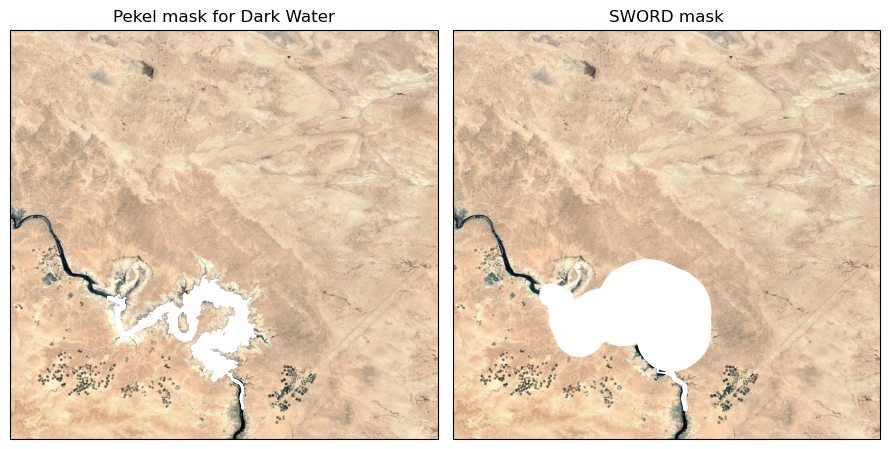

In [10]:
extent = [longitude_min, longitude_max, latitude_min, latitude_max]

fig = plt.figure(figsize=(9,5), layout='tight')
ax1 = fig.add_subplot(1, 2, 1, projection=tiler.crs)
ax1.set_title('Pekel mask for Dark Water')
ax1.set_extent(extent, geodetic)
ax1.add_image(tiler, 11)
ax1.add_geometries(pekel_X_100_poly, wgs84, edgecolor='white', facecolor='white')

if poly_sword is not None:
    ax2 = fig.add_subplot(1, 2, 2, projection=tiler.crs)
    ax2.set_title('SWORD mask')
    ax2.set_extent(extent, geodetic)
    ax2.add_image(tiler, 11)
    ax2.add_geometries(poly_sword, wgs84, edgecolor='white', facecolor='white')
    
plt.show()

Get the mask polygon if the user wants to reduce the studied region (use of Pekel, PLD or SWORD)

In [11]:
# Create the polygon mask needed for intersection with PIXC to limit the number of points
if use_mask == 1:
    print('PLD Mask intersection will be performed\n')
    polygon_mask = get_PLD_mask(lake_id, pld_path, inputpixcfiles[0])
elif use_mask == 2:
    print('Pekel Mask intersection will be performed\n')
    polygon_mask = extract_Pekel_polygon(data_pekel, occ_min=0, occ_max=100, bufsize=mask_buffer_size)
elif use_mask == 3:
    print('Sword Mask intersection will be performed\n')
    polygon_mask = get_poly_sword_from_reach(df_reach_data, buffer_size=mask_buffer_size)
else:
    polygon_mask = None

# Extracting bathymetry points from PIXC

Here is the main part of the notebook where the bathymetry points will be extracted for each PIXC in the list (previously determined).

For each PIXC, all PIXC points are labelized into 'water' bodies. On each body, we either apply the Bathtub Ring method or we categorize them into land, water or water-land depending on the option chosen by the user at the beginning of the notebook. For land bodies a direct extraction is performed. On water bodies the Bathtub Ring method is applied and on water-land bodies we clusterize them to separate water from land and then apply the Bathtub Ring method or do a direct extraction respectively.

At the end of the cell (still on each PIXC), the borders of the PIXC tiles are removed to eliminate false contours/bathymetries and some filtering based on quality flags is applied.

All PIXC results are merged into one single Dataframe.

2026-02-12 08:19:58,574 [INFO] PIXC: /work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Haditha/input/pixc/SWOT_L2_HR_PIXC_007_471_215R_20231210T054007_20231210T054018_PIC0_02.nc


Processing PIXC 1/2


2026-02-12 08:22:59,468 [INFO] Extract water points
2026-02-12 08:22:59,954 [INFO] Remove pixels too close to near_range
2026-02-12 08:23:11,748 [INFO] Extract contiguous water points by keeping only water bodies whose area is greater than threshold


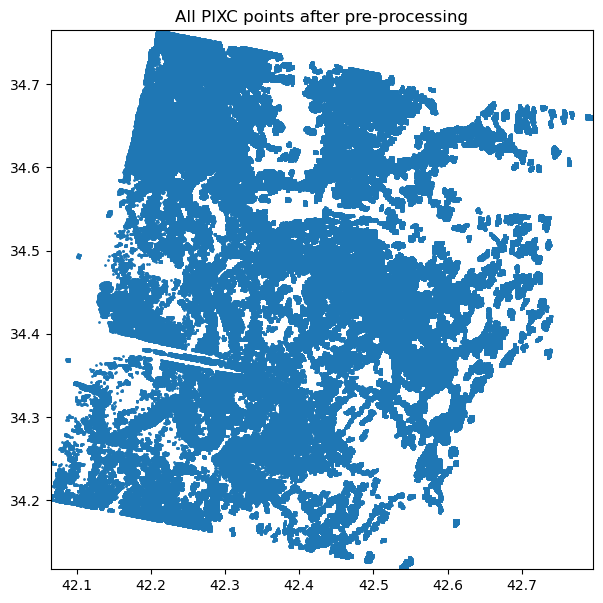

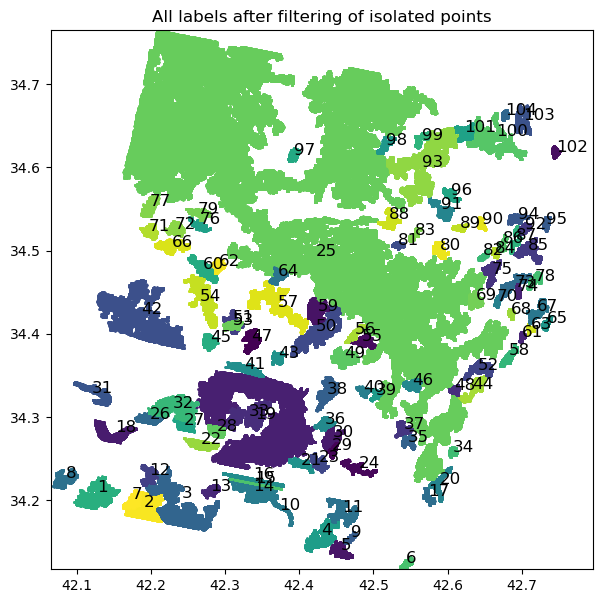

2026-02-12 08:23:57,266 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:23:57,267 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.036396026611328, 0.09181032329797745, 0.16994917392730713, -1.1710915565490723, 0.27036094665527344, 0.9595737268299039, 0.9977635616971668


Number of water bodies found : 104

Processing Label 1 / 104


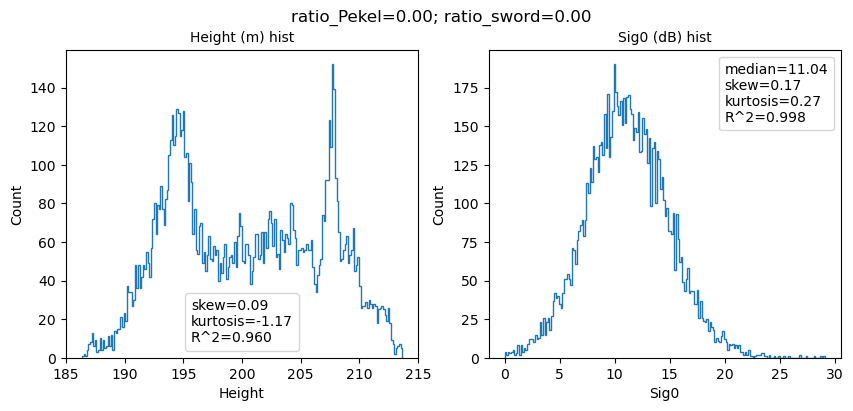

2026-02-12 08:23:57,587 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:23:57,587 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.99306869506836, 0.03359370306134224, 0.07791227847337723, -0.6506822109222412, -0.09631824493408203, 0.9845947489280715, 0.999284986030511


Body type: LAND

Processing Label 2 / 104


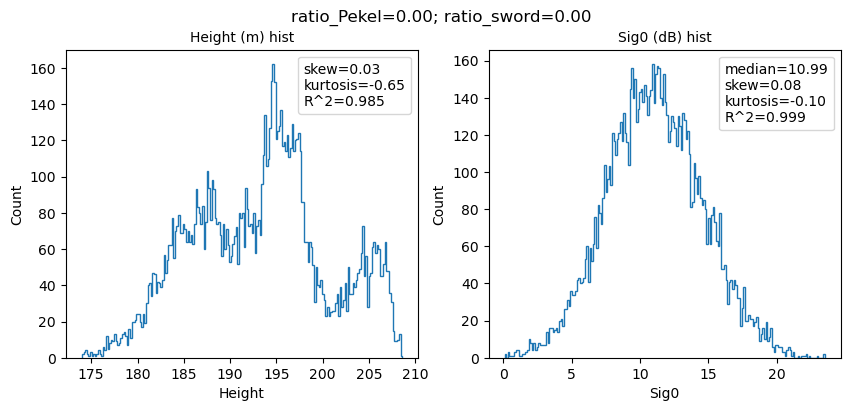

2026-02-12 08:23:57,918 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:23:57,919 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.452857971191406, -0.6280803084373474, 0.1751669943332672, 0.0007622241973876953, 0.1340465545654297, 0.9670542852040922, 0.9978907454241263


Body type: LAND

Processing Label 3 / 104


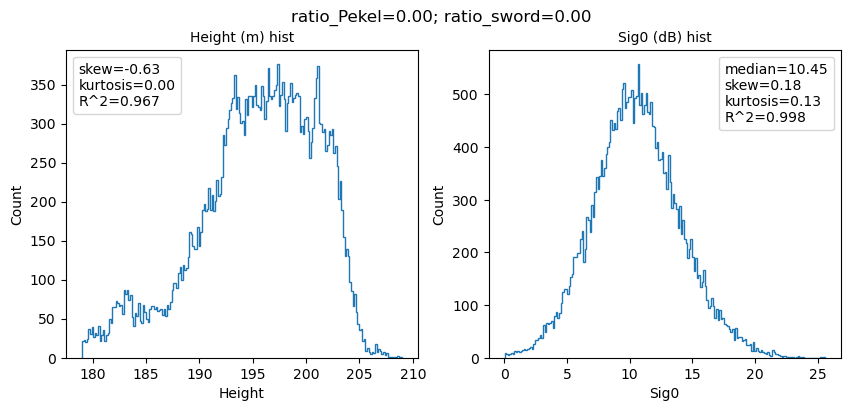

2026-02-12 08:23:58,228 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:23:58,229 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.199724197387695, -0.14463463425636292, -0.11822003871202469, -0.3881666660308838, -0.027062416076660156, 0.9942345246332628, 0.9984084611895643


Body type: LAND

Processing Label 4 / 104


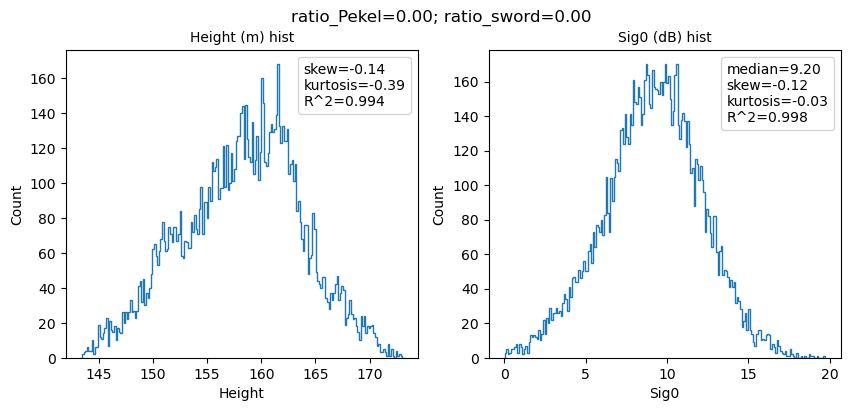

2026-02-12 08:23:58,515 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:23:58,515 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.867425918579102, 0.471469908952713, 0.022601325064897537, 0.15500402450561523, -0.0737144947052002, 0.9790625689466641, 0.9994190826132665


Body type: LAND

Processing Label 5 / 104


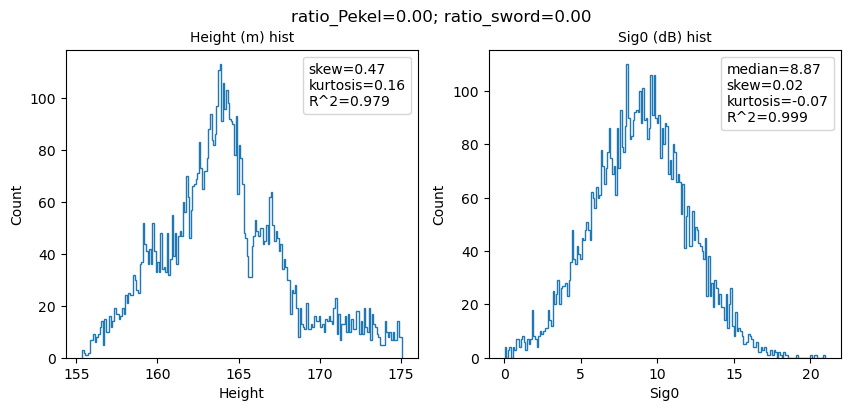

2026-02-12 08:23:58,769 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:23:58,770 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.903122901916504, -0.1354915052652359, -0.09994716942310333, -0.7006535530090332, -0.05908846855163574, 0.9853712116615129, 0.9983968214589276


Body type: LAND

Processing Label 6 / 104


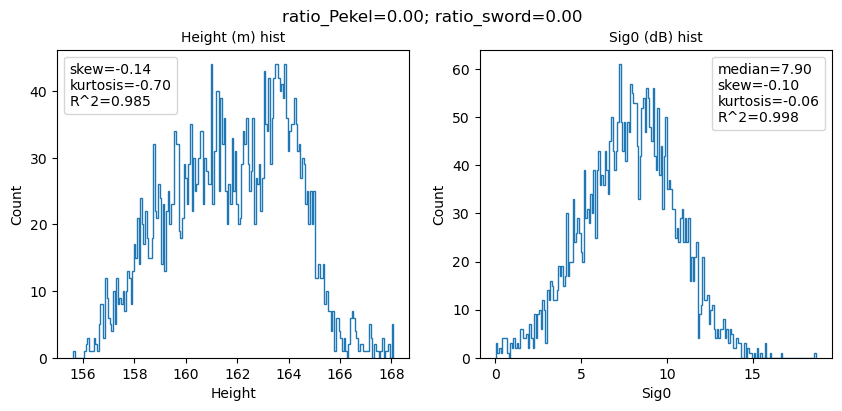

2026-02-12 08:23:59,037 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:23:59,037 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.695782661437988, 0.07415176928043365, 0.13504378497600555, -0.5656547546386719, 0.09882593154907227, 0.9894974546855084, 0.9981950002577653


Body type: LAND

Processing Label 7 / 104


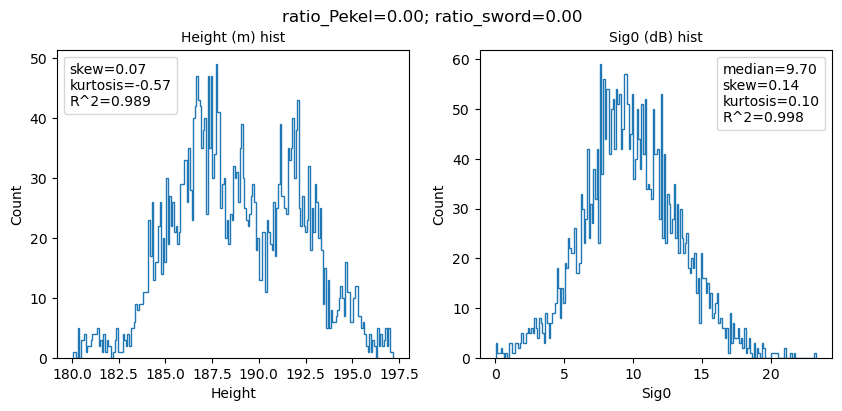

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:23:59,308 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:23:59,308 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.700172424316406, -0.09365761280059814, -0.010913297533988953, -1.0025455951690674, -0.1269841194152832, 0.9726367057466436, 0.9992946812449184


Body type: LAND

Processing Label 8 / 104


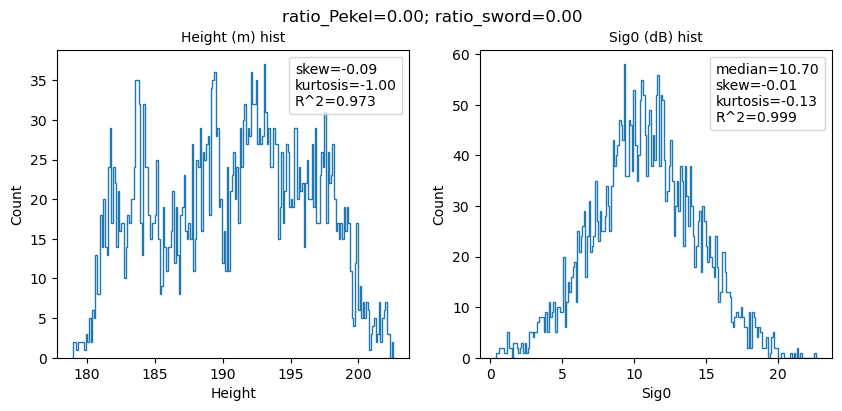

2026-02-12 08:23:59,595 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:23:59,596 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.769641876220703, 0.3212927579879761, -0.10121509432792664, -0.6937549114227295, 0.1415691375732422, 0.9784037619828758, 0.9970148790453872


Body type: LAND

Processing Label 9 / 104


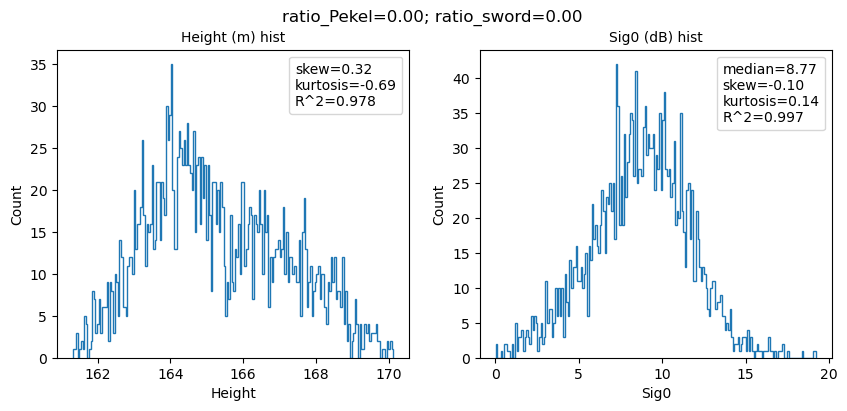

2026-02-12 08:23:59,878 [INFO] Ratio pekel, ratio sword: 0.8463978251019484, 0.9125509741730856
2026-02-12 08:23:59,878 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.339319229125977, 3.049515962600708, 0.04676491767168045, 9.15002727508545, -0.7641754150390625, 0.5783952046911681, 0.9883485114746342


Body type: LAND

Processing Label 10 / 104


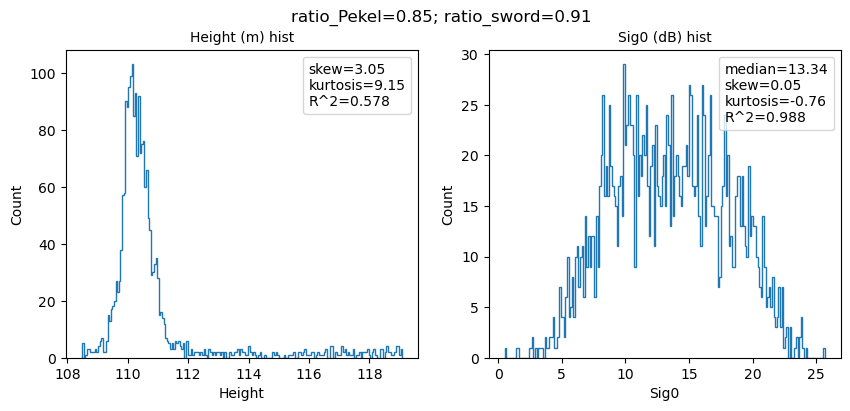

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.388051409754631 34.181290222538294
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:00,242 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:00,243 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.437536239624023, -0.06462077051401138, 0.06772439181804657, -1.0138611793518066, 0.2488718032836914, 0.9683695119207604, 0.9987468043350037


Body type: WATER
Bathtub ring method is applied

Processing Label 11 / 104


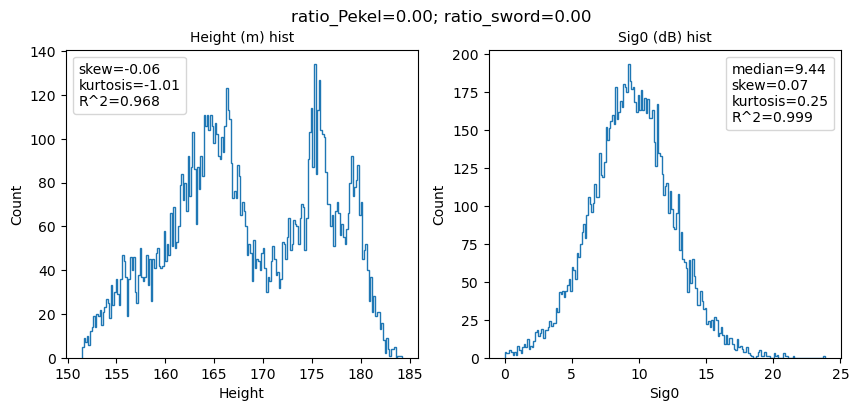

2026-02-12 08:24:00,537 [INFO] Ratio pekel, ratio sword: 0.0, 0.06287944492627927
2026-02-12 08:24:00,538 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.53800106048584, 0.2123524397611618, -0.025083864107728004, -0.14975595474243164, -0.10809874534606934, 0.9946476740202579, 0.9995442668578649


Body type: LAND

Processing Label 12 / 104


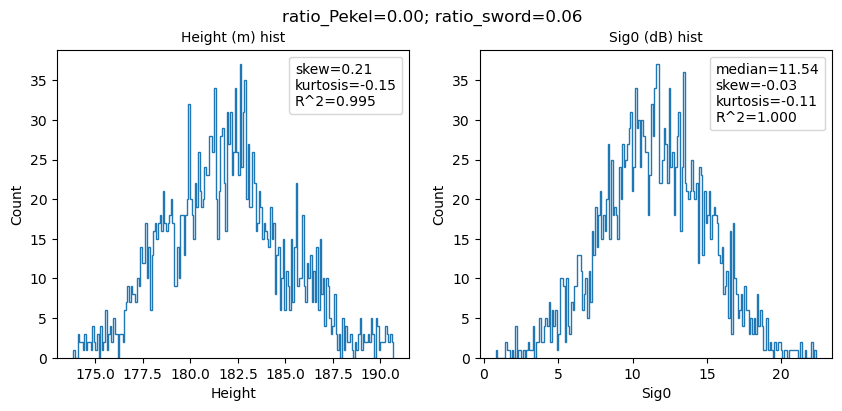

2026-02-12 08:24:00,835 [INFO] Ratio pekel, ratio sword: 0.5106382978723404, 0.0
2026-02-12 08:24:00,835 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.92910385131836, 1.0809671878814697, 0.24553847312927246, 1.0484752655029297, 0.05115151405334473, 0.9198152702845526, 0.9961921808399878


Body type: LAND

Processing Label 13 / 104


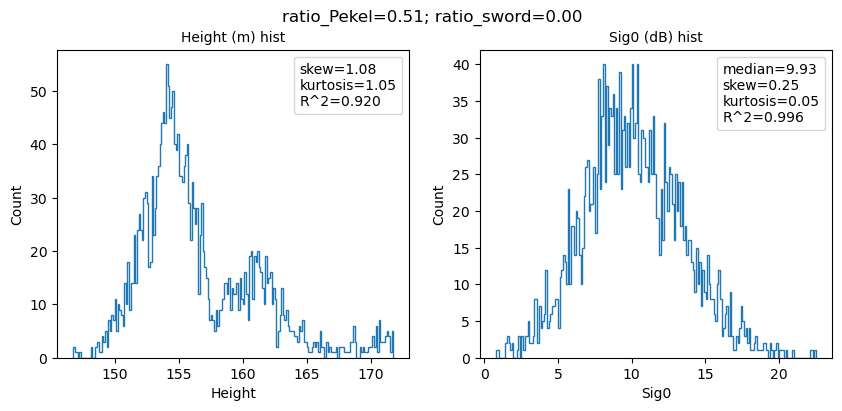

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.278330612810564 34.207050419740348
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:01,158 [INFO] Ratio pekel, ratio sword: 0.7983761840324763, 0.7379606781819629
2026-02-12 08:24:01,159 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):20.263526916503906, -0.4922807216644287, -0.6550917625427246, -0.18181920051574707, -0.3050549030303955, 0.9788516709778663, 0.9545943021315703


Body type: WATER
Bathtub ring method is applied

Processing Label 14 / 104


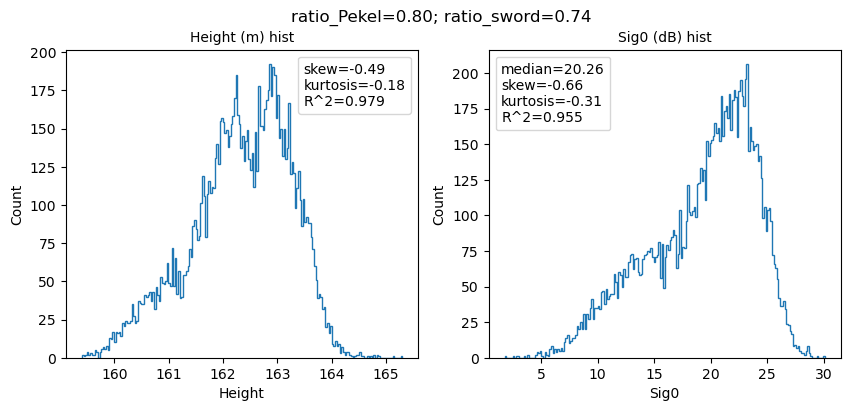

Body type: WATER
Bathtub ring method is applied

Processing Label 15 / 104


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.364419423996502 34.215370806688462
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:01,635 [INFO] Ratio pekel, ratio sword: 0.9664723032069971, 1.0
2026-02-12 08:24:01,635 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):21.607650756835938, 0.017415743321180344, -0.8392354249954224, -0.7649714946746826, 0.3785884380340576, 0.9817858820066369, 0.9502101428293241


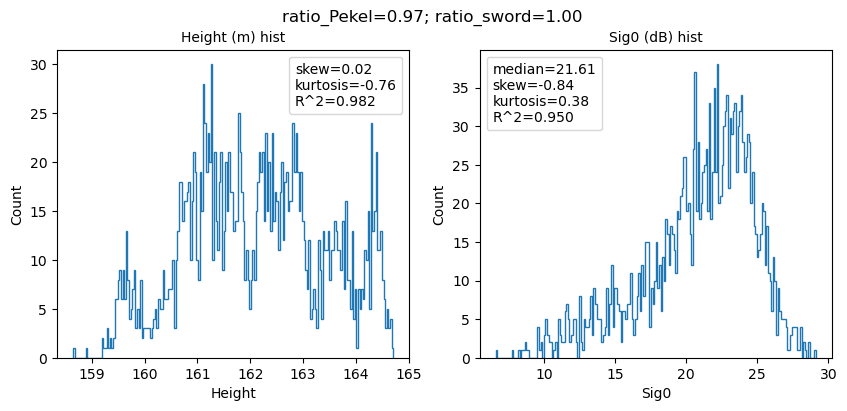

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.365498859538164 34.216977746878605
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:01,933 [INFO] Ratio pekel, ratio sword: 1.0, 1.0
2026-02-12 08:24:01,934 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):22.206558227539062, 0.19608807563781738, -0.8900779485702515, -1.020566463470459, 1.3849916458129883, 0.9640938243377253, 0.9596642770163045


Body type: WATER
Bathtub ring method is applied

Processing Label 16 / 104


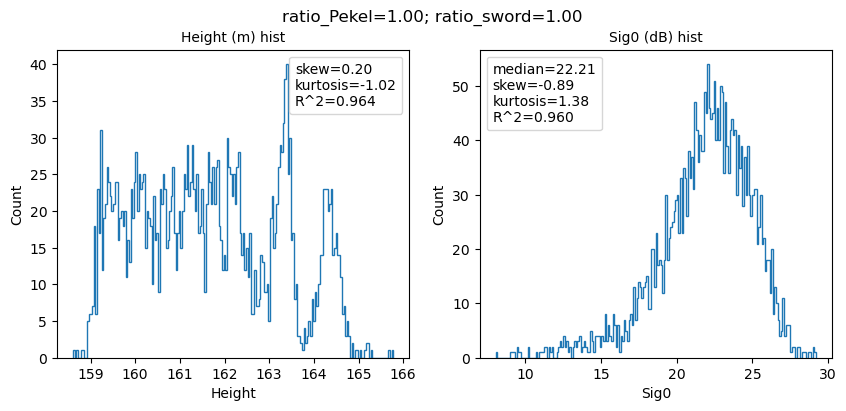

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.369213590183108 34.220282601503882
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:02,245 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:02,245 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.637208938598633, 1.074500322341919, -0.04859735071659088, 0.5653889179229736, 0.1866474151611328, 0.9030774315646998, 0.9984009018954857


Body type: WATER
Bathtub ring method is applied

Processing Label 17 / 104


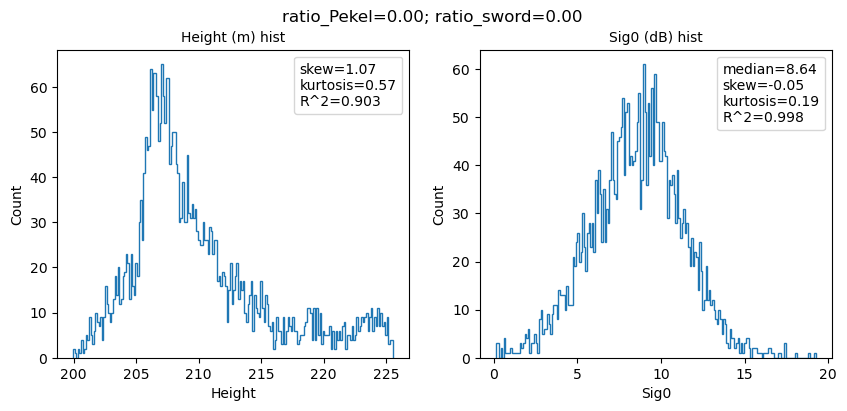

2026-02-12 08:24:02,542 [INFO] Ratio pekel, ratio sword: 1.0, 1.0
2026-02-12 08:24:02,543 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):22.573528289794922, 0.3276088237762451, -0.5665099024772644, -0.9835259914398193, -0.04533267021179199, 0.9560492117047905, 0.9758306105940665


Body type: LAND

Processing Label 18 / 104


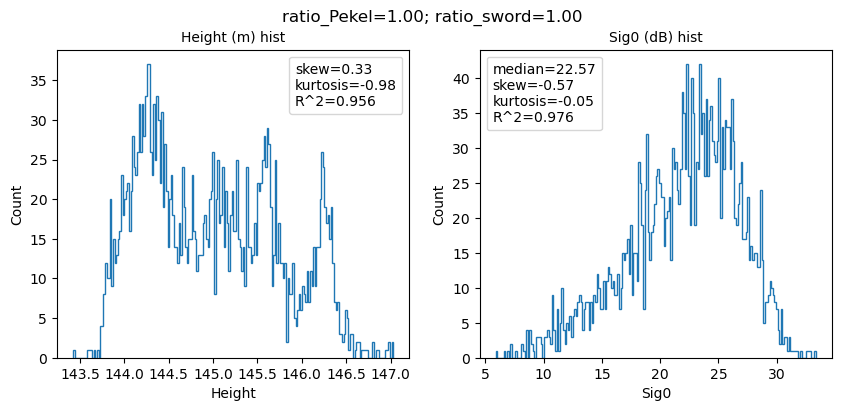

Body type: WATER
Bathtub ring method is applied

Processing Label 19 / 104


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.175379857851375 34.287055956352965
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:03,208 [INFO] Ratio pekel, ratio sword: 0.9833480075029667, 0.9999562509228321
2026-02-12 08:24:03,209 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):19.369956970214844, -0.4136010408401489, -0.25872546434402466, -1.0642485618591309, 0.4616060256958008, 0.9362467155792437, 0.9952979762400908


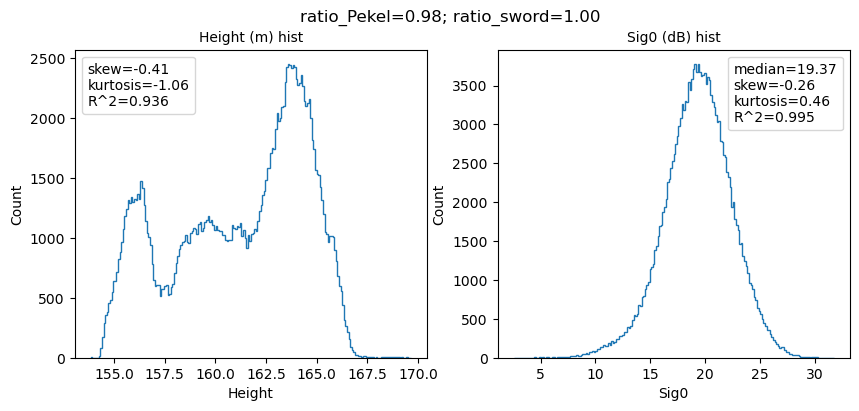

Body type: WATER
Bathtub ring method is applied


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.41149728218948 34.288654804138105
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:11,491 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:11,491 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.244895935058594, 0.4621165096759796, 0.005808546673506498, -0.440126895904541, 0.2741231918334961, 0.9473632118112412, 0.998198442725212



Processing Label 20 / 104


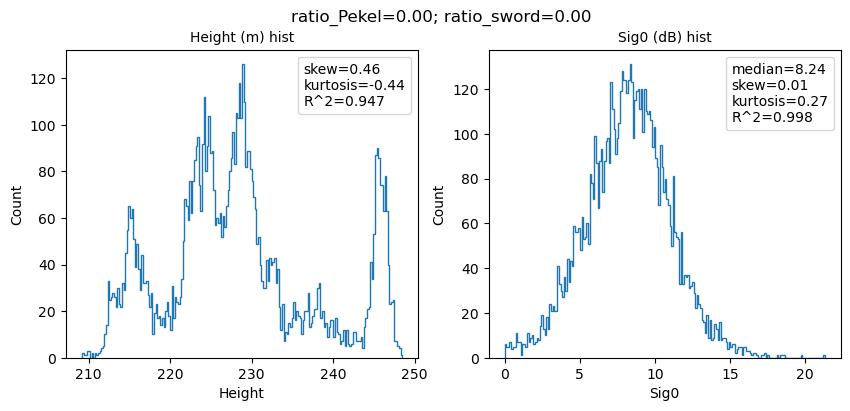

2026-02-12 08:24:11,749 [INFO] Ratio pekel, ratio sword: 0.9024539877300614, 1.0
2026-02-12 08:24:11,749 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.165241241455078, 1.7059106826782227, 0.040486689656972885, 3.0113539695739746, 0.21308135986328125, 0.8367408132855086, 0.9988453195422152


Body type: LAND

Processing Label 21 / 104


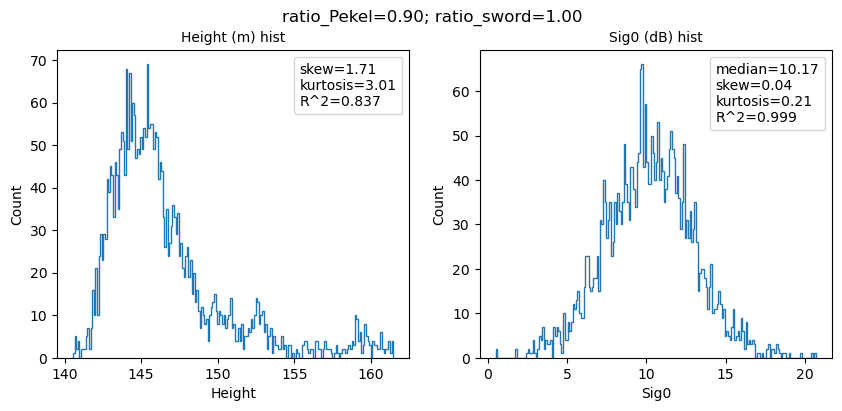

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.416271954743841 34.23757509236119
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:12,093 [INFO] Ratio pekel, ratio sword: 0.8385309807139926, 1.0
2026-02-12 08:24:12,094 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):19.724384307861328, 0.15572170913219452, -0.3250807225704193, -0.6913790702819824, 0.3571653366088867, 0.9870742136822267, 0.9939824389088753


Body type: WATER
Bathtub ring method is applied

Processing Label 22 / 104


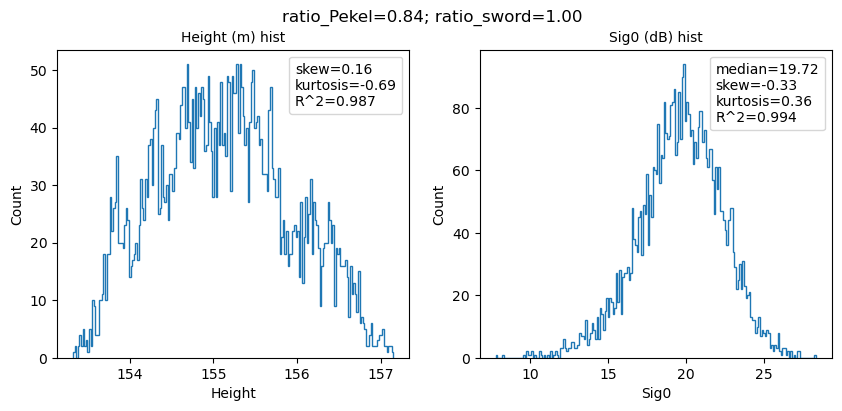

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.269552296671101 34.262379568759123
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:12,382 [INFO] Ratio pekel, ratio sword: 0.6404109589041096, 0.7123287671232876
2026-02-12 08:24:12,383 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.979042053222656, 0.6412875056266785, 0.030985984951257706, -0.44894981384277344, 0.014174461364746094, 0.935835756367854, 0.9996677554438338


Body type: WATER
Bathtub ring method is applied

Processing Label 23 / 104


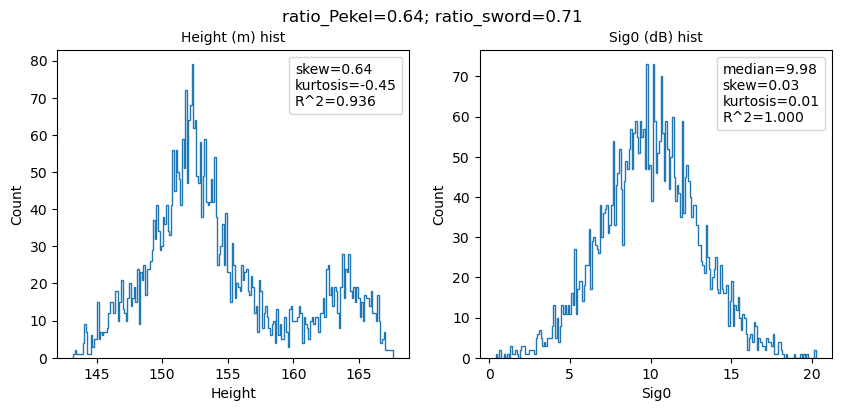

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.432642589327983 34.245904433224084
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:12,735 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:12,735 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.13116455078125, 0.054141949862241745, -0.22539237141609192, -0.3808457851409912, 0.03857088088989258, 0.9926029206119742, 0.9966328912390152


Body type: WATER
Bathtub ring method is applied

Processing Label 24 / 104


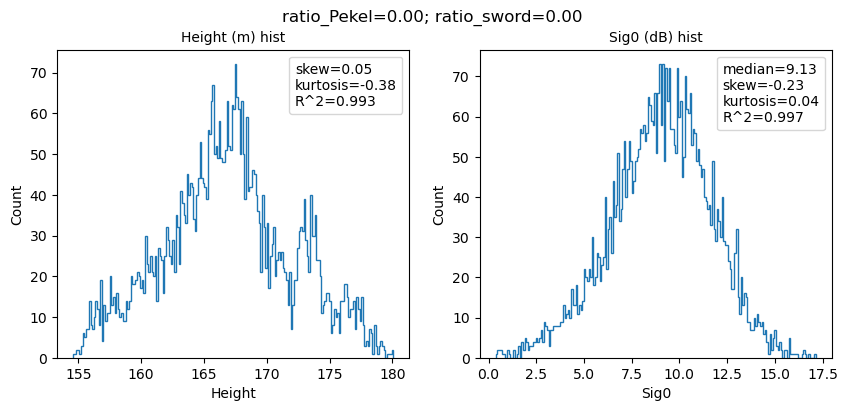

Body type: LAND

Processing Label 25 / 104


/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:14,792 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:14,793 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.050292015075684, 0.4975336194038391, 0.11213859170675278, -0.060059547424316406, 0.25231456756591797, 0.975502149519327, 0.998409785801629


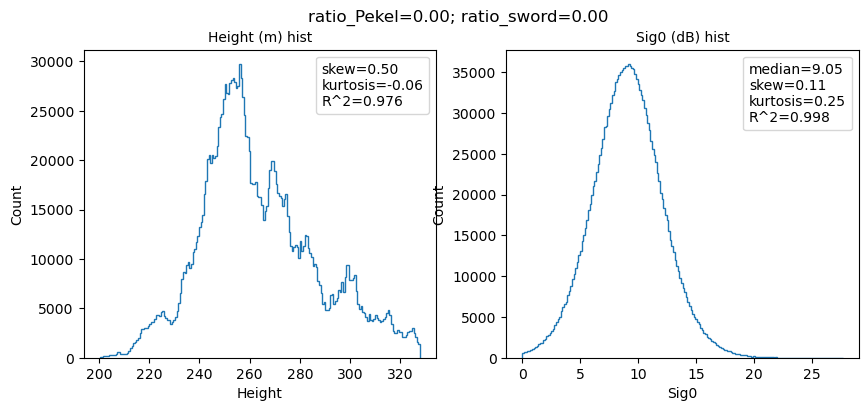

2026-02-12 08:24:15,131 [INFO] Ratio pekel, ratio sword: 1.0, 1.0
2026-02-12 08:24:15,131 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):23.71354103088379, -0.009935506619513035, -0.9424498677253723, -0.448822021484375, 1.2028651237487793, 0.9963396809114375, 0.9499721130017009


Body type: LAND

Processing Label 26 / 104


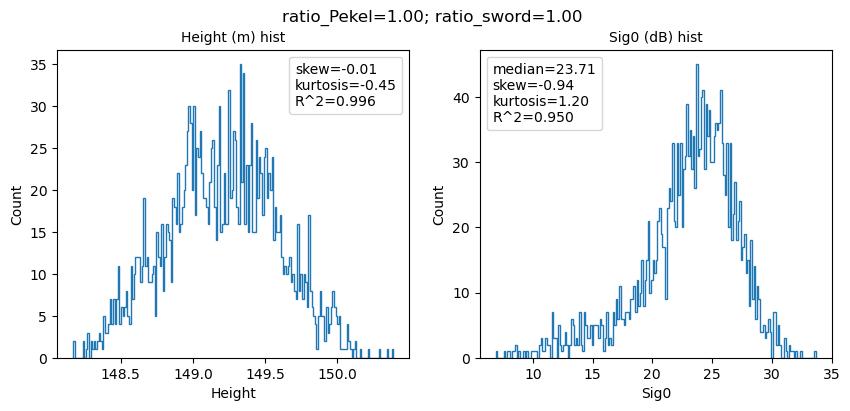

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.206220465993255 34.302851448910495
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:15,446 [INFO] Ratio pekel, ratio sword: 1.0, 1.0
2026-02-12 08:24:15,447 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):18.600440979003906, 0.07651098072528839, -0.30874431133270264, -0.7903749942779541, 0.44693922996520996, 0.9851806509466411, 0.9937880416362314


Body type: WATER
Bathtub ring method is applied

Processing Label 27 / 104


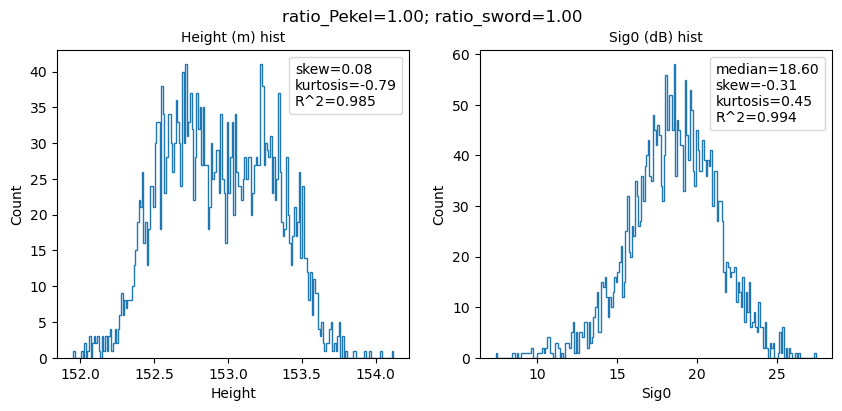

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.240031009415674 34.292307695601956
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:15,741 [INFO] Ratio pekel, ratio sword: 0.34334600760456274, 1.0
2026-02-12 08:24:15,742 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):19.45833969116211, -0.23788367211818695, -0.6643548607826233, -0.15708589553833008, 0.9069669246673584, 0.9929367032449673, 0.975971862131321


Body type: WATER
Bathtub ring method is applied

Processing Label 28 / 104


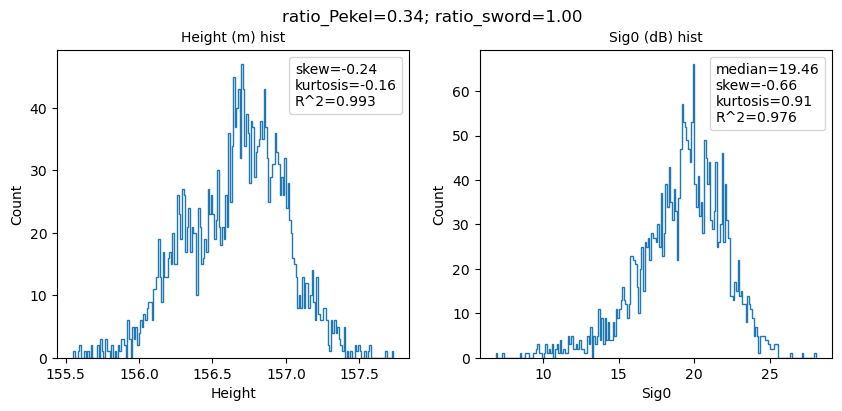

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.289131568486518 34.281536684252345
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:16,038 [INFO] Ratio pekel, ratio sword: 0.8049689440993789, 0.03146997929606625
2026-02-12 08:24:16,039 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.208288192749023, 0.49004533886909485, 0.10279403626918793, 0.0666205883026123, 0.06496238708496094, 0.9815497374863507, 0.9990813453265952


Body type: WATER
Bathtub ring method is applied

Processing Label 29 / 104


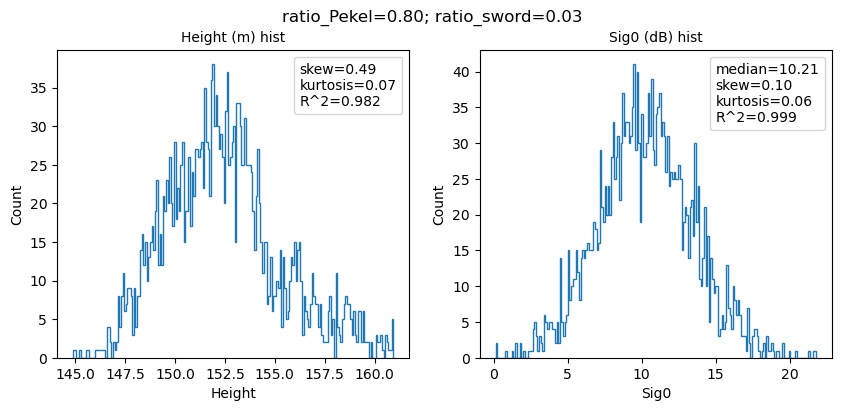

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.449399259351246 34.264589368347956
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:16,380 [INFO] Ratio pekel, ratio sword: 0.4241273286308555, 0.5534454693434617
2026-02-12 08:24:16,381 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.819232940673828, 0.05104374885559082, 0.11095385253429413, -0.5685105323791504, -0.0014965534210205078, 0.9903820348319521, 0.9988103265735231


Body type: WATER
Bathtub ring method is applied

Processing Label 30 / 104


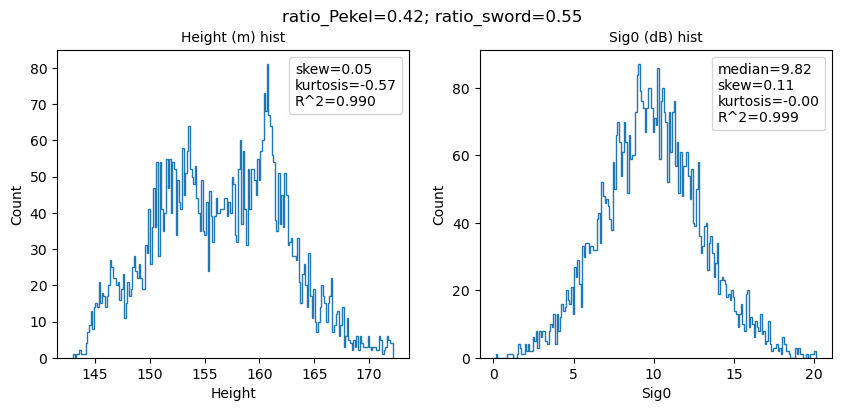

Body type: WATER
Bathtub ring method is applied

Processing Label 31 / 104


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.443821010343065 34.278676729276754
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:16,759 [INFO] Ratio pekel, ratio sword: 0.8821714990746453, 1.0
2026-02-12 08:24:16,759 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):22.36737060546875, -0.48438379168510437, -0.21480056643486023, -1.0456987619400024, -0.6786086559295654, 0.9189032568070274, 0.9852719263253904


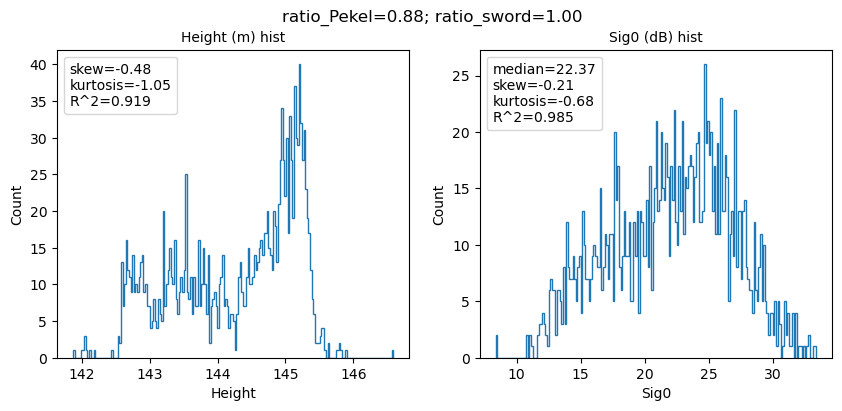

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.140555666874704 34.321810933881977
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:17,111 [INFO] Ratio pekel, ratio sword: 1.0, 1.0
2026-02-12 08:24:17,112 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):18.874027252197266, -0.3167894184589386, -0.2746511697769165, -1.196668028831482, 0.4903261661529541, 0.9372889007625631, 0.9933088243181755


Body type: WATER
Bathtub ring method is applied

Processing Label 32 / 104


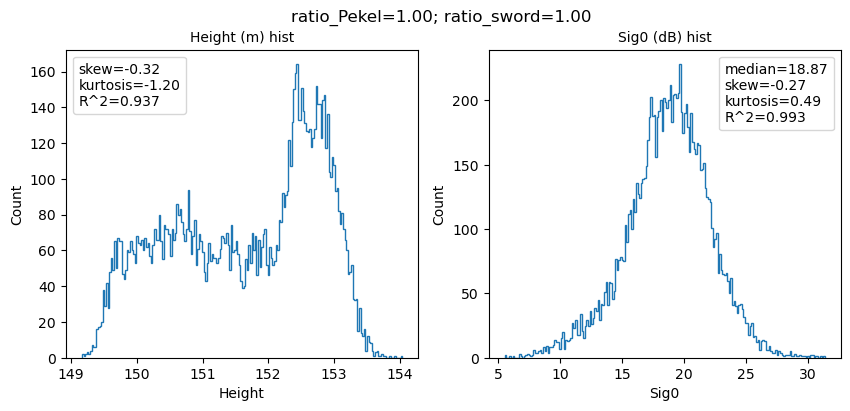

Body type: WATER
Bathtub ring method is applied

Processing Label 33 / 104


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.257964080877571 34.316204429095741
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:17,592 [INFO] Ratio pekel, ratio sword: 0.6155909276427031, 1.0
2026-02-12 08:24:17,592 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.744223594665527, 0.39146003127098083, 0.12930777668952942, -1.232039213180542, 0.1495347023010254, 0.9155884682178504, 0.9988642690133677


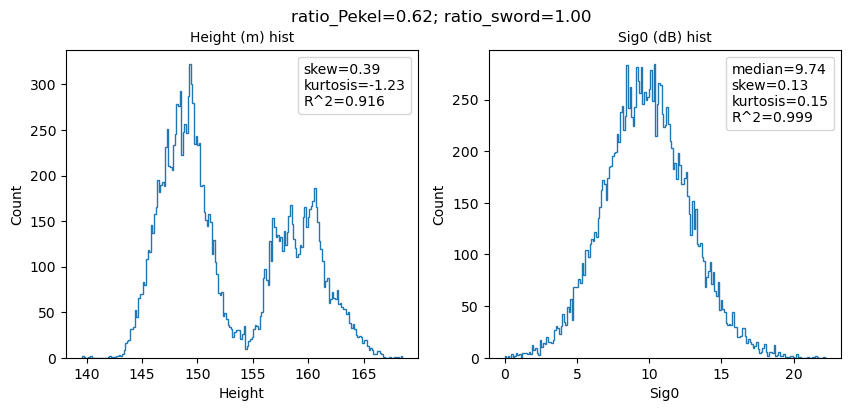

Body type: WATER
Bathtub ring method is applied


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.352312389678694 34.311493985007658
  return _ogr.Geometry_IsValid(self, *args)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:18,341 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:18,342 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.415741920471191, 0.08172900974750519, -0.25103968381881714, -0.010040760040283203, -0.2861154079437256, 0.9978083739666217, 0.9935724864461344



Processing Label 34 / 104


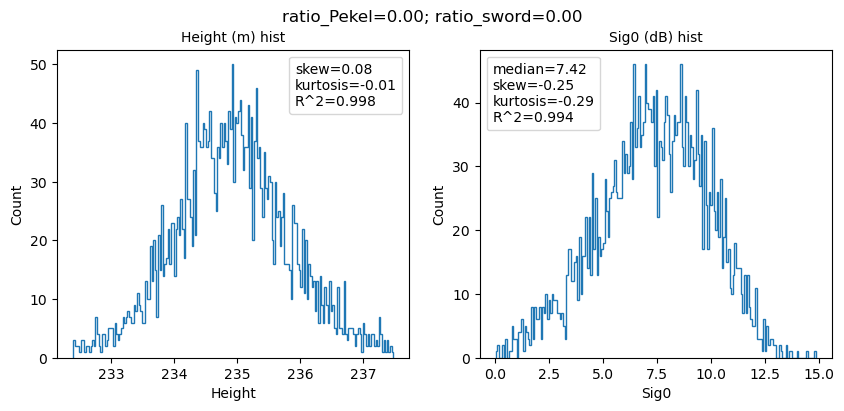

2026-02-12 08:24:18,619 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:18,620 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.146995544433594, 1.3013814687728882, -0.13673973083496094, 1.6367135047912598, 0.019931793212890625, 0.8898879988023798, 0.9976856857819679


Body type: LAND

Processing Label 35 / 104


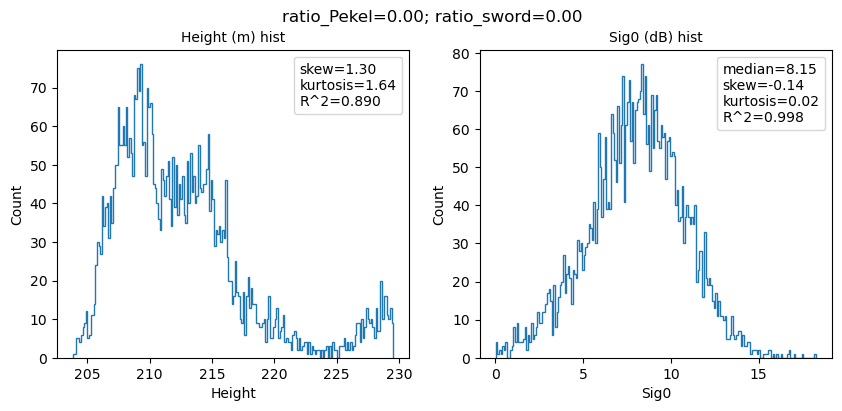

2026-02-12 08:24:18,924 [INFO] Ratio pekel, ratio sword: 0.4846710299689976, 0.9207716155700999
2026-02-12 08:24:18,924 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.134703636169434, 0.44234374165534973, 0.08217115700244904, -0.5239109992980957, -0.08873295783996582, 0.9726615398719892, 0.9989712879390023


Body type: LAND

Processing Label 36 / 104


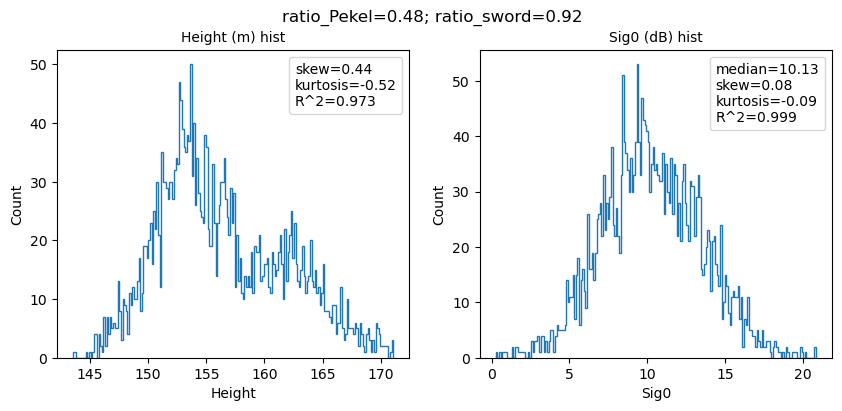

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.422725393214805 34.288762747752223
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:19,249 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:19,250 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.304308891296387, 0.6525882482528687, -0.17848122119903564, 0.9053139686584473, 0.16183757781982422, 0.9737173225044974, 0.9967937346615376


Body type: WATER
Bathtub ring method is applied

Processing Label 37 / 104


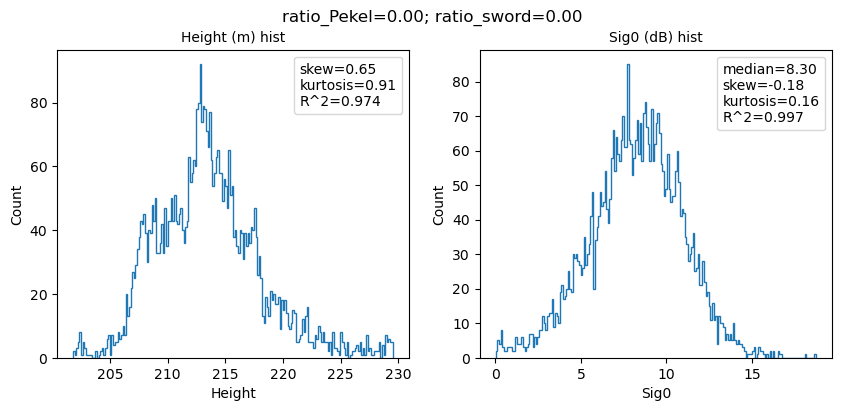

2026-02-12 08:24:19,525 [INFO] Ratio pekel, ratio sword: 0.0004087750374710451, 0.5780079029840578
2026-02-12 08:24:19,525 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.744803428649902, -0.3902946412563324, 0.1162935122847557, -0.24152565002441406, 0.1567821502685547, 0.9812388681324519, 0.9987205699628303


Body type: LAND

Processing Label 38 / 104


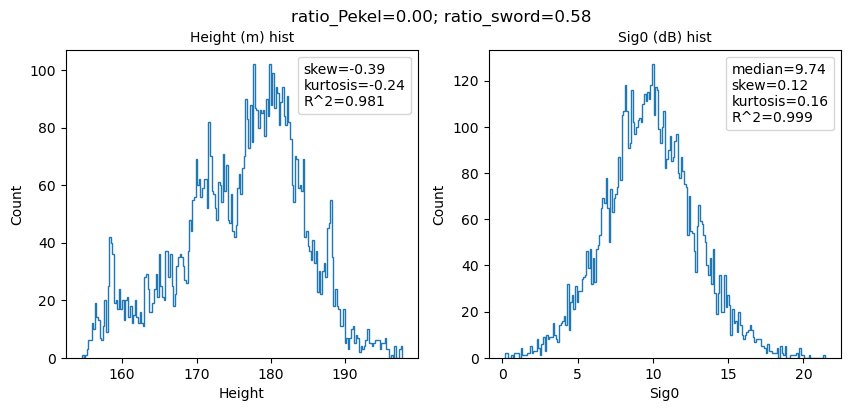

Body type: WATER
Bathtub ring method is applied

Processing Label 39 / 104


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.449689862469675 34.336933223643811
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:19,921 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:19,922 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.60572624206543, -0.6210317611694336, -0.06672389805316925, 0.3254091739654541, 0.02921462059020996, 0.9201710206776792, 0.9990356146854198


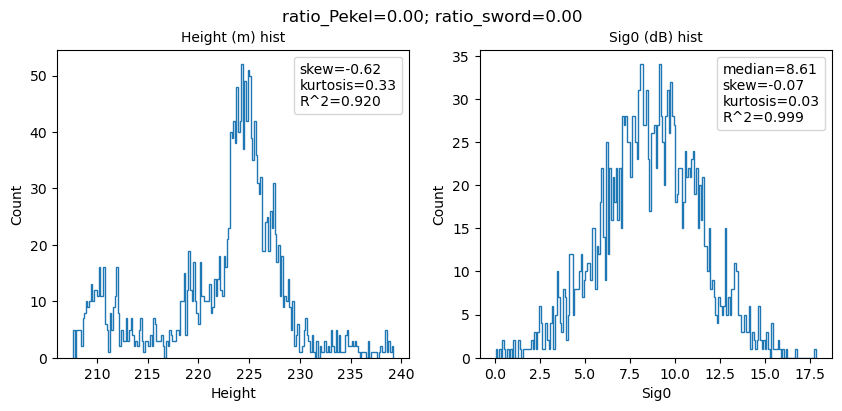

2026-02-12 08:24:20,204 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:20,204 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.792457580566406, 0.8801391124725342, 0.06664625555276871, -0.3466043472290039, 0.26184940338134766, 0.8914324507745864, 0.9984778800730058


Body type: LAND

Processing Label 40 / 104


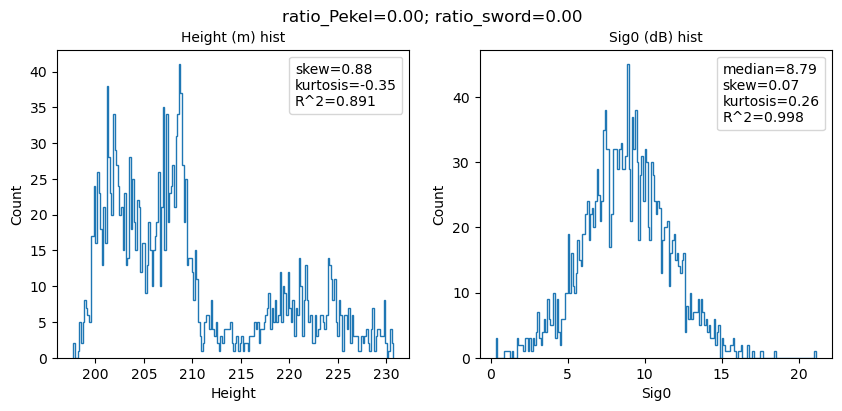

2026-02-12 08:24:20,507 [INFO] Ratio pekel, ratio sword: 1.0, 1.0
2026-02-12 08:24:20,508 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):18.2728328704834, -0.05404145270586014, -0.3839684724807739, -0.9476754665374756, 0.6781520843505859, 0.9691550205597664, 0.9895286194685993


Body type: LAND

Processing Label 41 / 104


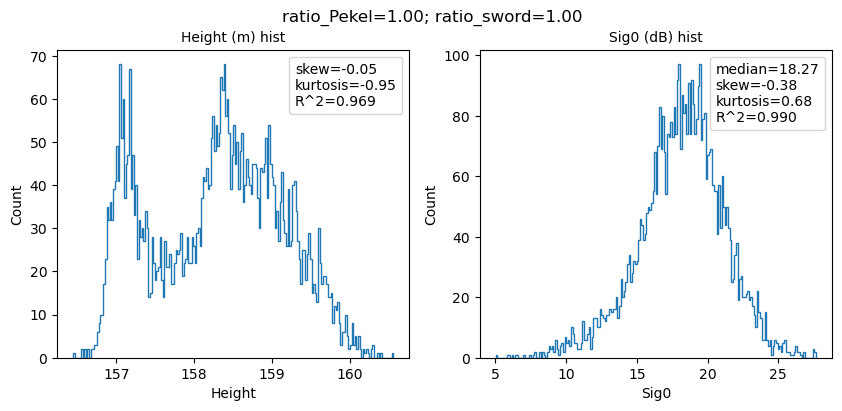

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.331308556065053 34.360055383178711
  return _ogr.Geometry_IsValid(self, *args)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:20,851 [INFO] Ratio pekel, ratio sword: 0.033408006233563846, 0.0007791954806662121
2026-02-12 08:24:20,851 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.709733963012695, 0.28912678360939026, -0.11822815239429474, -0.5684690475463867, 0.1264190673828125, 0.9843517061545721, 0.9988059962589263


Body type: WATER
Bathtub ring method is applied

Processing Label 42 / 104


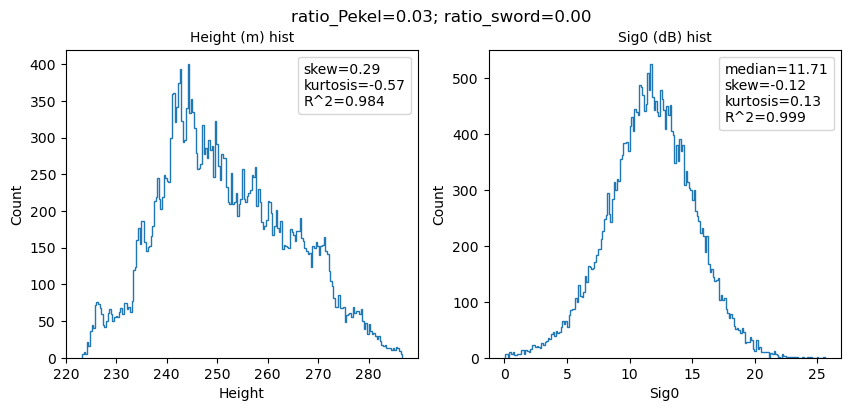

2026-02-12 08:24:21,136 [INFO] Ratio pekel, ratio sword: 0.0, 1.0
2026-02-12 08:24:21,136 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.459909439086914, 0.8862866759300232, 0.16523794829845428, 0.42092370986938477, 0.17641830444335938, 0.9413128528936431, 0.997630508990598


Body type: LAND

Processing Label 43 / 104


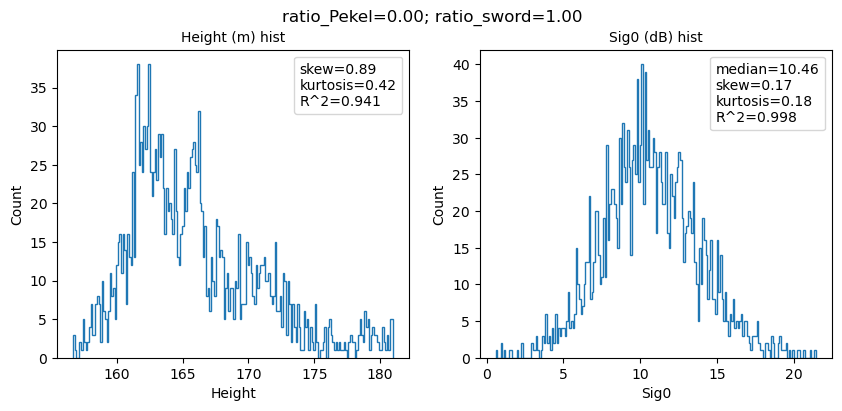

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.375338499802588 34.371907764868006
  return _ogr.Geometry_IsValid(self, *args)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:21,434 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:21,435 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.567415237426758, 0.20073428750038147, -0.18081417679786682, -1.2249165773391724, 0.0654299259185791, 0.947993842039997, 0.9955870707944642


Body type: WATER
Bathtub ring method is applied

Processing Label 44 / 104


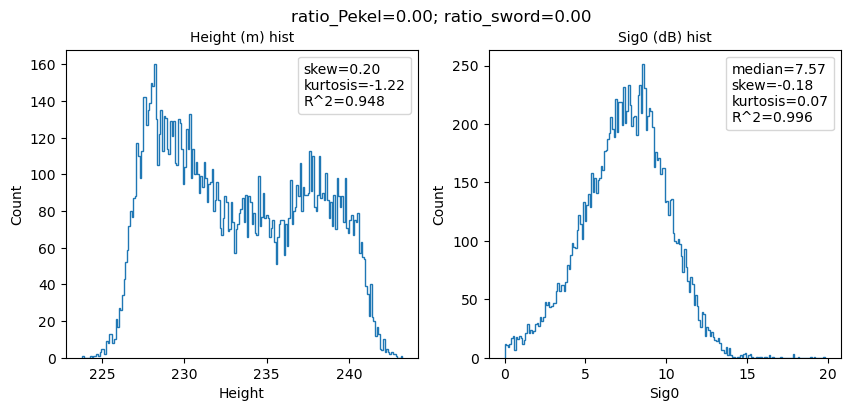

2026-02-12 08:24:21,719 [INFO] Ratio pekel, ratio sword: 0.0, 0.903115663679044
2026-02-12 08:24:21,719 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.916889190673828, 0.596709668636322, 0.17827795445919037, -0.3030095100402832, 0.193983793258667, 0.9573585600340505, 0.9971734023778585


Body type: LAND

Processing Label 45 / 104


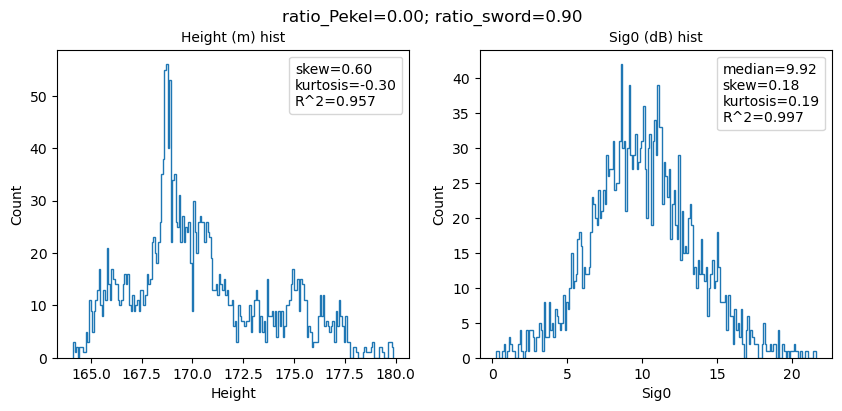

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.275157985474074 34.384045670146861
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:22,010 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:22,011 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.083088874816895, -0.47692856192588806, -0.2283509075641632, -0.07870292663574219, -0.032254695892333984, 0.9697216000720899, 0.9956749175228474


Body type: WATER
Bathtub ring method is applied

Processing Label 46 / 104


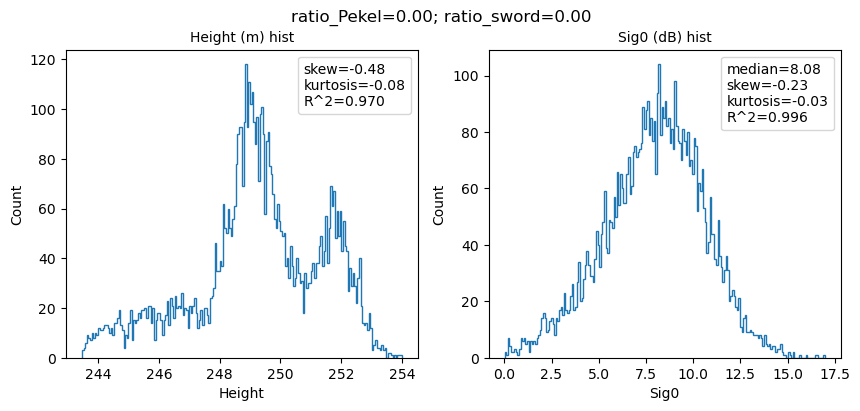

2026-02-12 08:24:22,307 [INFO] Ratio pekel, ratio sword: 0.1644108280254777, 0.8805732484076433
2026-02-12 08:24:22,308 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.647757530212402, 0.5766225457191467, 0.016356775537133217, 0.13657927513122559, 0.009610176086425781, 0.9684833529808848, 0.999288638057029


Body type: LAND

Processing Label 47 / 104


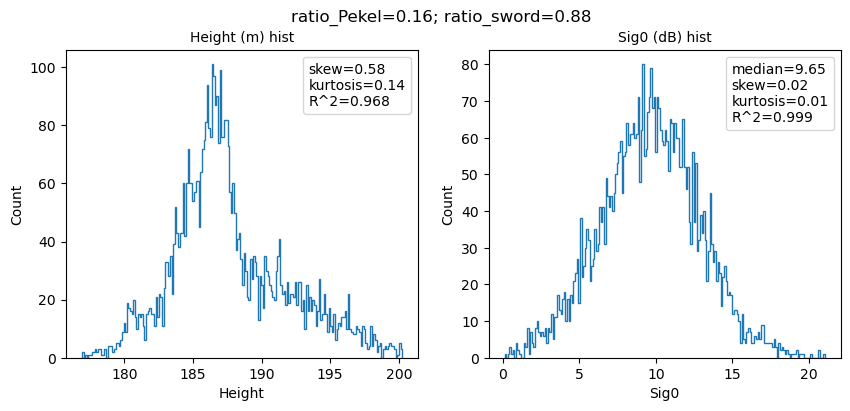

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.333214041458092 34.403433918462014
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 08:24:22,622 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:22,622 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.830300807952881, 0.737271785736084, -0.13322658836841583, -0.2851753234863281, 0.05540132522583008, 0.9385239830411624, 0.9974642545996636


Body type: WATER
Bathtub ring method is applied

Processing Label 48 / 104


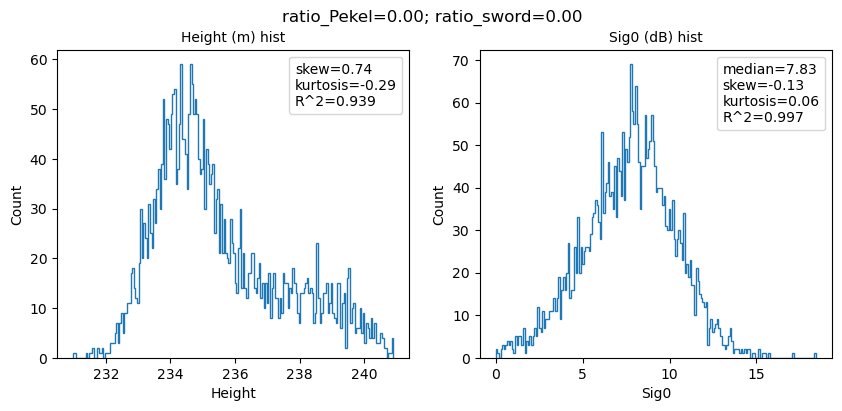

2026-02-12 08:24:22,898 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:22,899 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.857250213623047, 0.6141991019248962, 0.021153049543499947, -0.42202043533325195, 0.16456937789916992, 0.9475528868884534, 0.9987724281185061


Body type: LAND

Processing Label 49 / 104


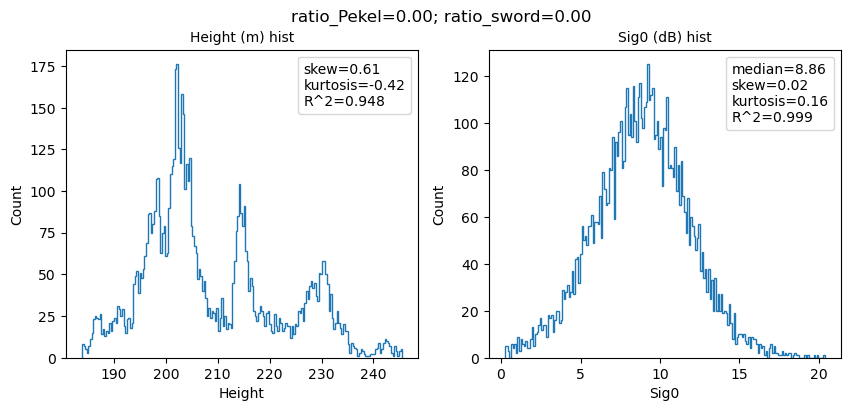

2026-02-12 08:24:23,209 [INFO] Ratio pekel, ratio sword: 0.0, 0.02325243423920942
2026-02-12 08:24:23,210 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.822519302368164, 0.5266530513763428, 0.13887260854244232, -0.838646650314331, 0.13117265701293945, 0.9299224151316859, 0.9986306283764982


Body type: LAND

Processing Label 50 / 104


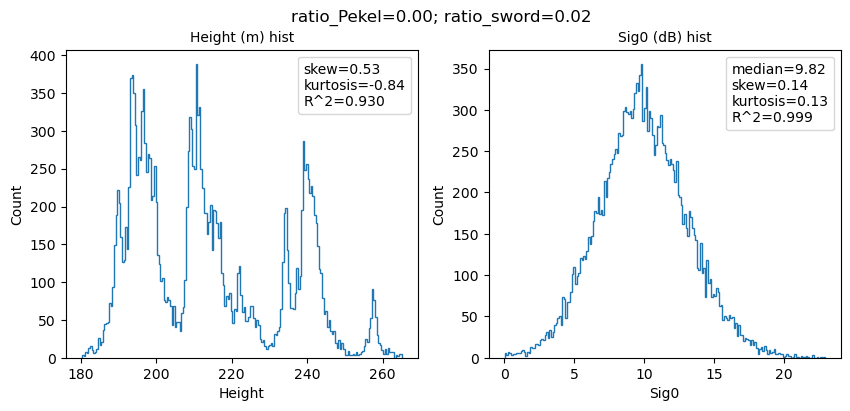

2026-02-12 08:24:23,487 [INFO] Ratio pekel, ratio sword: 0.013092813500145475, 0.03607797497817864
2026-02-12 08:24:23,487 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.267568588256836, 0.6043084859848022, 0.06481523811817169, -0.6491992473602295, 0.20343327522277832, 0.9360642422770632, 0.9985928826161699


Body type: LAND

Processing Label 51 / 104


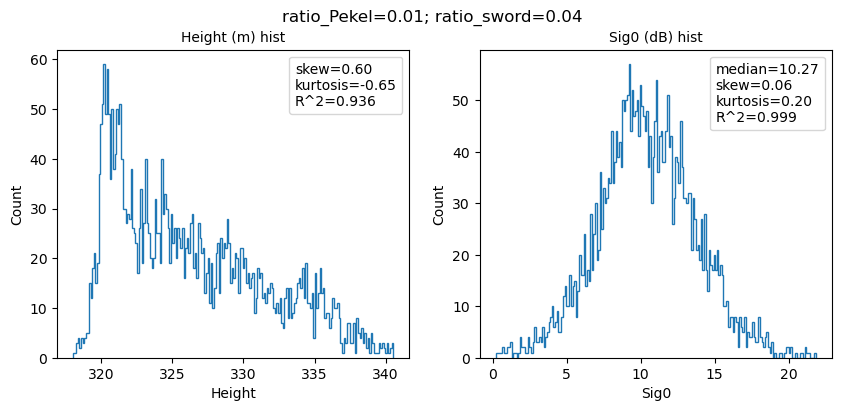

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:23,757 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:23,758 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.596173286437988, 0.5265941023826599, -0.13888154923915863, -0.29216814041137695, -0.04088163375854492, 0.9691162759391707, 0.9973326862268589


Body type: LAND

Processing Label 52 / 104


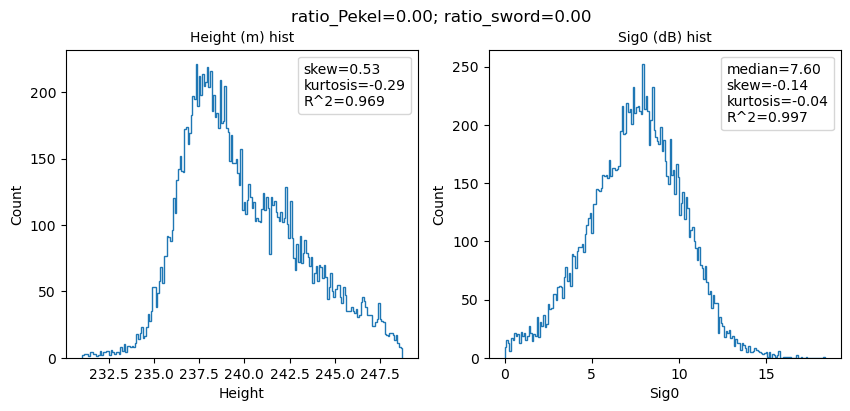

2026-02-12 08:24:24,024 [INFO] Ratio pekel, ratio sword: 0.022477522477522476, 0.0
2026-02-12 08:24:24,024 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.705620765686035, 0.29729163646698, 0.041539549827575684, -0.6836569309234619, 0.1021413803100586, 0.9797205369068556, 0.9992037973798878


Body type: LAND

Processing Label 53 / 104


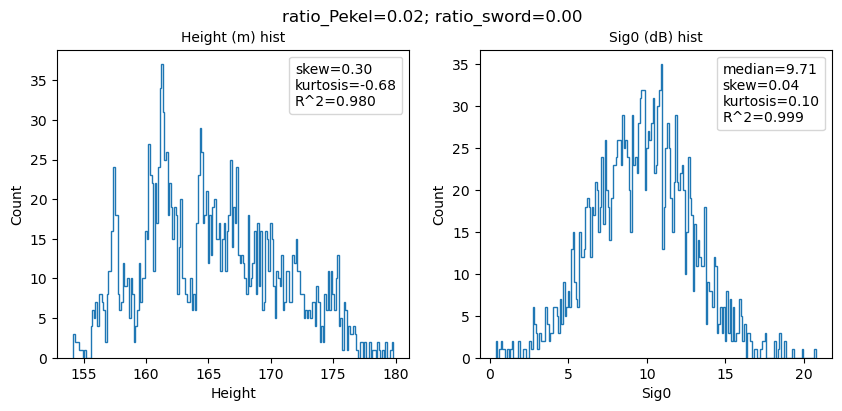

2026-02-12 08:24:24,324 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:24,324 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.254595756530762, 0.009418369270861149, 0.10302980244159698, -0.5413100719451904, -0.04888296127319336, 0.9911876418283345, 0.9986859739172677


Body type: LAND

Processing Label 54 / 104


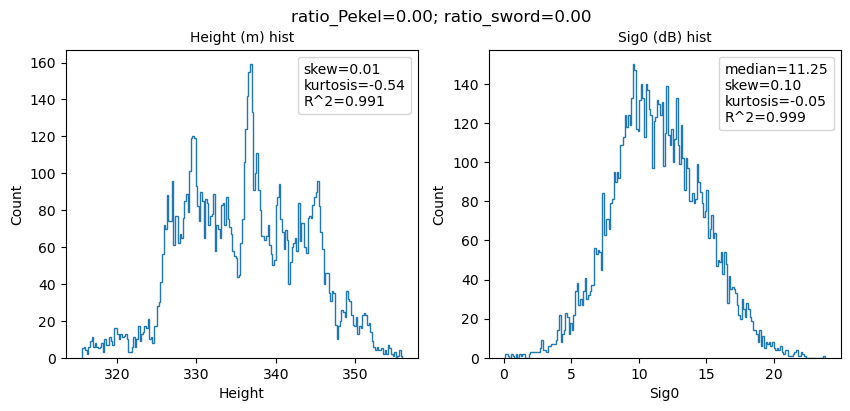

2026-02-12 08:24:24,606 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:24,606 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.175869941711426, -0.2539697289466858, 0.003770440584048629, 0.3981006145477295, 0.27797818183898926, 0.9450131880733735, 0.9981685828306681


Body type: LAND

Processing Label 55 / 104


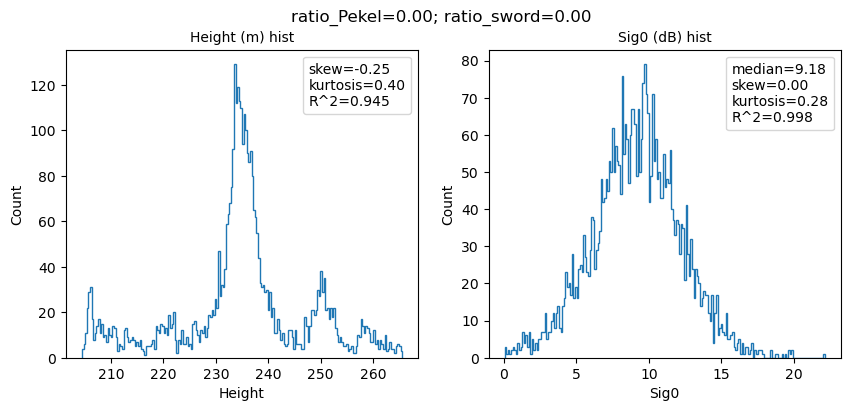

2026-02-12 08:24:24,908 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:24,909 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.239501953125, 0.29651176929473877, 0.04833434149622917, -1.2630019187927246, 0.21835803985595703, 0.9210464752401227, 0.9985149692512335


Body type: LAND

Processing Label 56 / 104


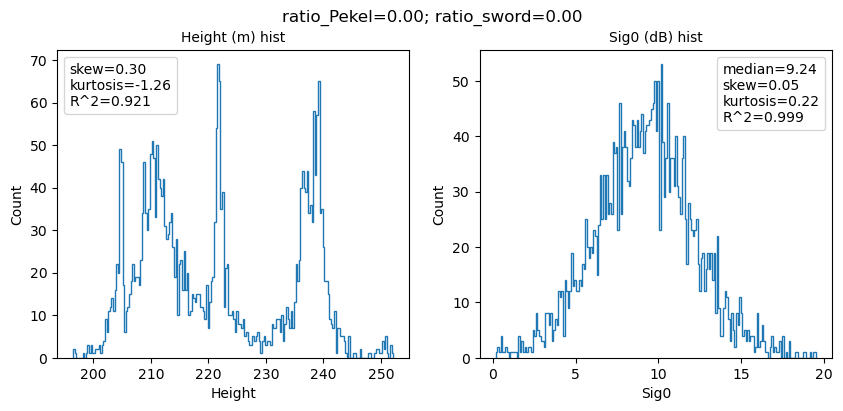

2026-02-12 08:24:25,212 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:25,213 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.417366027832031, 0.28853511810302734, 0.09978964179754257, 0.11469340324401855, 0.261171817779541, 0.9562654603852191, 0.9985220831200383


Body type: LAND

Processing Label 57 / 104


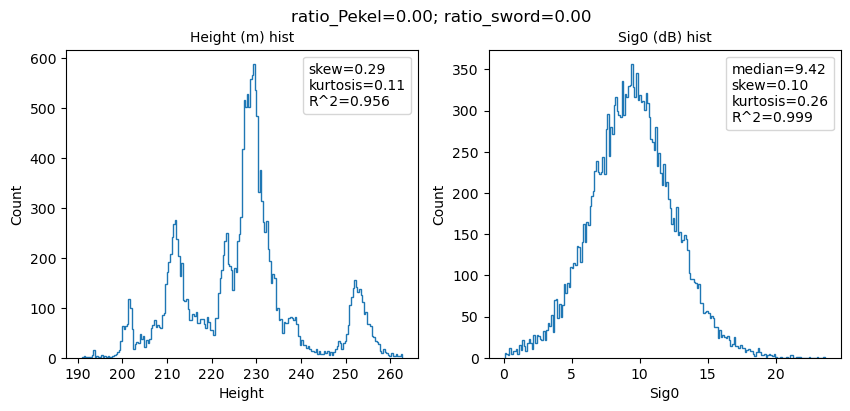

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:25,493 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:25,493 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.035224914550781, 0.08154460042715073, 0.11359445005655289, -0.8480582237243652, 0.4776616096496582, 0.9822126212629173, 0.9944834012141994


Body type: LAND

Processing Label 58 / 104


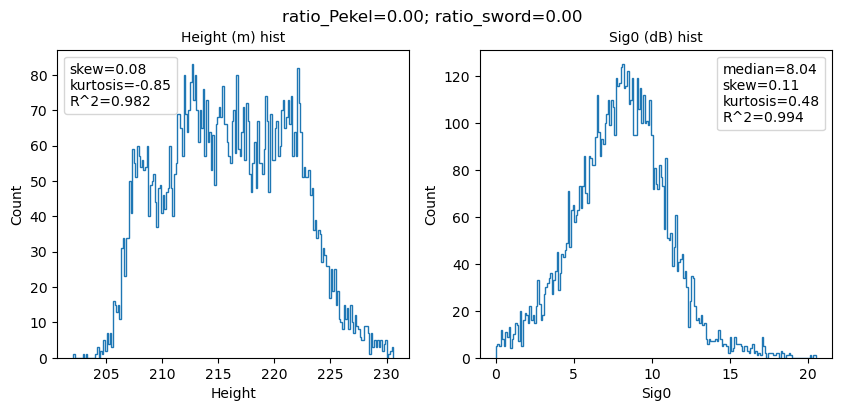

2026-02-12 08:24:25,788 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:25,788 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.410684585571289, 0.2775603234767914, 0.025282375514507294, -1.1059387922286987, 0.2198925018310547, 0.9203176659175907, 0.9990429833387908


Body type: LAND

Processing Label 59 / 104


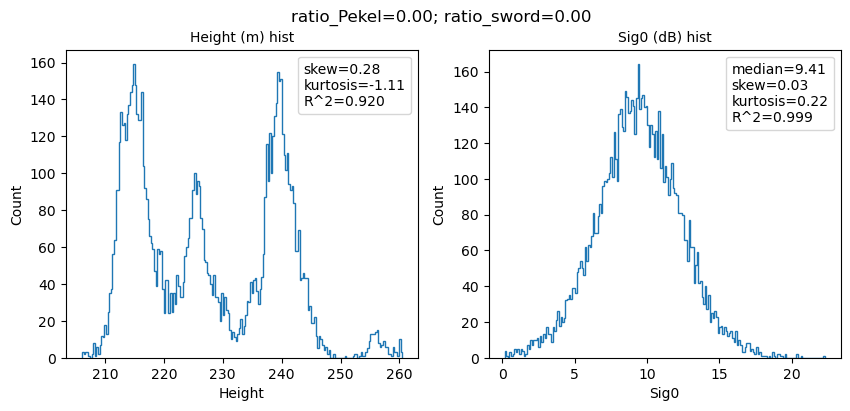

2026-02-12 08:24:26,088 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:26,089 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.729671478271484, 0.12416928261518478, 0.10365082323551178, -0.7883903980255127, -0.010980844497680664, 0.9822367934836131, 0.9988988443426052


Body type: LAND

Processing Label 60 / 104


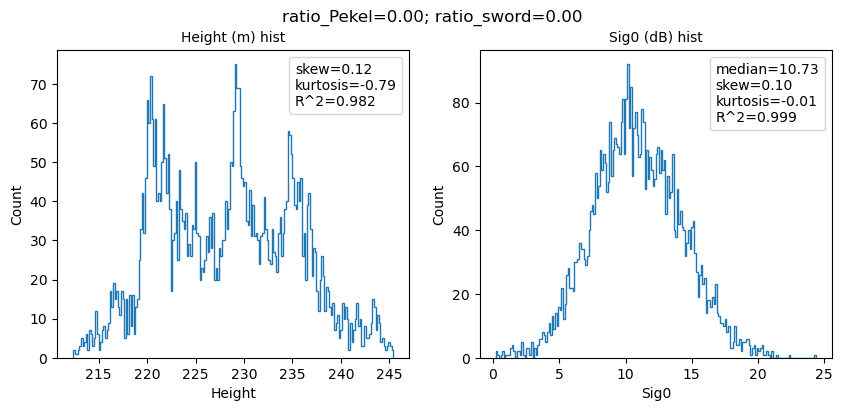

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:26,377 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:26,377 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.953546524047852, 0.1456318199634552, -0.25798600912094116, -0.13562750816345215, -0.12753987312316895, 0.9978743137080537, 0.9937774472143996


Body type: LAND

Processing Label 61 / 104


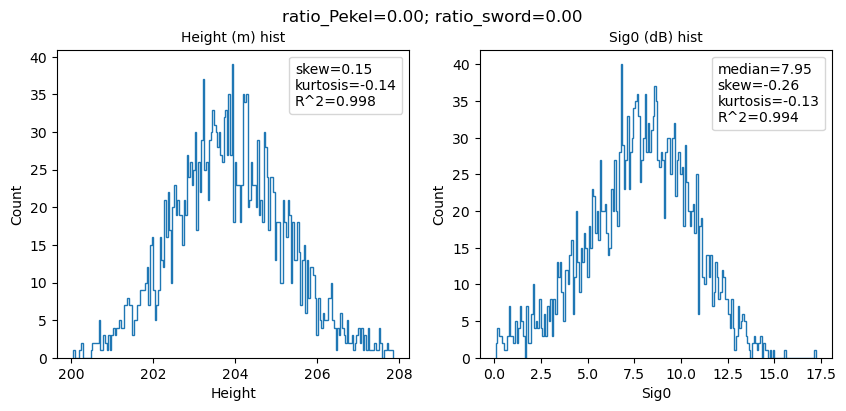

2026-02-12 08:24:26,668 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:26,668 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.961904525756836, 0.2855347692966461, 0.003219755832105875, -0.23371315002441406, 0.01267695426940918, 0.9879541683407713, 0.9994268560031682


Body type: LAND

Processing Label 62 / 104


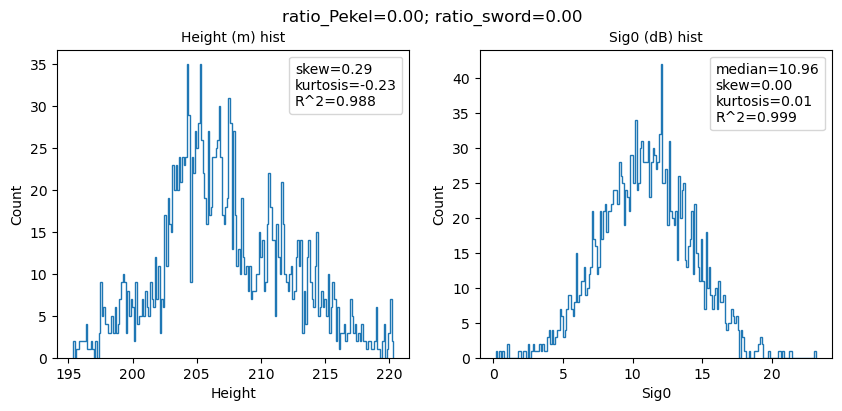

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:26,963 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:26,963 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.463752746582031, 0.17260020971298218, -0.2289104014635086, -0.15337872505187988, -0.09296083450317383, 0.9968852686821894, 0.9949241124413429


Body type: LAND

Processing Label 63 / 104


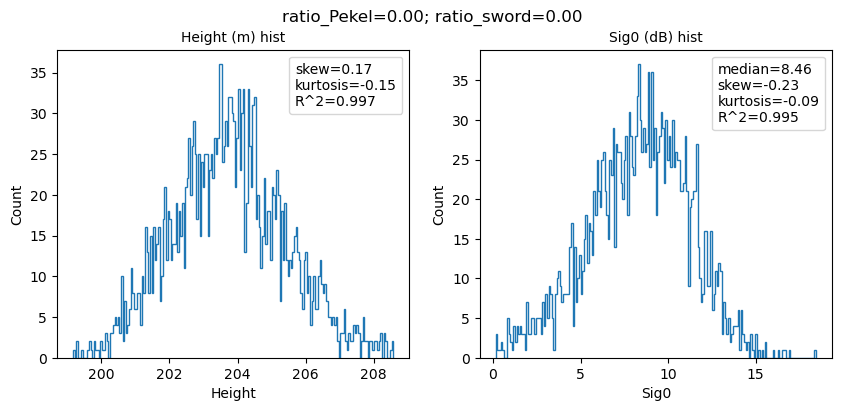

2026-02-12 08:24:27,255 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:27,255 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.104199409484863, -0.7850742340087891, 0.07304972410202026, -0.6195900440216064, 0.2650723457336426, 0.8911071935103548, 0.9976280551004598


Body type: LAND

Processing Label 64 / 104


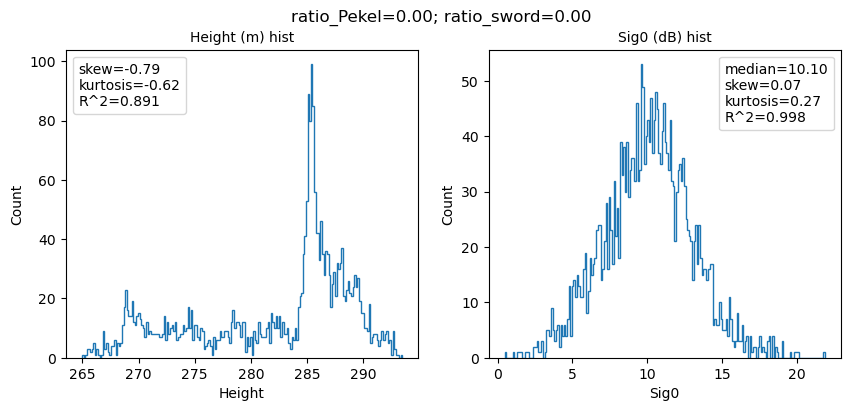

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:27,530 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:27,530 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.791489601135254, 0.1578211933374405, -0.0790548026561737, -0.2332761287689209, -0.07157516479492188, 0.9971929038257684, 0.9968801762196671


Body type: LAND

Processing Label 65 / 104


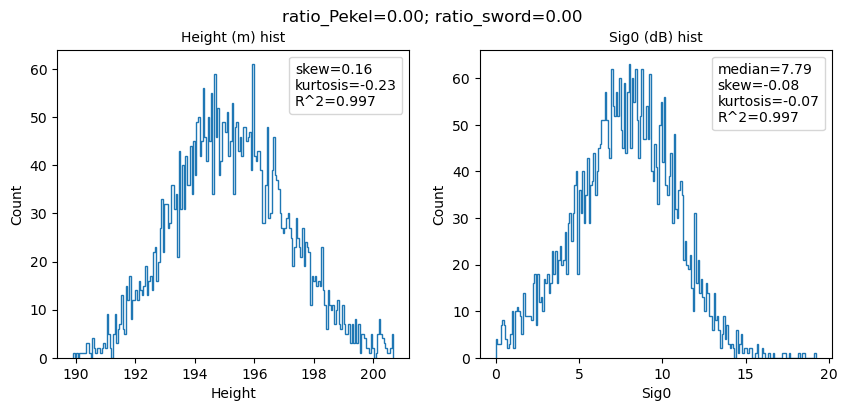

2026-02-12 08:24:27,815 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:27,816 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.739483833312988, 0.6195052266120911, 0.07809364050626755, -0.3329906463623047, 0.37412166595458984, 0.9579764511848015, 0.9981787072540776


Body type: LAND

Processing Label 66 / 104


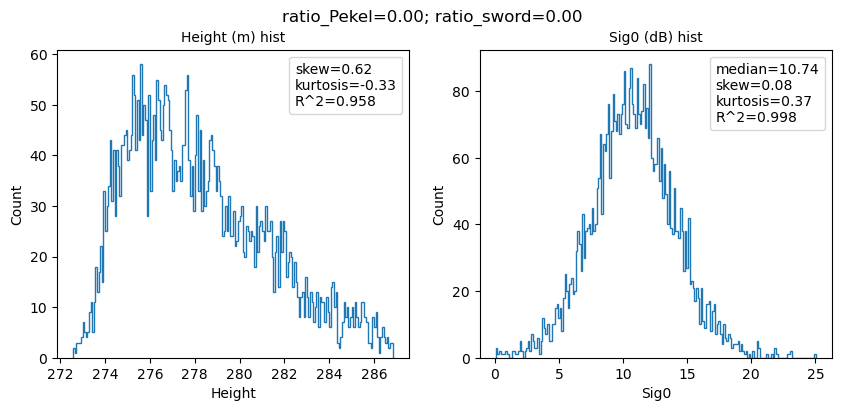

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:28,123 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:28,123 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.080501556396484, 0.4571021497249603, -0.16015562415122986, -0.6200423240661621, -0.08193135261535645, 0.9646059547617123, 0.9959030153994244


Body type: LAND

Processing Label 67 / 104


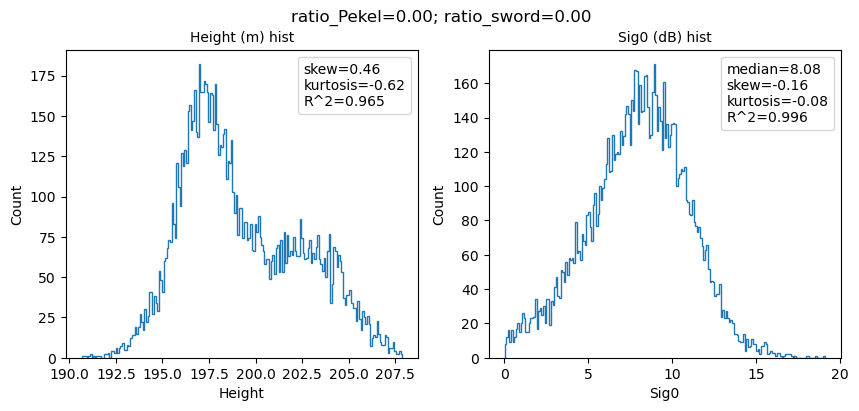

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:28,431 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:28,432 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.707931995391846, 0.010305552743375301, -0.23774386942386627, -0.5588328838348389, -0.2488880157470703, 0.9949053798126741, 0.9939697408814834


Body type: LAND

Processing Label 68 / 104


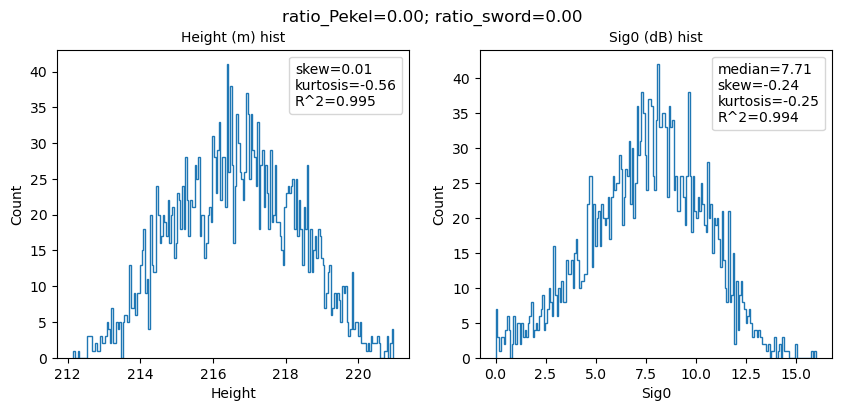

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:28,740 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:28,740 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.029033660888672, 0.17898648977279663, -0.2674694359302521, -0.6674365997314453, -0.07747769355773926, 0.9884474564179615, 0.9946628542153408


Body type: LAND

Processing Label 69 / 104


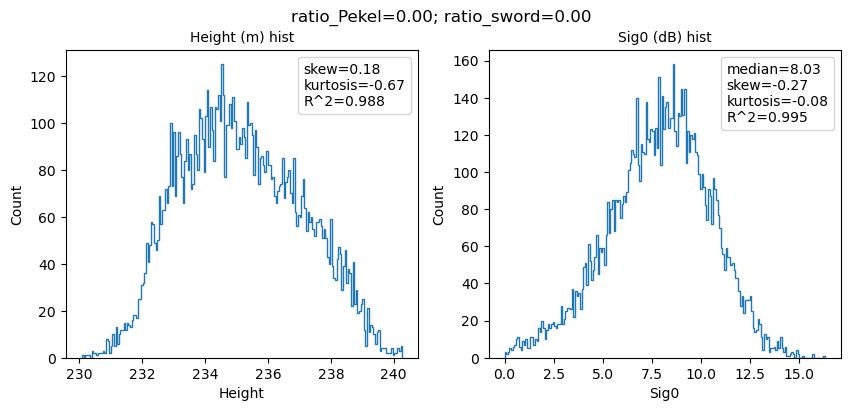

2026-02-12 08:24:29,032 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:29,032 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.044837951660156, -0.13730810582637787, -0.15503200888633728, -0.551910400390625, 0.02624678611755371, 0.9923331473523919, 0.9975550079433183


Body type: LAND

Processing Label 70 / 104


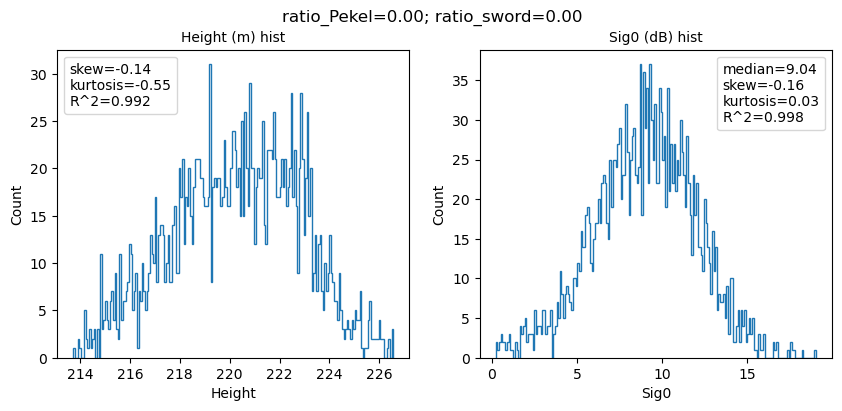

2026-02-12 08:24:29,300 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:29,300 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.659650802612305, -0.3007124960422516, 0.08803167194128036, -1.038696050643921, 0.3209648132324219, 0.9570544208271591, 0.9970784294648273


Body type: LAND

Processing Label 71 / 104


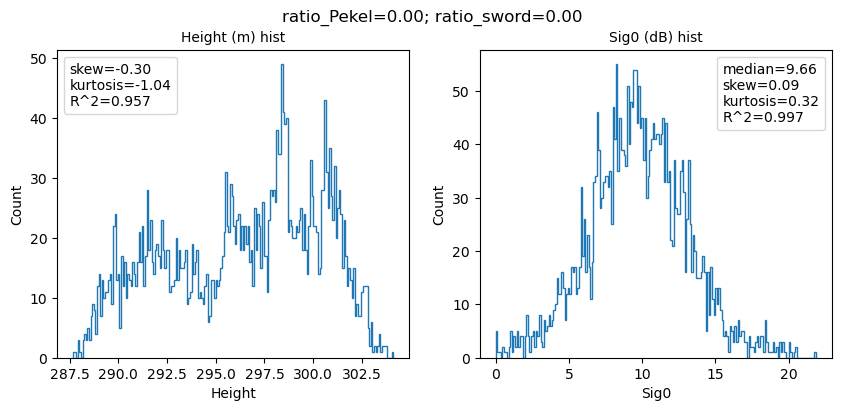

2026-02-12 08:24:29,584 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:29,585 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.37324333190918, 0.3250165581703186, 0.18849989771842957, -0.22401046752929688, 0.0747675895690918, 0.9869257067511741, 0.9973247314282154


Body type: LAND

Processing Label 72 / 104


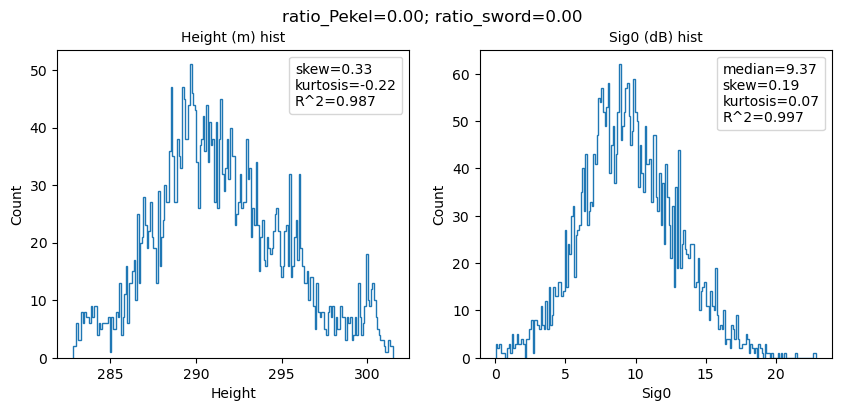

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:29,852 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:29,852 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.302739143371582, 0.23732887208461761, -0.20481932163238525, -0.9288051128387451, -0.09838032722473145, 0.9672806500227458, 0.9963287528402766


Body type: LAND

Processing Label 73 / 104


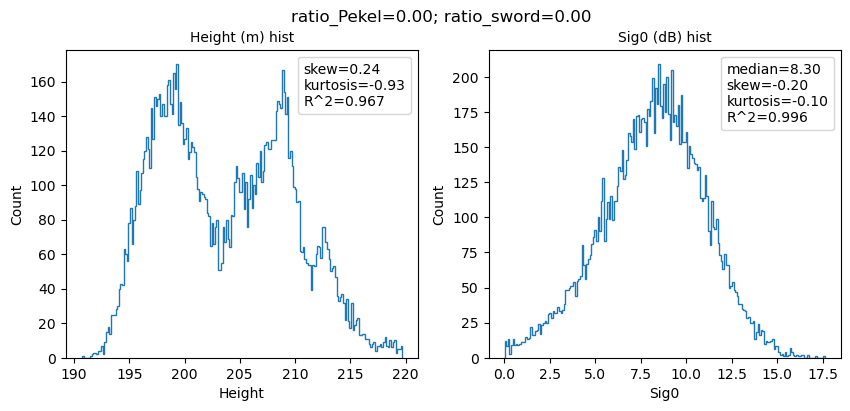

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:30,185 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:30,186 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.135499954223633, -0.02472563646733761, -0.15661151707172394, -0.4712815284729004, -0.013268470764160156, 0.9953563476394144, 0.9964582243675815


Body type: LAND

Processing Label 74 / 104


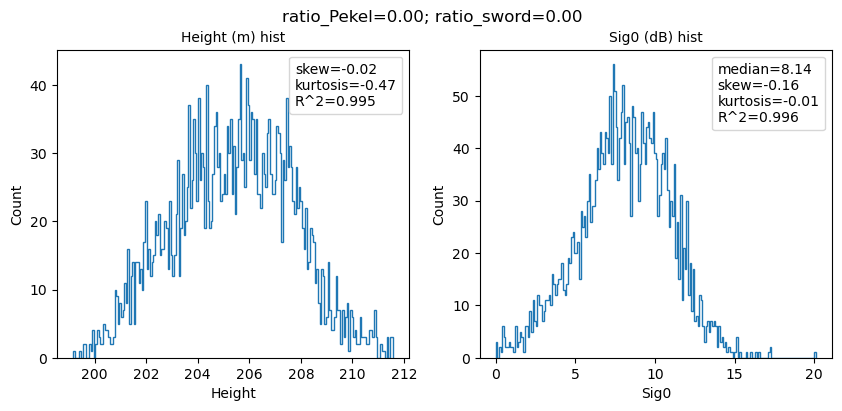

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:30,481 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:30,481 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.029561996459961, 0.25034573674201965, -0.23787285387516022, -0.03826713562011719, -0.10808086395263672, 0.9918467869443388, 0.9946522005112441


Body type: LAND

Processing Label 75 / 104


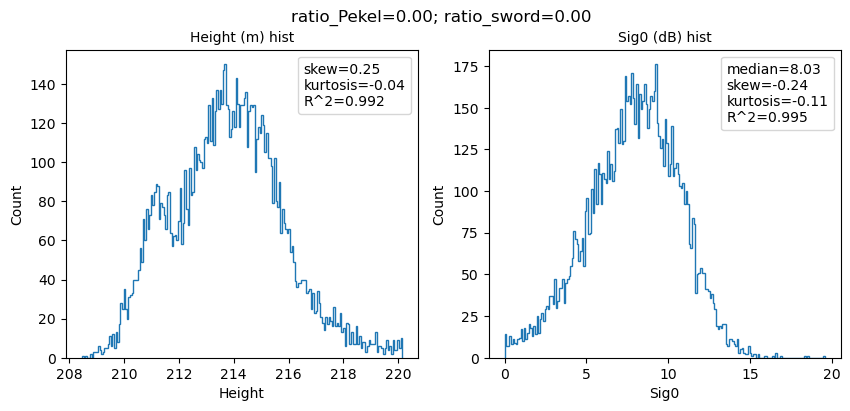

2026-02-12 08:24:30,768 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:30,769 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.945548057556152, 0.4258950650691986, 0.07019417732954025, -0.27814364433288574, 0.13259434700012207, 0.9747831440851873, 0.9990262877781021


Body type: LAND

Processing Label 76 / 104


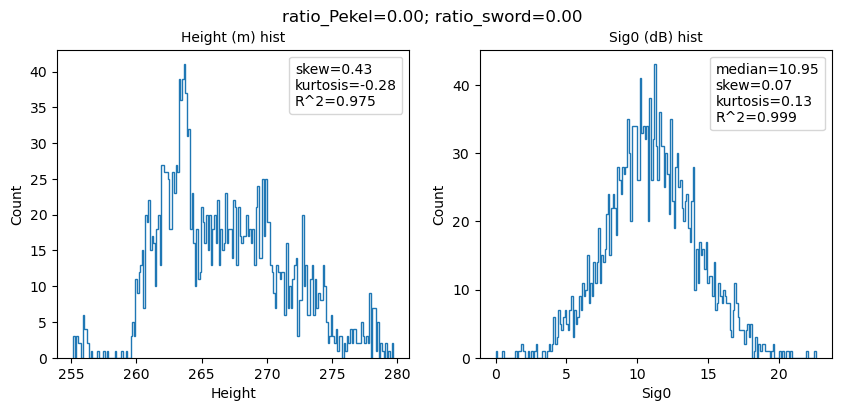

2026-02-12 08:24:31,041 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:31,042 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.607799530029297, 0.35453173518180847, -0.04849240928888321, -0.503201961517334, 0.12516236305236816, 0.9802044278180726, 0.9981874312121867


Body type: LAND

Processing Label 77 / 104


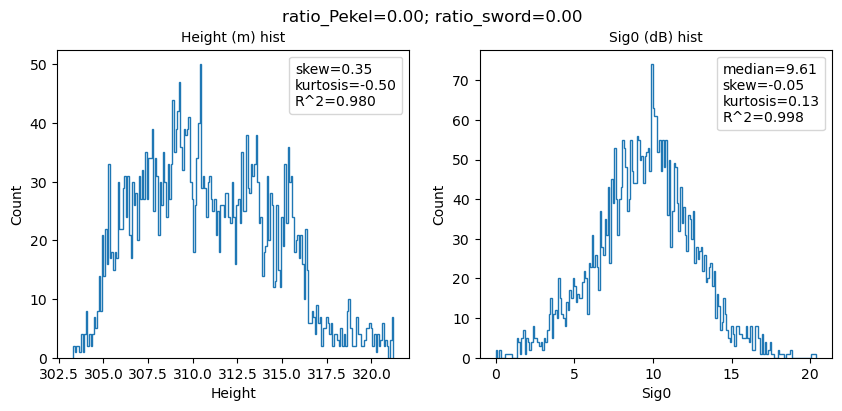

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:31,317 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:31,317 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.823525428771973, 0.9110872745513916, -0.23859161138534546, -0.17549562454223633, -0.17278170585632324, 0.9014400934306733, 0.9939996964352928


Body type: LAND

Processing Label 78 / 104


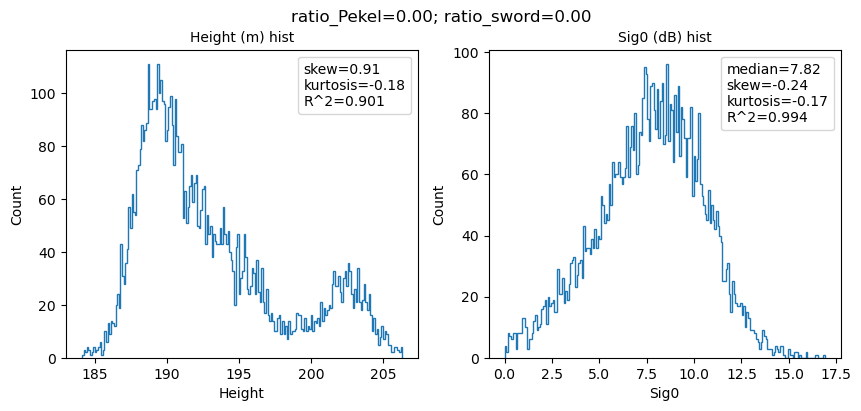

2026-02-12 08:24:31,612 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:31,613 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.134641647338867, -0.4172009229660034, 0.26012441515922546, 0.03587055206298828, 0.176530122756958, 0.9777053667539567, 0.9955912555140654


Body type: LAND

Processing Label 79 / 104


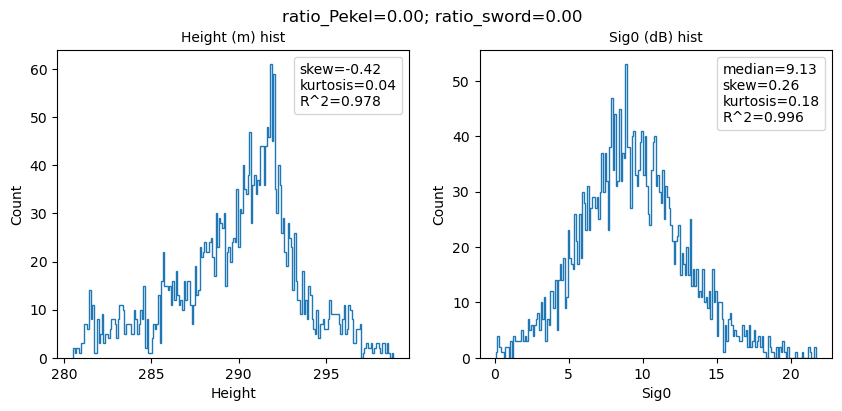

2026-02-12 08:24:31,896 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:31,896 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.880980968475342, 0.3272079527378082, -0.15166206657886505, -0.2856450080871582, -0.16339468955993652, 0.9862282172784547, 0.9976682721476117


Body type: LAND

Processing Label 80 / 104


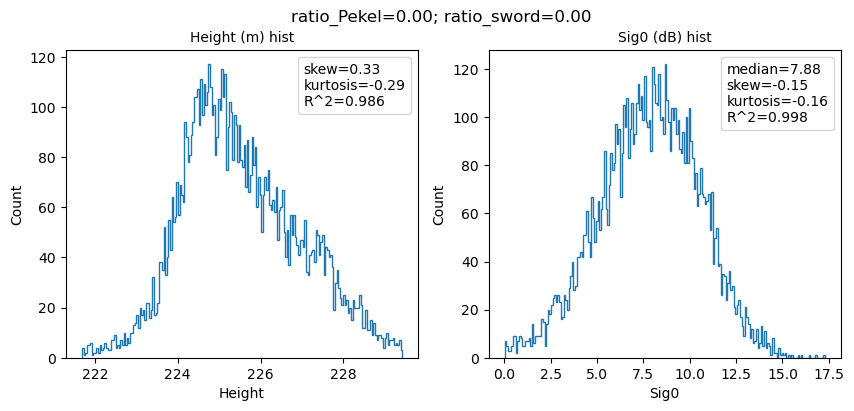

2026-02-12 08:24:32,180 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:32,180 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.605754852294922, -0.27372464537620544, -0.27512839436531067, -1.0582935810089111, 0.06002998352050781, 0.9569916075440861, 0.9950476710941591


Body type: LAND

Processing Label 81 / 104


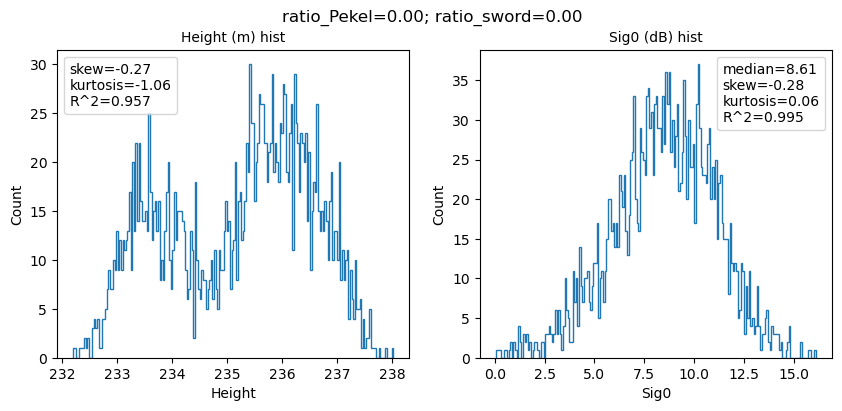

2026-02-12 08:24:32,484 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:32,485 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.288019180297852, -0.12166662514209747, -0.3026226758956909, -0.3638596534729004, 0.0844123363494873, 0.9967534147986703, 0.9939042956917927


Body type: LAND

Processing Label 82 / 104


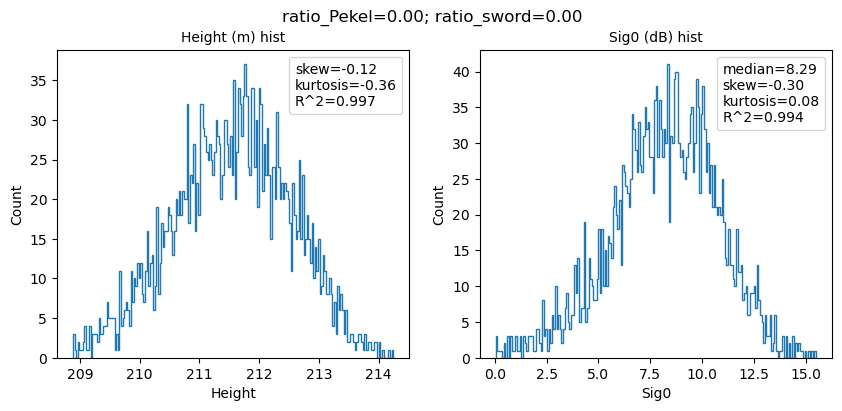

2026-02-12 08:24:32,780 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:32,781 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.811723709106445, -0.7758533954620361, -0.2322148084640503, -0.5364985466003418, 0.04578256607055664, 0.8883130125776713, 0.9959353798336745


Body type: LAND

Processing Label 83 / 104


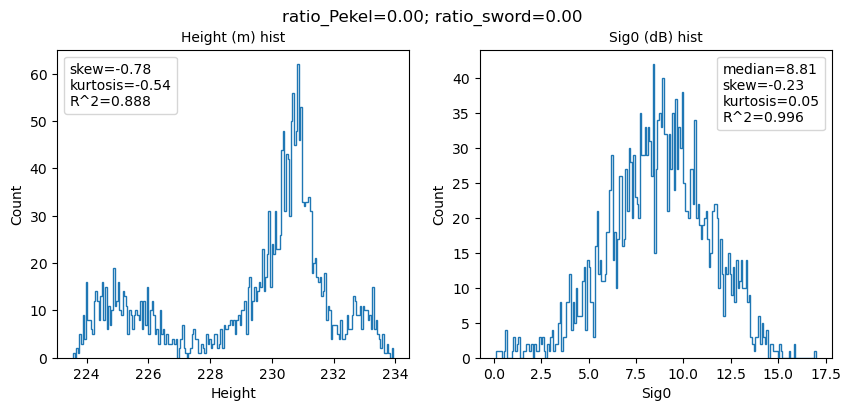

2026-02-12 08:24:33,084 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:33,084 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.600983619689941, 0.7546760439872742, -0.1068621575832367, 0.16629791259765625, 0.09460306167602539, 0.9549757150692758, 0.9976725244019542


Body type: LAND

Processing Label 84 / 104


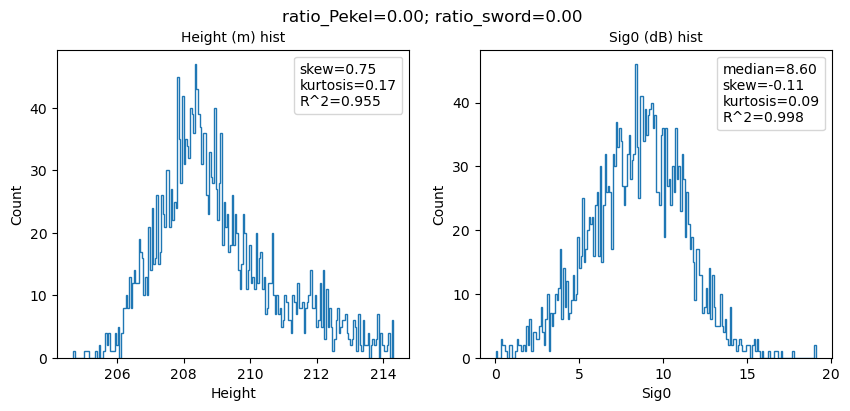

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:33,360 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:33,361 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.749502182006836, -0.07025054842233658, -0.13405168056488037, -0.8178181648254395, -0.04586148262023926, 0.9814044800679337, 0.9970216324975166


Body type: LAND

Processing Label 85 / 104


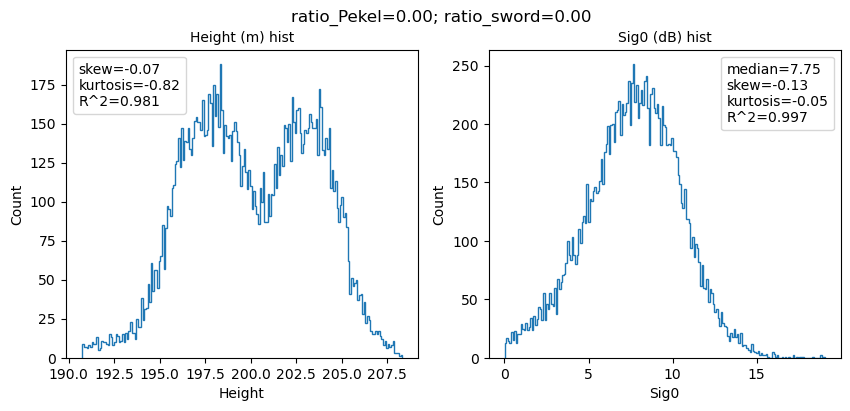

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:33,643 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:33,643 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.133892059326172, 0.8412092924118042, -0.20199896395206451, 0.5100574493408203, -0.14249491691589355, 0.9485042410870385, 0.9958418700013204


Body type: LAND

Processing Label 86 / 104


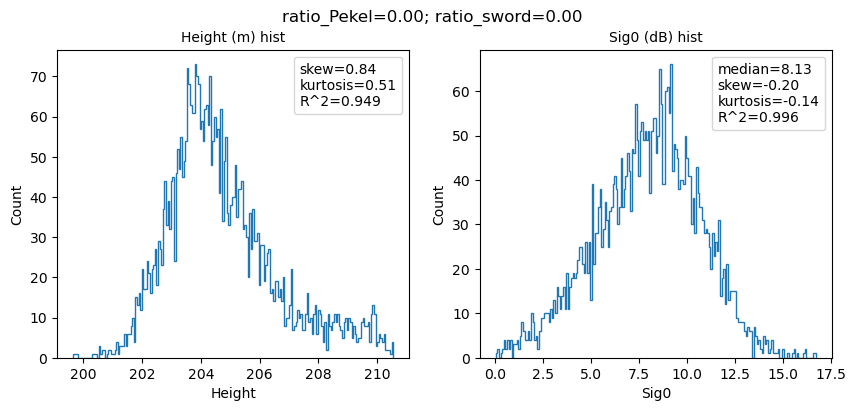

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:33,947 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:33,947 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.217641830444336, -0.17659562826156616, -0.07909774780273438, -1.1623581647872925, 0.24256157875061035, 0.9503440427248583, 0.996313728408231


Body type: LAND

Processing Label 87 / 104


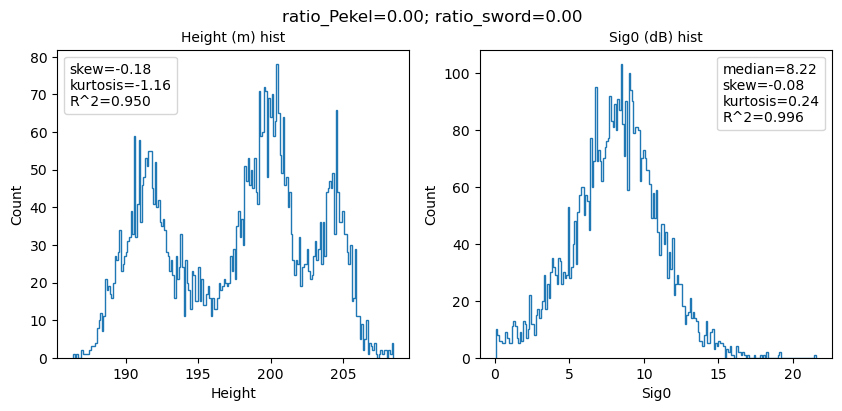

2026-02-12 08:24:34,237 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:34,237 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.192134857177734, -0.0633092150092125, -0.1887027621269226, -0.5354907512664795, -0.011518716812133789, 0.9944982348084059, 0.9974274289420784


Body type: LAND

Processing Label 88 / 104


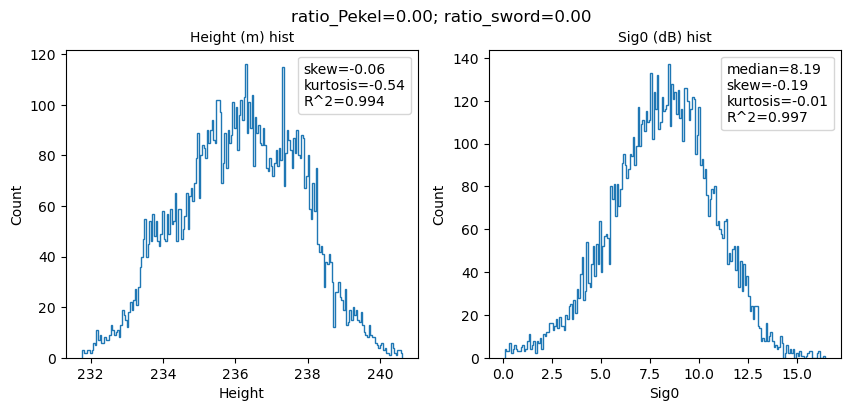

2026-02-12 08:24:34,545 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:34,546 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.778257369995117, 0.15020382404327393, -0.27130770683288574, -0.31559228897094727, 0.021615982055664062, 0.9950851249034262, 0.9951649545911024


Body type: LAND

Processing Label 89 / 104


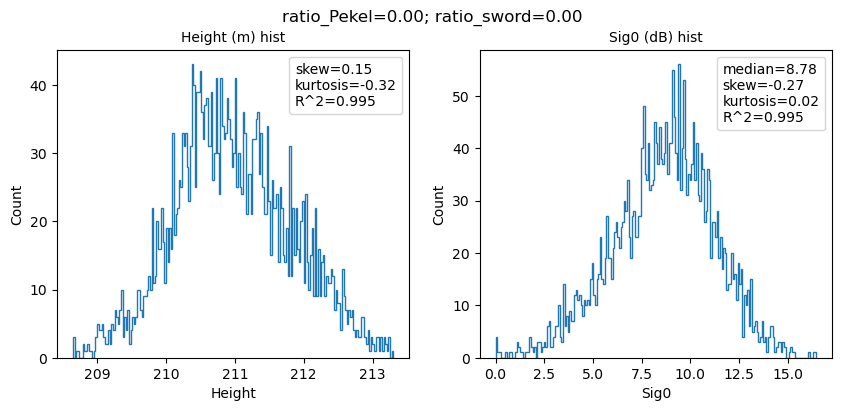

2026-02-12 08:24:34,832 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:34,833 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.04171085357666, 0.21097375452518463, -0.27603545784950256, -0.0006334781646728516, 0.29532694816589355, 0.9914114484354996, 0.9935588664330166


Body type: LAND

Processing Label 90 / 104


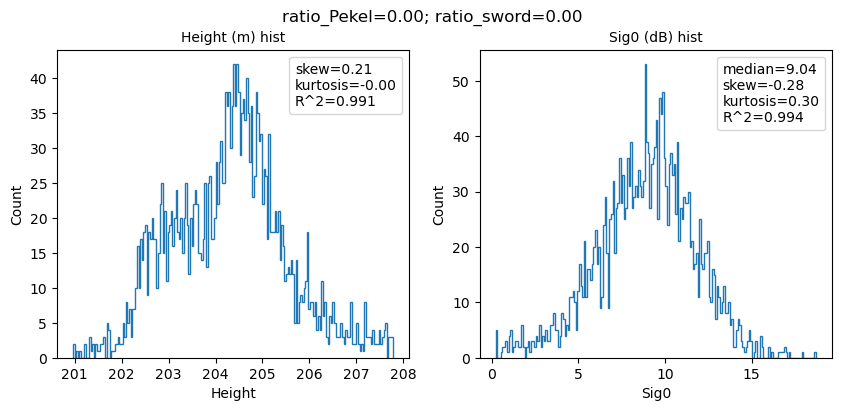

2026-02-12 08:24:35,139 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:35,140 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.242053031921387, 0.11340082436800003, -0.23614071309566498, -0.6845026016235352, -0.028941869735717773, 0.9895784651993572, 0.9961939732857295


Body type: LAND

Processing Label 91 / 104


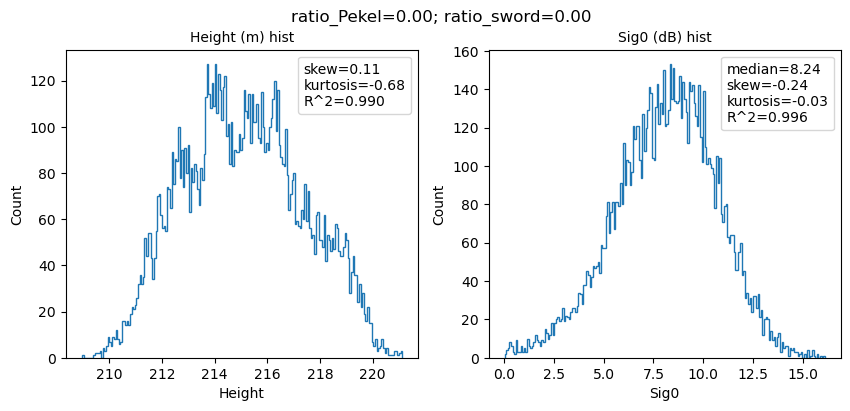

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:35,432 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:35,435 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.514453887939453, 0.5750721096992493, -0.20804035663604736, -0.13758516311645508, 0.08336329460144043, 0.9714959608524742, 0.9953404735144923


Body type: LAND

Processing Label 92 / 104


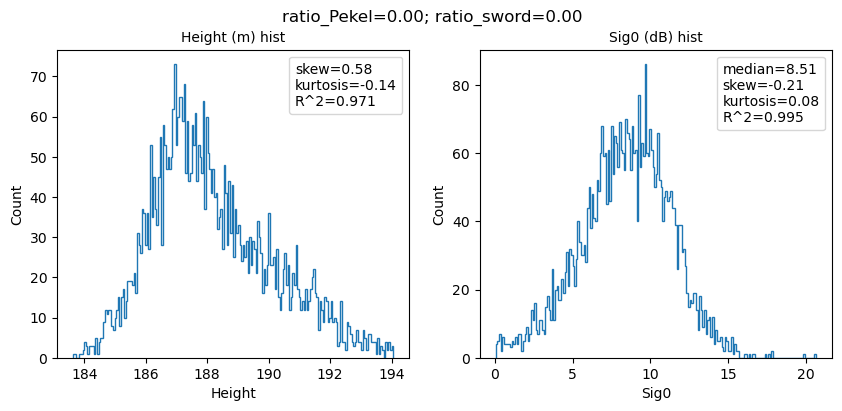

2026-02-12 08:24:35,796 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:35,797 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.549201965332031, 0.3071853518486023, -0.16826073825359344, -1.1643790006637573, -0.06448674201965332, 0.9420717832305637, 0.9978099075748093


Body type: LAND

Processing Label 93 / 104


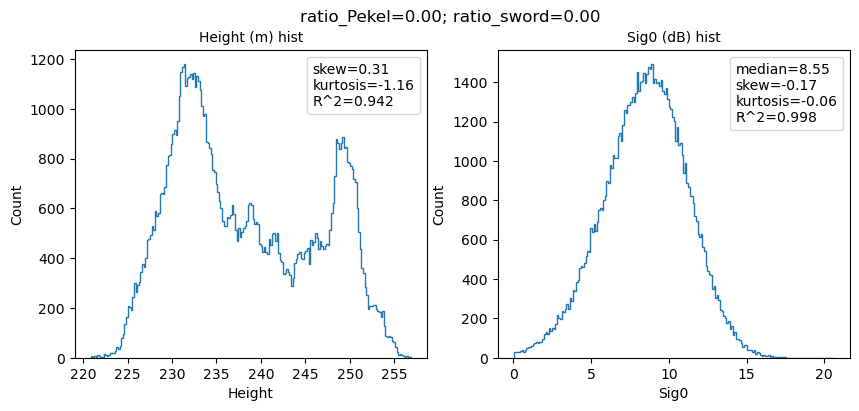

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:36,074 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:36,074 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.283280372619629, 0.8437029123306274, -0.24728995561599731, 1.3748531341552734, -0.07251334190368652, 0.9588556084554984, 0.9951383642773562


Body type: LAND

Processing Label 94 / 104


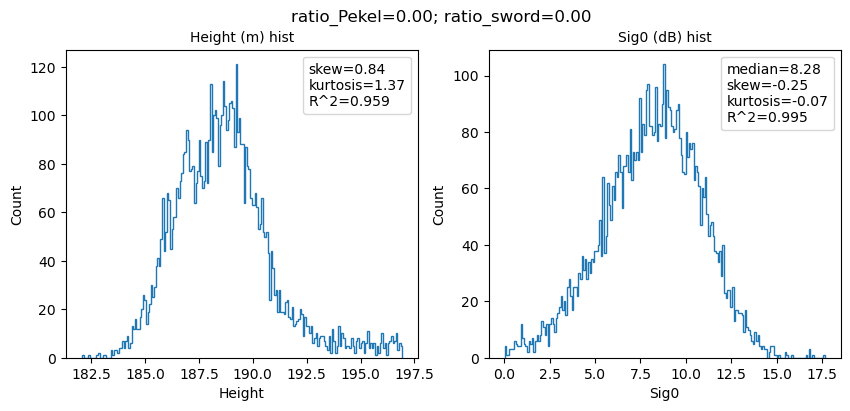

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:36,350 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:36,350 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.815438270568848, 0.7512151598930359, -0.25862592458724976, 0.574016809463501, -0.09673428535461426, 0.9632603829074013, 0.9938495256702012


Body type: LAND

Processing Label 95 / 104


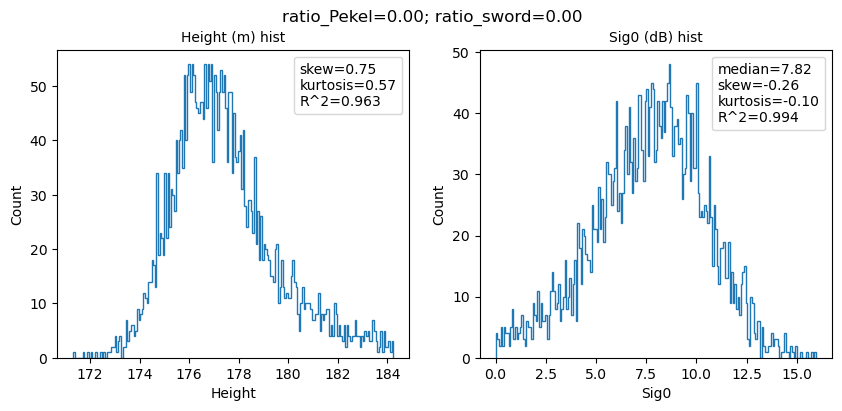

2026-02-12 08:24:36,642 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:36,643 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.158951759338379, -0.3498176038265228, -0.1994432657957077, -0.892606258392334, -0.06719684600830078, 0.9479019620201302, 0.9968427120214179


Body type: LAND

Processing Label 96 / 104


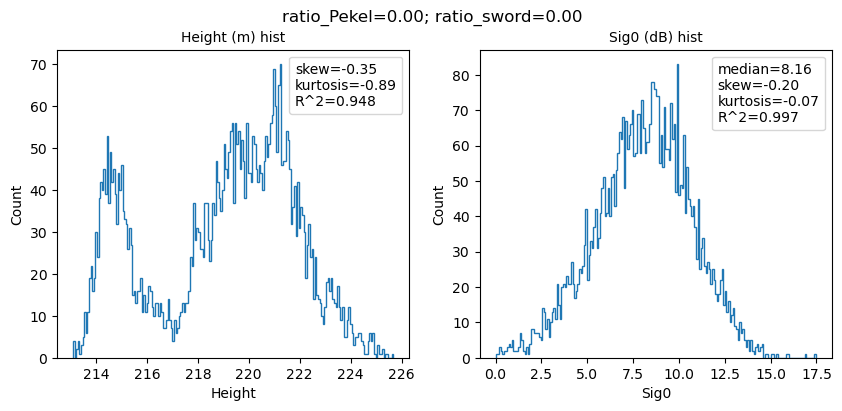

2026-02-12 08:24:36,934 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:36,934 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.041072845458984, 0.4485720694065094, -0.3017580509185791, -0.9257380962371826, -0.03796696662902832, 0.9377920321553355, 0.9932702791552189


Body type: LAND

Processing Label 97 / 104


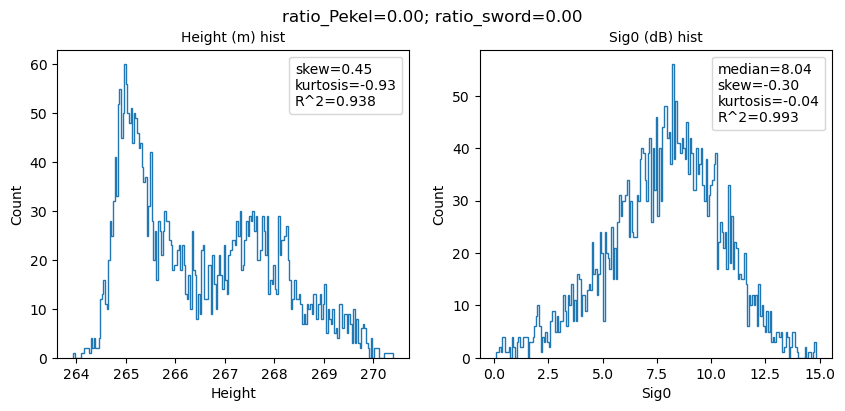

2026-02-12 08:24:37,223 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:37,223 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.787704467773438, 0.24548190832138062, -0.176508828997612, -0.9205970764160156, -0.030169248580932617, 0.9668684897742704, 0.9977826197789358


Body type: LAND

Processing Label 98 / 104


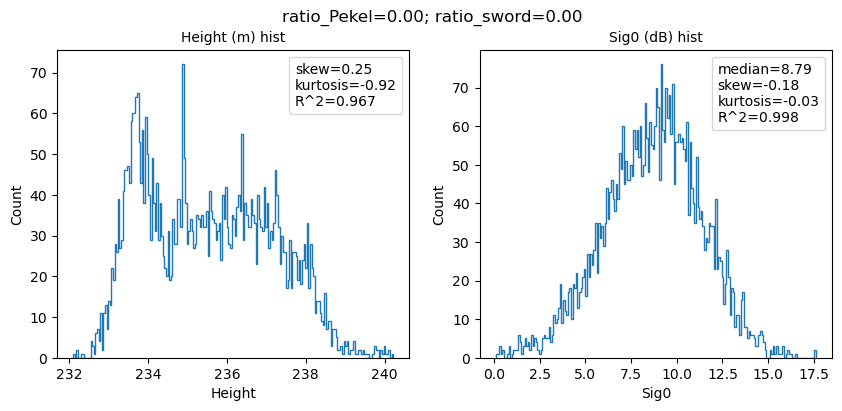

2026-02-12 08:24:37,510 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:37,511 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.297391891479492, -0.2968461215496063, -0.062187083065509796, -0.48803114891052246, -0.10379910469055176, 0.9866901186277712, 0.9991342141041286


Body type: LAND

Processing Label 99 / 104


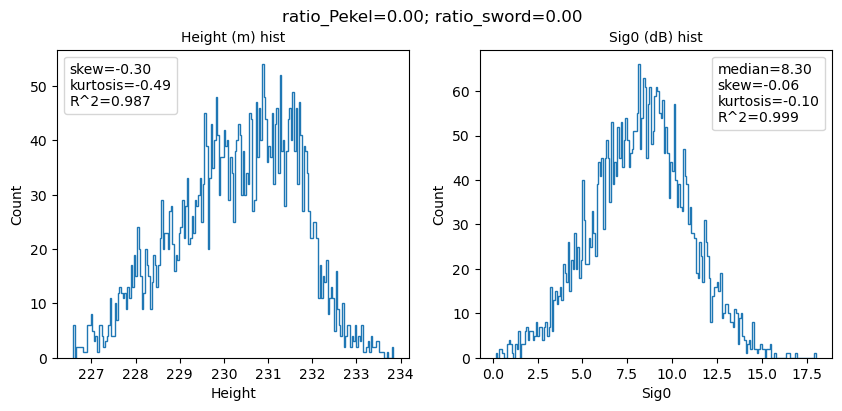

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:37,816 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:37,817 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.322840690612793, -0.3830359876155853, -0.1497630625963211, -0.6191396713256836, 0.04548478126525879, 0.972484505071194, 0.9979016208011974


Body type: LAND

Processing Label 100 / 104


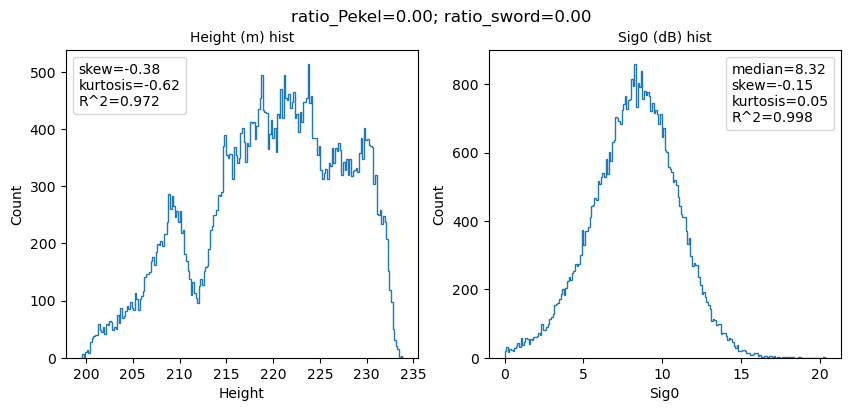

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:38,096 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:38,097 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.772956848144531, 0.7007043361663818, -0.10668401420116425, -0.00731348991394043, 0.11381697654724121, 0.9575394894474325, 0.9983829450668167


Body type: LAND

Processing Label 101 / 104


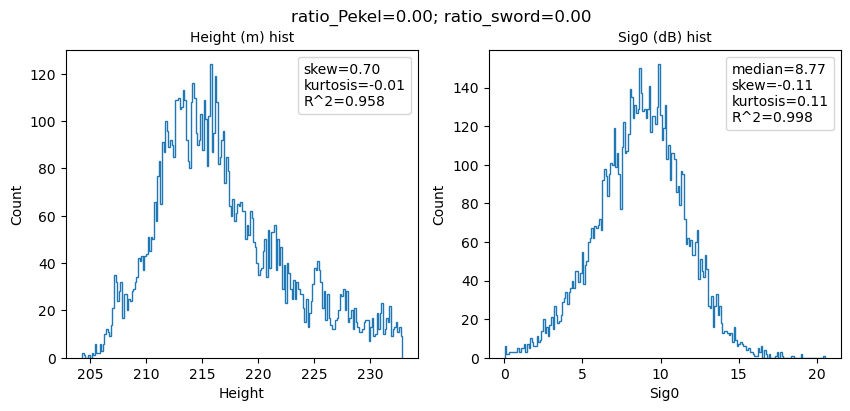

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:38,369 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:38,369 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.366090774536133, 0.373734712600708, -0.26538965106010437, -0.2874298095703125, 0.018404722213745117, 0.9837762515440918, 0.9945774997244976


Body type: LAND

Processing Label 102 / 104


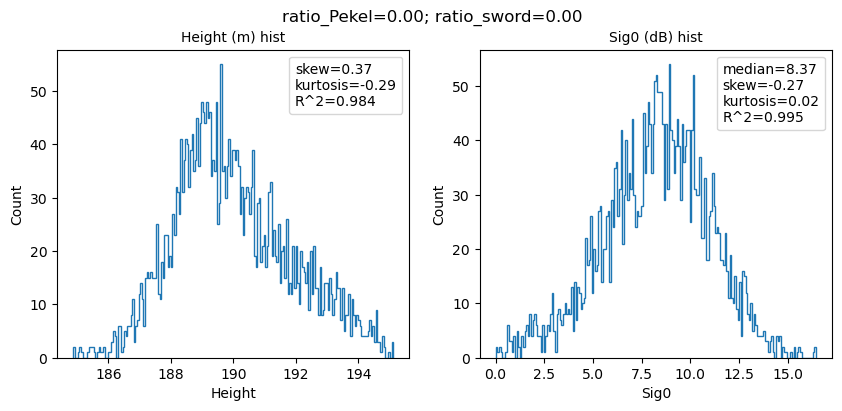

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 08:24:38,689 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:38,689 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.46027946472168, -0.17164787650108337, -0.11009800434112549, -1.2518666982650757, 0.10571599006652832, 0.9449370410640101, 0.9980239857045878


Body type: LAND

Processing Label 103 / 104


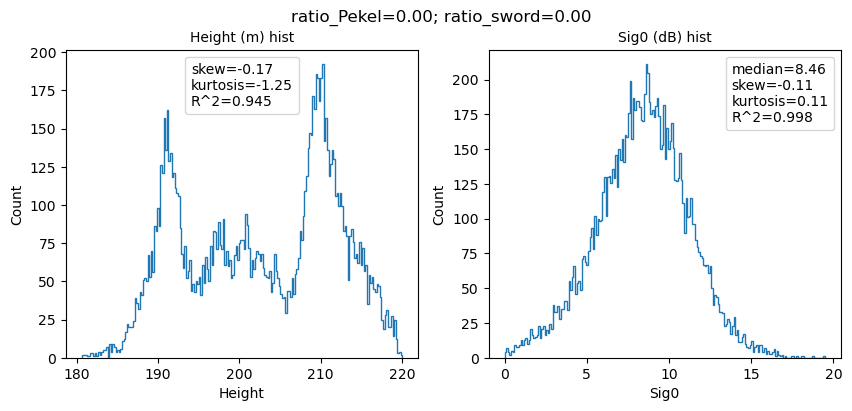

2026-02-12 08:24:38,993 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 08:24:38,993 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.051773071289062, 0.1472776085138321, -0.23987670242786407, -0.989905595779419, -0.030718088150024414, 0.9699411788253332, 0.9957000526422078


Body type: LAND

Processing Label 104 / 104


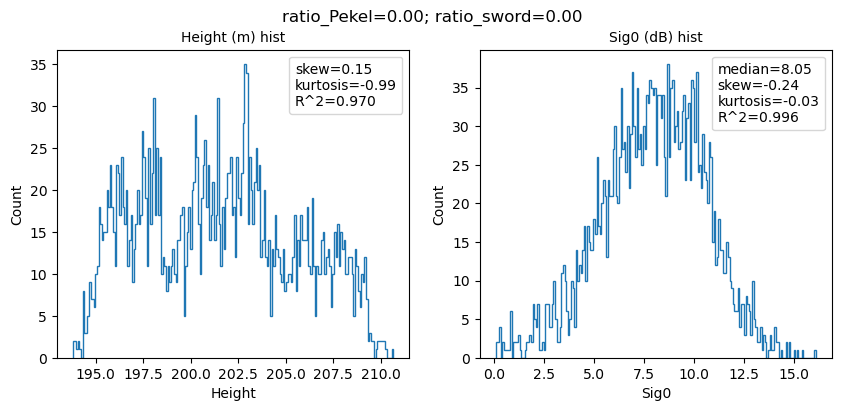

Body type: LAND


2026-02-12 12:14:56,808 [INFO] Filtering using flags
2026-02-12 12:20:55,759 [INFO] PIXC: /work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Haditha/input/pixc/SWOT_L2_HR_PIXC_041_471_215R_20251118T151248_20251118T151259_PID0_01.nc


Processing PIXC 2/2


2026-02-12 12:22:13,486 [INFO] Extract water points
2026-02-12 12:22:13,721 [INFO] Remove pixels too close to near_range
2026-02-12 12:22:18,882 [INFO] Extract contiguous water points by keeping only water bodies whose area is greater than threshold


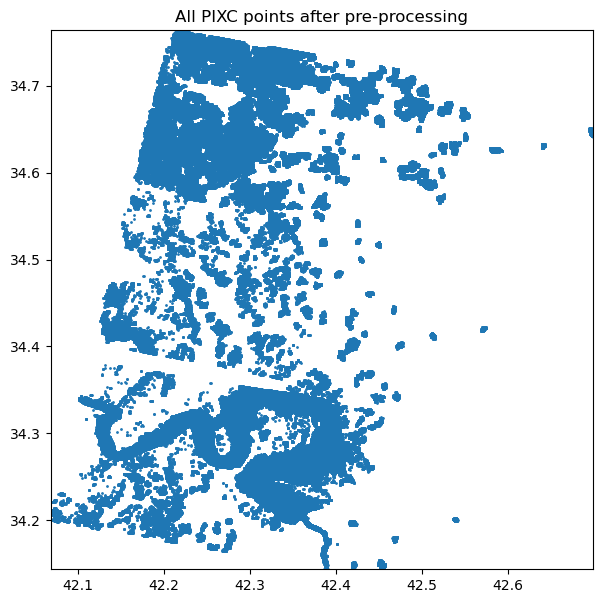

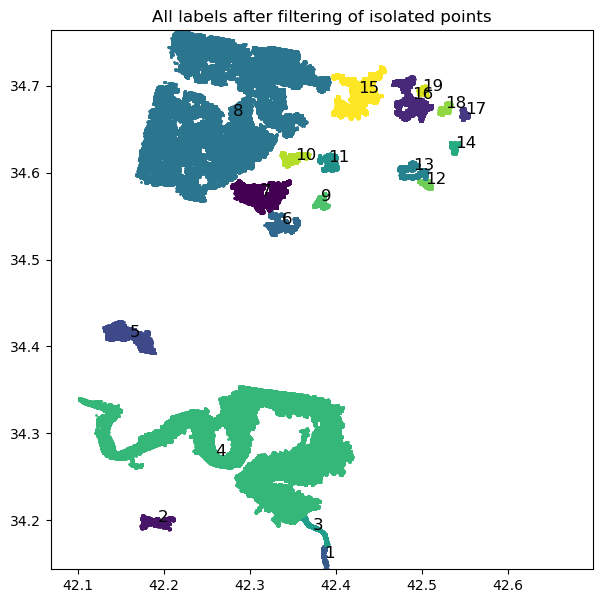

2026-02-12 12:22:35,485 [INFO] Ratio pekel, ratio sword: 0.9620141342756183, 1.0
2026-02-12 12:22:35,486 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):9.81725788116455, -0.39008447527885437, 0.22730061411857605, -0.047321319580078125, -0.7151758670806885, 0.9803042466172853, 0.9848203772245191


Number of water bodies found : 19

Processing Label 1 / 19


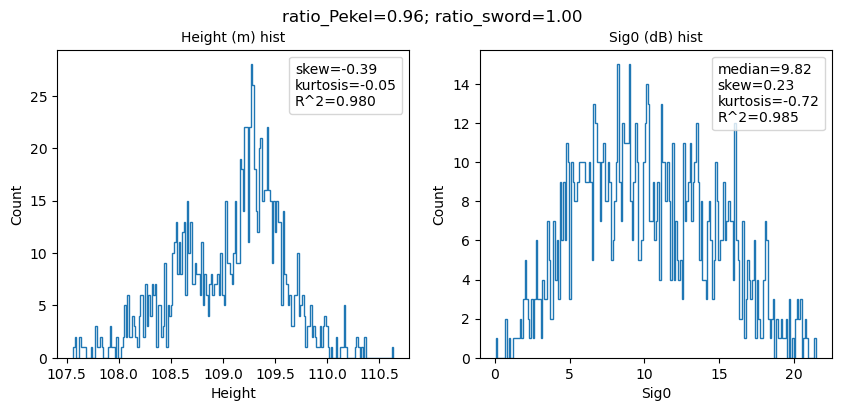

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.390109795824841 34.148975800475135
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 12:22:35,755 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:22:35,755 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.382880210876465, 0.18190540373325348, 0.3352898359298706, -0.16042137145996094, 0.4286689758300781, 0.9905138371613037, 0.9927722584504786


Body type: WATER
Bathtub ring method is applied

Processing Label 2 / 19


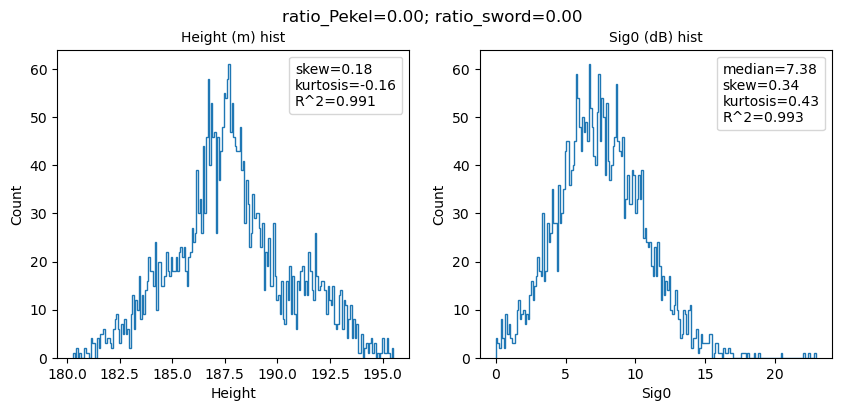

2026-02-12 12:22:36,003 [INFO] Ratio pekel, ratio sword: 0.9297415362213324, 1.0
2026-02-12 12:22:36,004 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):10.107152938842773, 0.22791041433811188, 0.112335704267025, 0.6360495090484619, -0.9424514770507812, 0.9918819943680985, 0.9787588390633264


Body type: LAND

Processing Label 3 / 19


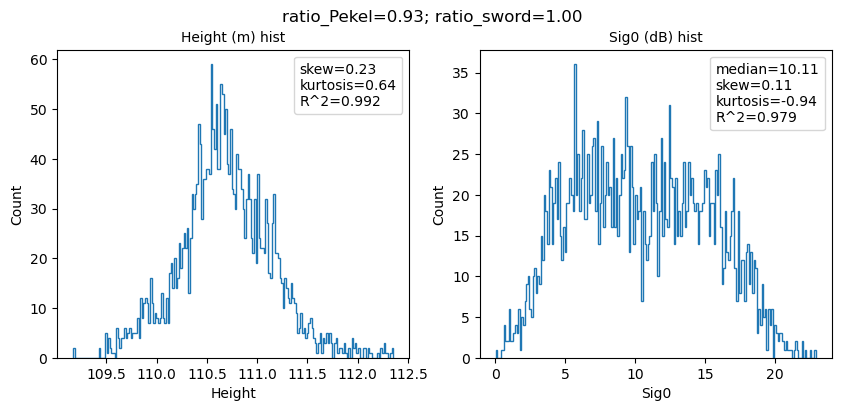

Body type: WATER
Bathtub ring method is applied

Processing Label 4 / 19


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.389828894931654 34.173632523699652
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 12:22:36,798 [INFO] Ratio pekel, ratio sword: 0.9650013710289127, 0.9782273486437497
2026-02-12 12:22:36,798 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.398459434509277, -0.8064327239990234, -0.4251147210597992, 0.10318851470947266, 0.9495394229888916, 0.9415591013249068, 0.986652050948853


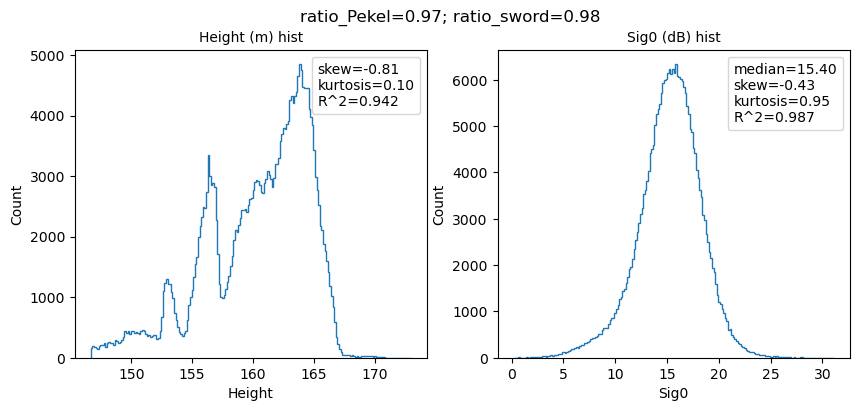

Body type: WATER
Bathtub ring method is applied


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point 42.412258964371162 34.287152621494187
  return _ogr.Geometry_IsValid(self, *args)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 12:23:00,443 [INFO] Ratio pekel, ratio sword: 0.15710694698354663, 0.0
2026-02-12 12:23:00,444 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):7.269101142883301, 0.3737128674983978, 0.05815591663122177, -0.6177453994750977, -0.16019463539123535, 0.976320164010886, 0.998640710237831



Processing Label 5 / 19


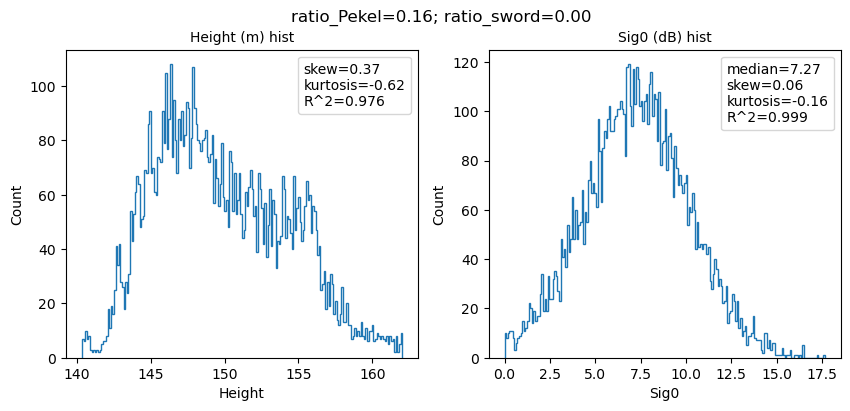

2026-02-12 12:23:00,689 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:00,689 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):5.965249538421631, 0.08952602744102478, 0.2281966507434845, -0.6896116733551025, -0.004164695739746094, 0.9842690454893582, 0.9950512636405996


Body type: LAND

Processing Label 6 / 19


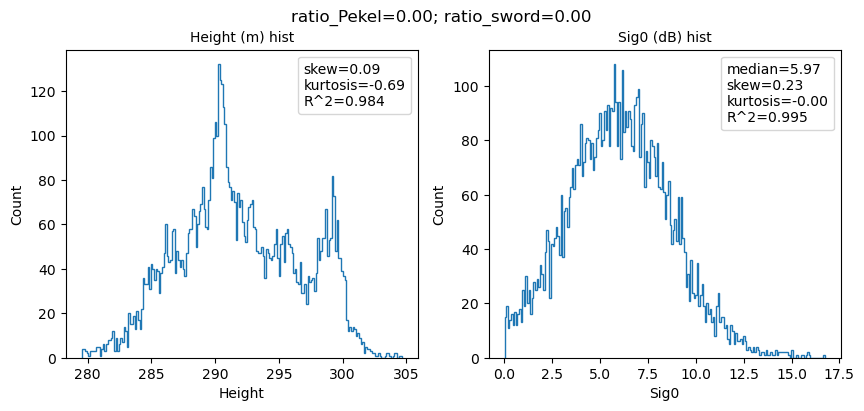

2026-02-12 12:23:00,955 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:00,955 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):5.747982025146484, -0.6102733612060547, 0.10359084606170654, -0.4939730167388916, -0.34351658821105957, 0.9507197257798415, 0.9956321935704753


Body type: LAND

Processing Label 7 / 19


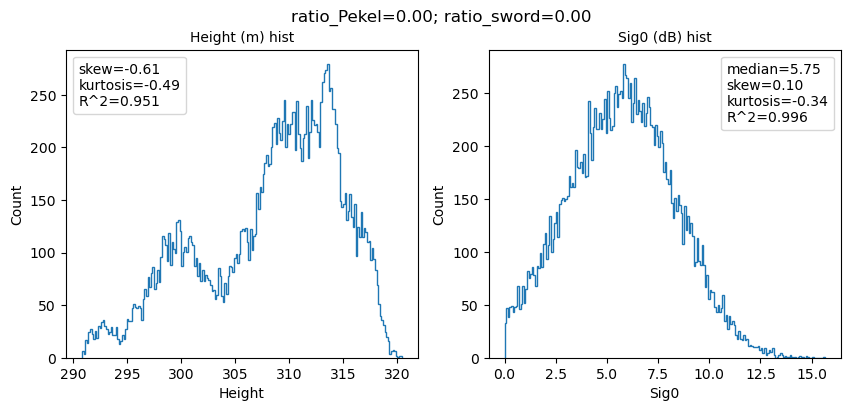

Body type: LAND

Processing Label 8 / 19


/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 12:23:01,371 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:01,371 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):6.340714454650879, 0.28257817029953003, 0.14761149883270264, -0.8429868221282959, -0.1563863754272461, 0.9696368862364368, 0.9966088909474096


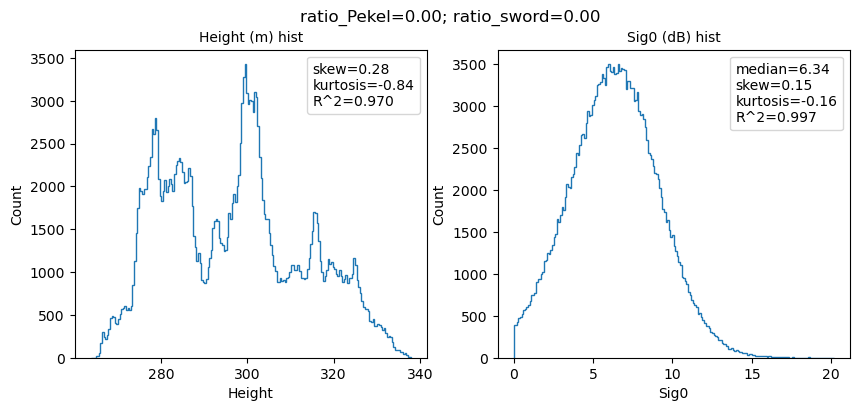

2026-02-12 12:23:01,617 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:01,617 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):5.426706314086914, -0.24298496544361115, 0.07431180775165558, -0.7857742309570312, -0.4343264102935791, 0.9715139122882009, 0.9955952305888398


Body type: LAND

Processing Label 9 / 19


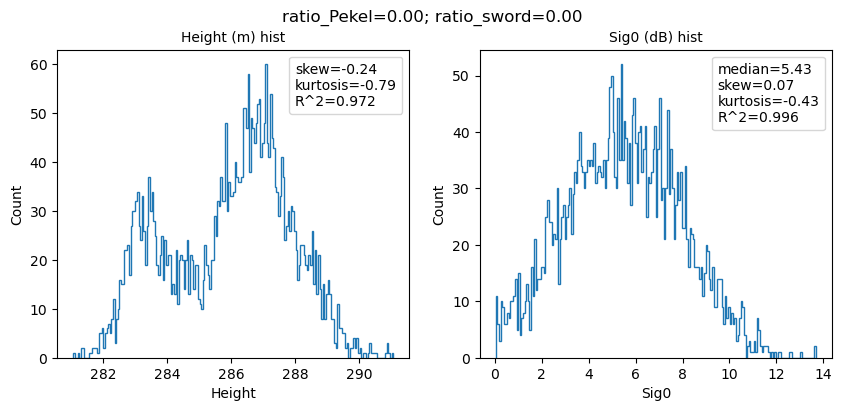

2026-02-12 12:23:01,871 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:01,871 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):5.560095310211182, -0.4883222281932831, 0.009733777493238449, -0.9002029895782471, -0.3625762462615967, 0.9391050518519971, 0.9967264047033624


Body type: LAND

Processing Label 10 / 19


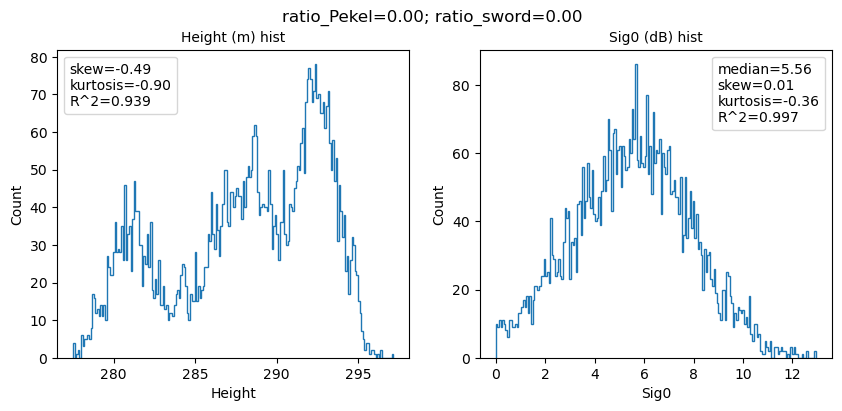

2026-02-12 12:23:02,116 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:02,117 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):5.515127658843994, 0.3822363615036011, 0.07776183634996414, -0.6921961307525635, -0.2403862476348877, 0.9706171358592186, 0.995662597021125


Body type: LAND

Processing Label 11 / 19


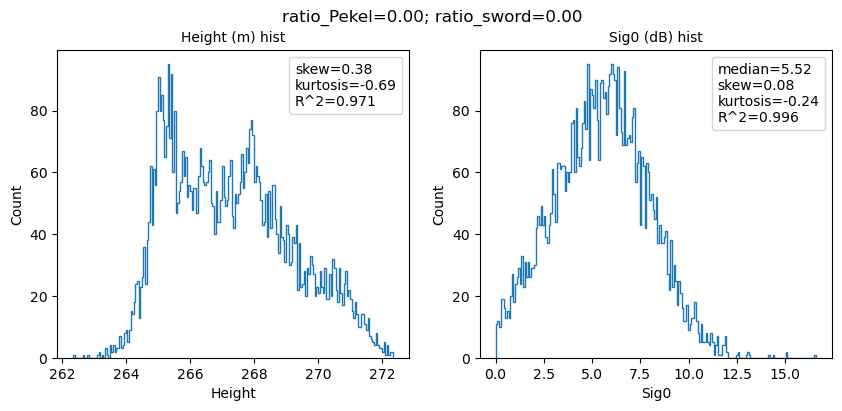

2026-02-12 12:23:02,355 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:02,356 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):5.694316864013672, 0.9011334776878357, 0.06411592662334442, 0.6946172714233398, -0.2368772029876709, 0.9441226061177687, 0.9959837561812513


Body type: LAND

Processing Label 12 / 19


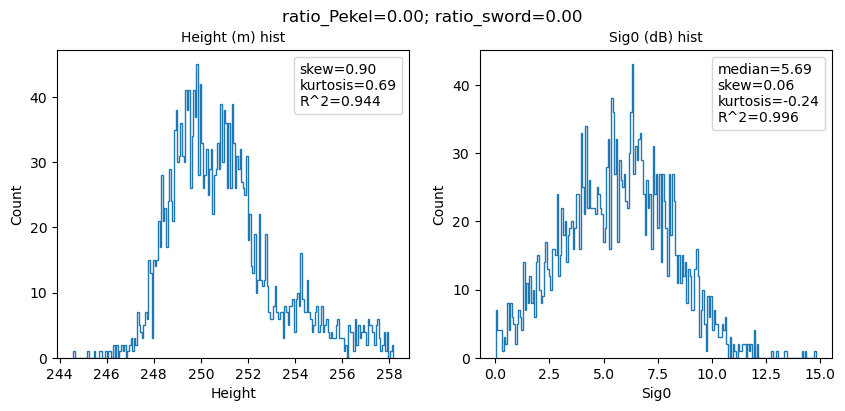

2026-02-12 12:23:02,607 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:02,607 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):5.57720422744751, 0.31285011768341064, -0.007446189410984516, -0.5814342498779297, -0.3229525089263916, 0.9817594425999239, 0.9967517271807402


Body type: LAND

Processing Label 13 / 19


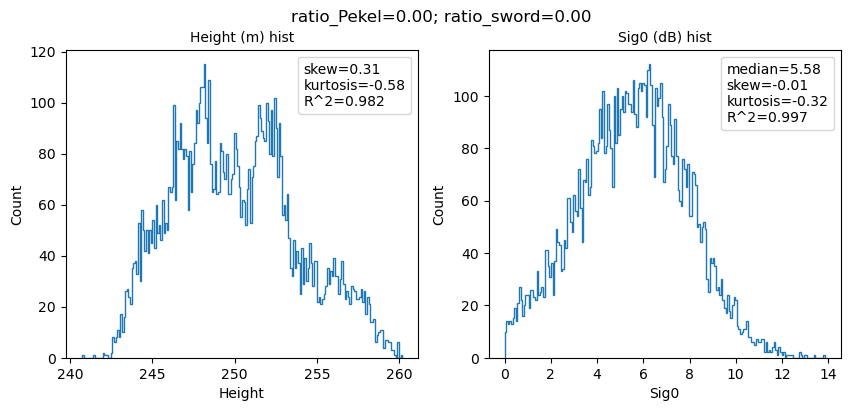

2026-02-12 12:23:02,854 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:02,855 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):5.402068138122559, 0.5940975546836853, 0.0024690323043614626, -0.3061983585357666, -0.10054254531860352, 0.9519700882345925, 0.9950953101985033


Body type: LAND

Processing Label 14 / 19


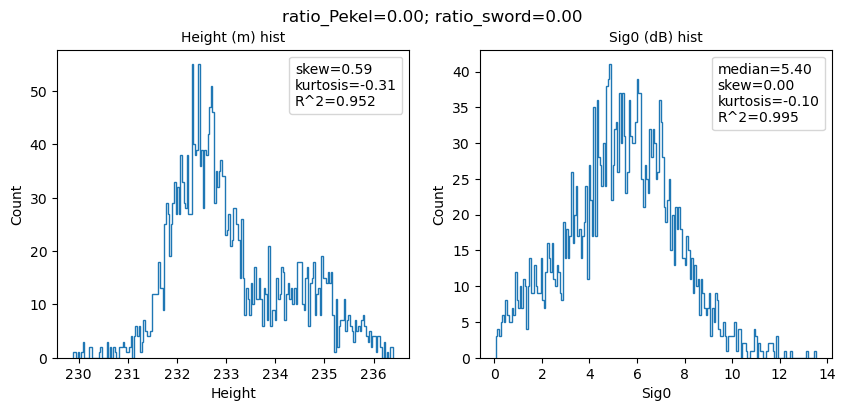

2026-02-12 12:23:03,124 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:03,125 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):5.772889137268066, -0.5052589178085327, 0.13514083623886108, 0.27621936798095703, -0.07434916496276855, 0.9708976293391167, 0.9966809684658126


Body type: LAND

Processing Label 15 / 19


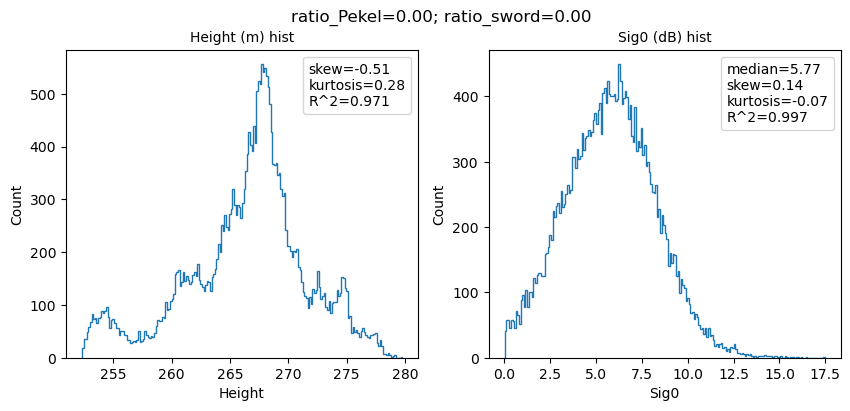

2026-02-12 12:23:03,381 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:03,382 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):5.410857200622559, 0.27129119634628296, 0.019076120108366013, -0.5145134925842285, -0.39092040061950684, 0.9841542794953037, 0.9963598815819974


Body type: LAND

Processing Label 16 / 19


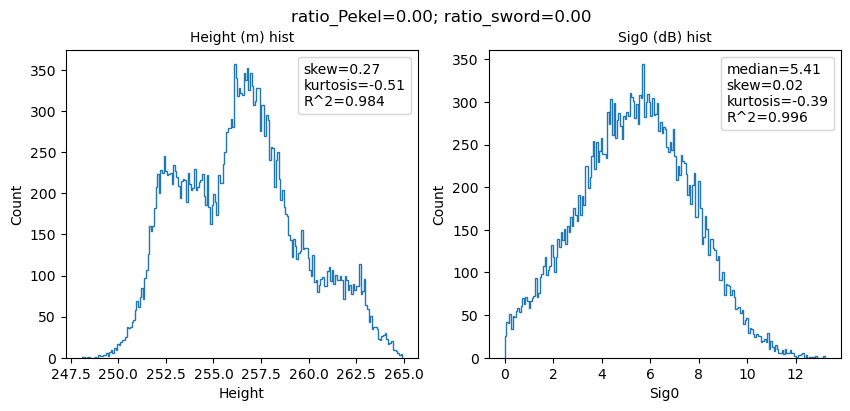

2026-02-12 12:23:03,644 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:03,644 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):5.40162992477417, 0.31556808948516846, -0.027427200227975845, -0.13218212127685547, -0.46193480491638184, 0.99102258551349, 0.9952531665706007


Body type: LAND

Processing Label 17 / 19


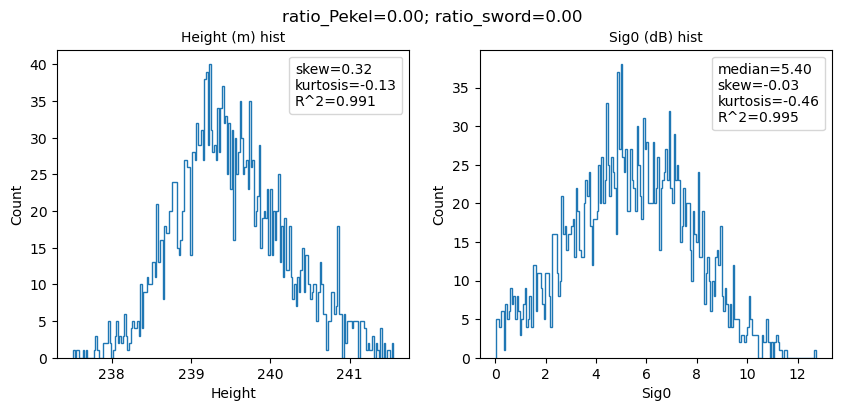

2026-02-12 12:23:03,894 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:03,894 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):5.272688388824463, 0.2651759088039398, 0.011939573101699352, -0.5237407684326172, -0.48127126693725586, 0.9830671643449542, 0.9942092303595044


Body type: LAND

Processing Label 18 / 19


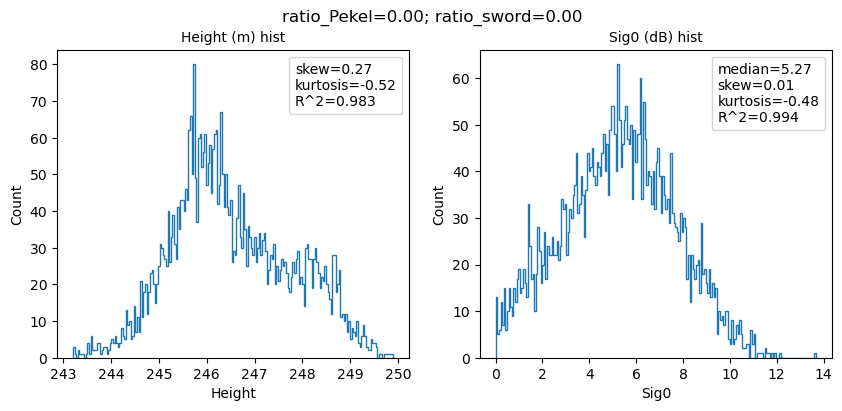

2026-02-12 12:23:04,157 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 12:23:04,157 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):5.470249176025391, -0.07060155272483826, -0.05433604493737221, -0.4541056156158447, -0.4494593143463135, 0.996162016981655, 0.9954036034400922


Body type: LAND

Processing Label 19 / 19


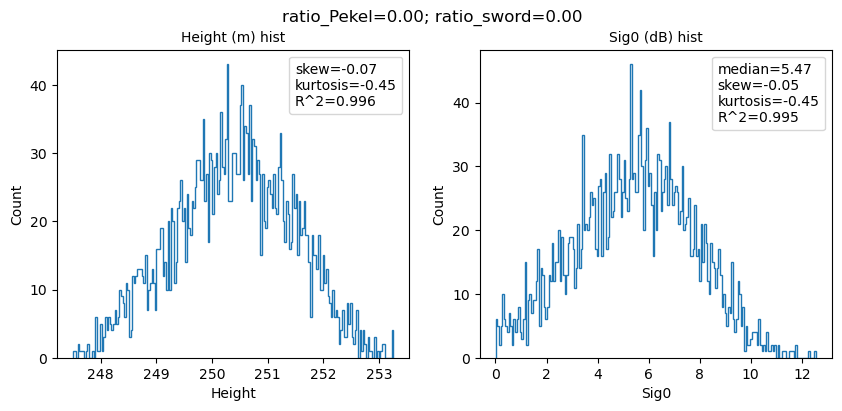

Body type: LAND


2026-02-12 12:37:52,823 [INFO] Filtering using flags


In [12]:
# Load class FloodPlain, necessary for access to bathtub ring subroutine
fpdem = Floodplain(None)

# Initialize main FPDEM dataframe
fpdem_land = pd.DataFrame()

# Loop over all PIXC files
for ip, pixc_file in enumerate(inputpixcfiles):
    
    print(f"Processing PIXC {ip+1}/{len(inputpixcfiles)}")
    
    cycle = os.path.basename(pixc_file)[16:19]
    if os.path.isdir(os.path.join(output_dir, f'cycle{cycle}')) is False:
        os.mkdir(os.path.join(output_dir, f'cycle{cycle}'))
    
    # Get PIXCVec file (currently not used at all -- commented lines in floodplain/io/nc.py)
    vec_file = inputvecfiles[ip]
    # Load PixcReader class, and read pixc file
    pixc_reader = PixcReader(polygon_mask, pixc_file, vec_file)

    # Pre-processing of PIXC: extract water points (classification > 2), exclude near-range points, 
    # and clusters whose area is smaller than the given threshold
    water, min_range_ind_to_remove = pre_processing_pixc(pixc_reader, 
                                                         cross_track_min, threshold, 
                                                         sig0_qual)

    # Select only points of classification 3, 4 and some 5 if in Pekel mask 95%-100%,
    # remove all isolated points if some remains in pre-processing,
    # and define clusters / label the detected water bodies
    label_tab, count, classification_tab, \
               height_tab, sig0_tab, \
               azimuth_index_tab, range_index_tab, \
               latitude_tab, \
               longitude_tab = compute_label_and_remove_small_object(water,
                                                                     pixc_reader.range_size, pixc_reader.azimuth_size,
                                                                     pekel_X_100_poly,
                                                                     body_min_size, body_connectivity, 
                                                                     plot=plot, outpath=output_dir, cycle=cycle)
    print(f"Number of water bodies found : {count}")
    
    # Initialize selected PIXC FPDEM dataframe
    fpdem_land_pixc = pd.DataFrame()
    
    # Loop over all detected water bodies in the PIXC
    for label in range(1, count+1):
        
        print(f"\nProcessing Label {label} / {count}")
        
        # Return water_extract (-> GeoDataFrame), only points corresponding to the processed label
        water_extract = compute_subwater_extract_from_label(water, label_tab, 
                                                            azimuth_index_tab, range_index_tab, label)
        if len(water_extract) == 0:
            continue
        
        if approach == 'mixed':
            # TODO: Delete once the new PIXC products have corrected dark_water elevation
            #       At the moment the dark water height is too bad to be used in categorization of bodies
            # This geodataframe is used to parametrize the water body and select its type (land, water or land_water)
            water_extractCateg = water_extract[(water_extract.classification == 3) | 
                                               (water_extract.classification == 4)]
            if len(water_extractCateg) == 0:
                continue
                
            # Plot height and sig0
            if plot == 'yes':
                height_to_plot = np.where(label_tab == label, height_tab, 0)[l0:l1, c0:c1]
                height_to_plot[np.where(height_to_plot == 0)] = np.nan
                sig_to_plot = 10*np.log10(np.where(label_tab == label, sig0_tab, 0)[l0:l1, c0:c1])
                sig_to_plot[np.where(sig_to_plot == 0)] = np.nan
                fig, (ax, ax2) = plt.subplots(nrows=1, ncols=2, layout='constrained')
                ax.set_title("Height(m) for cycle: " + cycle + "-- label: " + str(label))
                im = ax.imshow(height_to_plot)
                fig.colorbar(im, shrink=0.5, ax=ax)
                ax2.set_title("Sig0 (dB)")
                im2 = ax2.imshow(sig_to_plot)
                fig.colorbar(im2, shrink=0.5, ax=ax2)
                plt.show()

            # Find the category the water body belongs to
            water_body_type, categ_params = find_body_category(water_extractCateg, pekel_0_100_poly, poly_sword, plot=plot)
            print(f"Body type: {water_body_type}")

            # Apply different method depending on body category
            # LAND => direct extraction
            # WATER => Bathtub ring method
            # WATER_LAND => clustering method
            #         LAND => direct extraction
            #         WATER => Bathtub ring method
            if water_body_type == "LAND":
                fpdem_land_pixc = pd.concat([fpdem_land_pixc, water_extract[['longitude', 'latitude',
                                                                               'height', 'sig0', 'classification',
                                                                               'azimuth_index', 'range_index']]])
                
            elif water_body_type == "WATER":
                print('Bathtub ring method is applied')
                res_bathtub = fpdem.compute_bathtub_method(water_extract)
                fpdem_land_pixc = pd.concat([fpdem_land_pixc, res_bathtub])
                
            elif water_body_type == "WATER_LAND":
                print('Clustering method is applied')
                
                # Over one cycle (selected or first one of the list) extract height 
                # to obtain range and azimuth extrema
                l0, l1, c0, c1 = get_range_azimuth_extrema(water_extract, 
                                                           pixc_reader.range_size, pixc_reader.azimuth_size)
            
                # Create 4D matrix with all variables used for clustering (h, sig0, lon, lat)
                sub_image = prepare_clustering_image(height_tab, sig0_tab, latitude_tab, longitude_tab,
                                                     label_tab, label, l0, l1, c0, c1)
                
                # Load class Clustering_Method and initialize its variables
                clust = Clustering_Method(sub_image, label, output_dir, cycle, plot=plot)
                
                # Filter outliers and normalize height and sig0
                clust.normalize_data(filter_method=clustering_outlier_filter_method) # isolation_forest/zscore
                
                if clustering_method == 'birch' or clustering_method == 'kmeans':
                    clust.clustering_method(method=clustering_method)
                elif clustering_method == 'hdbscan_tsne':
                    clust.clustering_tsne_hdbscan()
                else:
                    clust.clustering_umap_hdbscan()
                
                # Categorize the different clusters into LAND or WATER
                clust.get_water_soil_labels(water_extract, pekel_0_100_poly, poly_sword)

                # For WATER cluster
                if clust.sub_img_labeled_water is not None:
                    geom = gpd.points_from_xy(clust.sub_img_labeled_water[:, 2], 
                                              clust.sub_img_labeled_water[:, 3])
                    water_extract_w = water_extract[water_extract.geometry.isin(geom)]
                    
                    if clustering_contour == 'bathtub':
                        res_bathtub = fpdem.compute_bathtub_method(water_extract_w)
                    elif clustering_contour == 'concavehull':
                        concave_hull = gpd.GeoSeries([MultiPoint(water_extract_w['geometry'].values)]).concave_hull(ratio=0.05,
                                                                                                                    allow_holes=True)
                        list_coords = shapely.get_coordinates(concave_hull.exterior).tolist()
                        res_bathtub = gpd.GeoDataFrame(geometry=[Point(i) for i in list_coords], crs=4326)
                        res_bathtub['longitude'] = pd.Series(res_bathtub.geometry.get_coordinates().x.values)
                        res_bathtub['latitude'] = pd.Series(res_bathtub.geometry.get_coordinates().y.values)
                        col_list = ['height', 'sig0', 'azimuth_index', 'range_index', 'classification']
                        res_bathtub[col_list] = res_bathtub.apply(find_attributes, args=(water, 2,), axis=1)
                        res_bathtub = res_bathtub.drop(['geometry'], axis=1)
                        
                    fpdem_land_pixc = pd.concat([fpdem_land_pixc, res_bathtub])
                    
                # For LAND cluster
                if clust.sub_img_labeled_land is not None:
                    geom = [Point(lon, lat) for lon, lat in zip(clust.sub_img_labeled_land[:, 2], 
                                                                clust.sub_img_labeled_land[:, 3])]
                    water_extract_l = water_extract[water_extract.geometry.isin(geom)]
                    fpdem_land_pixc = pd.concat([fpdem_land_pixc, water_extract_l[['longitude', 'latitude',
                                                                                    'height', 'sig0', 'classification',
                                                                                    'azimuth_index', 'range_index']]])

        elif approach == 'bathtub':
            res_bathtub = fpdem.compute_bathtub_method(water_extract)
            fpdem_land_pixc = pd.concat([fpdem_land_pixc, res_bathtub])

            
    # Remove borders points
    range_min = int(np.min(fpdem_land_pixc.range_index))
    range_max = int(np.max(fpdem_land_pixc.range_index))
    fpdem_land_pixc = remove_borders(fpdem_land_pixc.copy(), range_min, range_max-1,
                                     pixc_reader.azimuth_min, pixc_reader.azimuth_max-1,
                                     min_range_ind_to_remove)
    
    # Filter according to user defined lat-lon box
    try:
        fpdem_land_pixc = fpdem_land_pixc.loc[(fpdem_land_pixc['longitude'] > longitude_min) &
                                              (fpdem_land_pixc['longitude'] < longitude_max) &
                                              (fpdem_land_pixc['latitude'] > latitude_min) &
                                              (fpdem_land_pixc['latitude'] < latitude_max)]
    except:
        print('No filtering on latitude and longitude as none seems to be givven as inputs')
    
    # Add quality flags, time and elevation columns
    fpdem_land_pixc[['classification_qual', 'geolocation_qual',
                      'time', 'elevation']] = fpdem_land_pixc.apply(find_attributes, args=(water, 1,), axis=1)
    
    # Flag filtering (more could be added later on)
    fpdem_land_pixc = filter_data_based_on_quality_flag(fpdem_land_pixc, 
                                                        classification_qual, geolocation_qual)

    # Get utm coordinates
    lambdafunc = lambda row: pd.Series([*utm.from_latlon(row['latitude'], row['longitude'])[0:2], row['height']])
    fpdem_land_pixc[['x', 'y', 'z']] = fpdem_land_pixc.apply(lambdafunc, axis=1)
            
    # Merge all PIXC results
    fpdem_land = pd.concat([fpdem_land, fpdem_land_pixc])
        

In [13]:
# Transforming the Dataframe with all results into a GeoDataFrame
geom = gpd.points_from_xy(fpdem_land.longitude, fpdem_land.latitude)
fpdem_land = gpd.GeoDataFrame(fpdem_land, geometry=geom, crs=water.crs)

# Removing/filtering points (from Pekel if selected and isolated points)

1 - Remove all points if within Pekel occurrences >X2% (defined in parameter 'filtering_pekel_end_val' at the beginning of the code)

2 - Remove isolated points using DBSCAN

In [14]:
# Some final filtering on the FPDEM results
res_data = final_filtering_FPDEM_results(fpdem_land, filtering_pekel_end, pekel_X2_100_poly,
                                         distance_to_neighbors, number_of_neighbors, output_dir)

2026-02-12 12:38:49,129 [INFO] Remove isolated points
2026-02-12 12:39:18,962 [INFO]         428 points were removed
/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
2026-02-12 12:40:05,036 [INFO] Created 2,989,662 records
2026-02-12 12:40:05,171 [INFO] The results of DBSCAN labeling were written in file "results_fpdem_labels_dbscan.shp" 


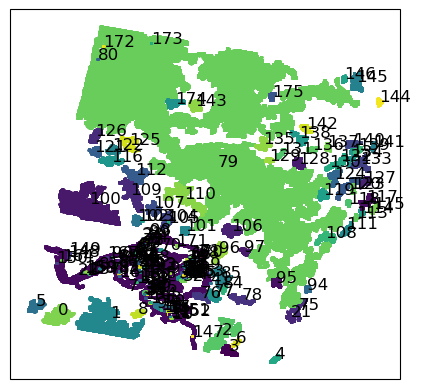

In [15]:
# Plot all clusters on which area extraction/polygonization will be performed
N_cluster = len(np.unique(res_data.lab_dbscan.values))
fig = plt.figure()
ax1 = fig.add_subplot(111, projection=tiler.crs)
cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, N_cluster)]
random.shuffle(colors)
for k, color in enumerate(colors, start=0):
    res_data2 = res_data[res_data.lab_dbscan == k]
    ax1.scatter(res_data2.longitude.values, res_data2.latitude.values, c=np.array([color]), s=1)
    lon_avg = (np.min(res_data2.longitude) + np.max(res_data2.longitude)) / 2
    lat_avg = (np.min(res_data2.latitude) + np.max(res_data2.latitude)) / 2
    ax1.annotate(k, xy=(lon_avg, lat_avg), xycoords='data', color='black', fontsize=12)
plt.show()

# Plotting ungridded FPDEM results

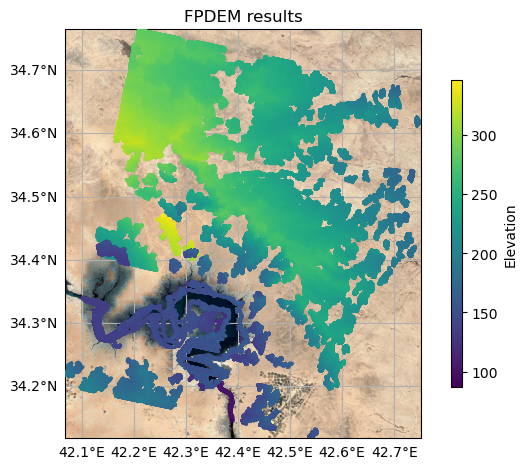

In [16]:
extent = [np.min(res_data.longitude.values), np.max(res_data.longitude.values), 
         np.min(res_data.latitude.values), np.max(res_data.latitude.values)]
hmin = min(res_data.elevation.values)
hmax = max(res_data.elevation.values)

fig = plt.figure(layout='tight')
ax = fig.add_subplot(1, 1, 1, projection=tiler.crs)
ax.set_title(f'FPDEM results')
ax.set_extent(extent, geodetic)
ax.add_image(tiler, 13)
cs = res_data.plot(ax=ax, kind='scatter', x='longitude', y='latitude', c="elevation", 
               zorder=5, transform=wgs84, s=1, vmin=hmin, vmax=hmax, colorbar=False)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=hmin, vmax=hmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.75, aspect=30, label='Elevation')
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

plt.show()

# Write FPDEM ungridded file

In [17]:
fpdem.res_pointcloud = res_data
fpdem.inputpixcfiles = inputpixcfiles
fpdem.inputvecfiles = inputvecfiles
fpdem.output_path = output_dir
fpdem.tile_name = tile_name
fpdem.first_date_name = first_date
fpdem.last_date_name = last_date

In [18]:
fpdem.write_fpdem_pointcloud_output()

2026-02-12 12:40:41,704 [INFO] Writing the ungridded netcdf with FPDEM results
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/toshp.py:37: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  'range_index', 'azimuth_index', 'time']].to_file(filename, driver=driver, schema=schema, crs=prj,
2026-02-12 12:42:08,975 [WARNING] Normalized/laundered field name: 'range_index' to 'range_inde'
2026-02-12 12:42:08,975 [WARNING] Normalized/laundered field name: 'azimuth_index' to 'azimuth_in'
2026-02-12 12:46:18,353 [INFO] Writing FPDEM pointcloud file
2026-02-12 12:46:19,178 [INFO] Write output file: OK


# Extract Area : Get Polygons of the AOI for rasterization

In [7]:
output_fpdem_pointcloud_name = compute_name(output_dir, FPDEM_POINTCLOUD_BASENAME, tile_name,
                                            first_date, last_date)
output_mask_name = os.path.join(output_dir, FPDEM_BASENAME + MASK_SUFFIX)

In [19]:
extract_area = Extract_Area(None, 
                            input_file=output_fpdem_pointcloud_name, 
                            output_file=output_mask_name, 
                            ch_ratio=plg_ch_ratio)

extract_area.ch_ratio = plg_ch_ratio
extract_area.output_path = output_dir

2026-02-12 12:46:25,794 [INFO] There are 176 clusters (on which to extract polygons for rasterization)


In [ ]:
extract_area.load_input_extract_area()
extract_area.extract_area_polygons()

# Rasterization

In [5]:
output_fpdem_raster_name = compute_name(output_dir, FPDEM_RASTER_BASENAME, tile_name,
                                        first_date, last_date)

In [8]:
fpdem_raster = FPDEM_Raster(None, 
                            input_file=output_fpdem_pointcloud_name, 
                            output_file=output_fpdem_raster_name, 
                            mask=output_mask_name)
fpdem_raster.resolution = raster_resolution
fpdem_raster.mode = raster_mode
fpdem_raster.plot = plot

zone nb and letter: 38 S


2026-02-12 14:01:39,190 [INFO] The filtering (MAD, 3sigma) removed 24281 points out of 2989662.
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/scripts/process_raster.py:212: RuntimeWarning: Mean of empty slice
  dist_mean = np.nanmean(distances_filtered, axis=1)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/scripts/process_raster.py:213: RuntimeWarning: All-NaN slice encountered
  dist_min = np.nanmin(distances_filtered, axis=1)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/scripts/process_raster.py:224: RuntimeWarning: invalid value encountered in divide
  z = np.nansum(elevation_tab / distances_filtered, axis=1) / np.nansum(1. / distances_filtered, axis=1)
/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/pypro

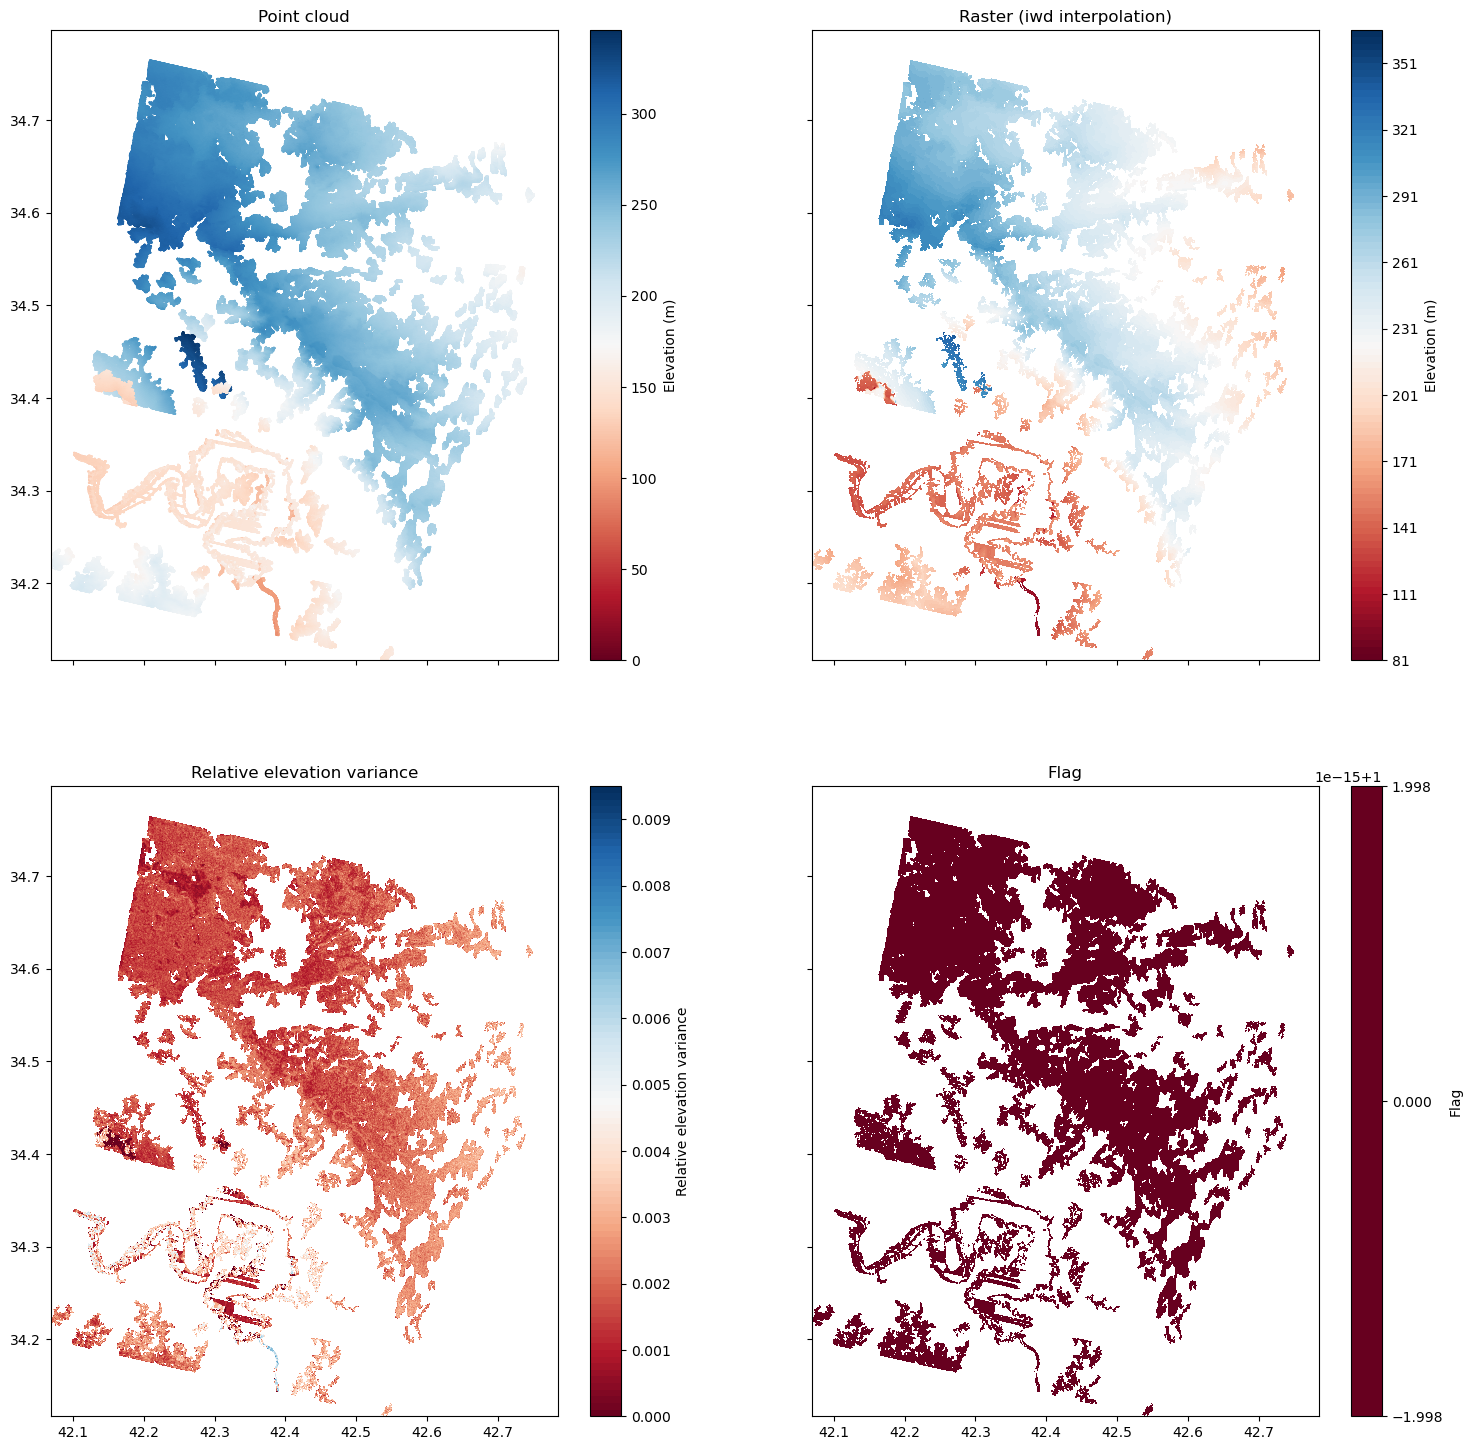

In [9]:
fpdem_raster.load_input_fpdem_raster()
fpdem_raster.compute_fpdem_raster()

In [10]:
fpdem_raster.write_fpdem_raster()

2026-02-12 14:04:36,073 [INFO] Writing FPDEM raster file
